# Italian Financial Challenge - Starter Template

**Student Name:** [Your Name]

**Challenge:** [Choose: Bankruptcy Prediction / Financial Health Classification / Revenue Forecasting]

**Date:** [Date]

---

## Instructions

This template provides a suggested structure for your challenge solution. You can adapt it to your needs, but make sure to cover all required sections:

1. Problem Statement and Objectives
2. Data Loading and Exploration
3. Data Preprocessing
4. Feature Engineering
5. Model Development
6. Model Evaluation
7. Interpretation and Business Insights
8. Conclusions and Future Work

**Remember:**
- Document your thought process with markdown cells
- Comment your code clearly
- Create visualizations to support your insights
- Interpret results in business terms
- Check the evaluation rubric to ensure you meet all criteria

## 1. Problem Statement and Objectives

**Challenge:** [Describe which challenge you chose and why]

**Objective:** [State the prediction goal clearly]

**Success Criteria:** [Define what "good" performance looks like for your chosen challenge]

**Approach:** [Briefly outline your planned approach]

In [122]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Data Loading and Exploration

Load the training data and perform initial exploration.

In [123]:
# Load training data
train_df = pd.read_csv('../data/processed/train_data.csv')

print(f"Dataset shape: {train_df.shape}")
print(f"\nColumns: {train_df.columns.tolist()}")
print(f"\nFirst few rows:")
train_df.head()

Dataset shape: (11828, 30)

Columns: ['company_id', 'fiscal_year', 'province', 'region', 'ateco_sector', 'legal_form', 'years_in_business', 'total_fixed_assets', 'current_assets', 'total_assets', 'shareholders_equity', 'total_debt', 'short_term_debt', 'long_term_debt', 'production_value', 'production_costs', 'operating_income', 'financial_income', 'financial_expenses', 'net_profit_loss', 'roe', 'roi', 'leverage', 'current_ratio', 'quick_ratio', 'debt_to_assets', 'profit_margin', 'bankruptcy_next_year', 'financial_health_class', 'revenue_change']

First few rows:


,company_id,fiscal_year,province,region,ateco_sector,legal_form,years_in_business,total_fixed_assets,current_assets,total_assets,shareholders_equity,total_debt,short_term_debt,long_term_debt,production_value,production_costs,operating_income,financial_income,financial_expenses,net_profit_loss,roe,roi,leverage,current_ratio,quick_ratio,debt_to_assets,profit_margin,bankruptcy_next_year,financial_health_class,revenue_change
0,COMP_00000,2018,NaN,Campania,47,SRL,32,2.422343e+08,9.504819e+08,1.192716e+09,3.728702e+08,8.198459e+08,5.601842e+08,2.596617e+08,1.846636e+09,1.611363e+09,2.352729e+08,4886785.12,20068071.29,2.152049e+08,0.5772,0.1973,2.1987,1.6967,1.0180,0.6874,0.1165,0,B,NaN
1,COMP_00000,2019,NaN,Campania,47,SRL,33,3.983639e+07,1.411226e+08,1.809589e+08,5.700701e+07,1.239519e+08,7.135345e+07,5.259848e+07,4.289159e+08,3.896038e+08,3.931218e+07,58246.06,2537224.20,3.677495e+07,0.6451,0.2172,2.1743,1.9778,1.1867,0.6850,0.0857,0,B,-76.77
2,COMP_00000,2020,NaN,Campania,47,SRL,34,6.662250e+08,1.367208e+09,2.033433e+09,3.029046e+08,1.730529e+09,9.904004e+08,7.401282e+08,6.956197e+09,6.988489e+09,-3.229208e+07,5327332.51,55844558.38,-8.813664e+07,-0.2910,-0.0159,5.7131,1.3805,0.8283,0.8510,-0.0127,0,D,1521.81
3,COMP_00000,2021,NaN,Campania,47,SRL,35,4.637187e+07,2.524228e+08,2.987947e+08,3.901098e+07,2.597837e+08,1.527674e+08,1.070163e+08,5.031839e+08,5.047235e+08,-1.539645e+06,116335.80,7828741.61,-9.368387e+06,-0.2401,-0.0052,6.6592,1.6523,0.9914,0.8694,-0.0186,0,D,-92.77
4,COMP_00001,2018,CA,Sardegna,62,SRL,8,8.348035e+07,1.325697e+08,2.160500e+08,6.566937e+07,1.503807e+08,7.582482e+07,7.455584e+07,4.113380e+08,3.912414e+08,2.009667e+07,640538.94,5860639.22,1.423603e+07,0.2168,0.0930,2.2900,1.7484,1.0490,0.6960,0.0346,0,B,NaN


In [124]:
# Basic information
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11828 entries, 0 to 11827
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   company_id              11828 non-null  str    
 1   fiscal_year             11828 non-null  int64  
 2   province                10909 non-null  str    
 3   region                  11828 non-null  str    
 4   ateco_sector            11828 non-null  int64  
 5   legal_form              11828 non-null  str    
 6   years_in_business       11828 non-null  int64  
 7   total_fixed_assets      11828 non-null  float64
 8   current_assets          11828 non-null  float64
 9   total_assets            11828 non-null  float64
 10  shareholders_equity     11828 non-null  float64
 11  total_debt              11828 non-null  float64
 12  short_term_debt         11828 non-null  float64
 13  long_term_debt          11828 non-null  float64
 14  production_value        11828 non-null  float64
 

In [125]:
# Summary statistics
train_df.describe()

,fiscal_year,ateco_sector,years_in_business,total_fixed_assets,current_assets,total_assets,shareholders_equity,total_debt,short_term_debt,long_term_debt,production_value,production_costs,operating_income,financial_income,financial_expenses,net_profit_loss,roe,roi,leverage,current_ratio,quick_ratio,debt_to_assets,profit_margin,bankruptcy_next_year,revenue_change
count,11828.000000,11828.000000,11828.000000,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,11783.000000,11828.000000,11783.000000,11828.000000,11828.000000,11828.000000,11828.000000,11828.000000,8829.000000
mean,2019.495350,45.827697,35.179405,1.029206e+09,1.438435e+09,2.467641e+09,9.163141e+08,1.551327e+09,8.534656e+08,6.978617e+08,3.969063e+09,3.680129e+09,2.889337e+08,6.418314e+06,5.464980e+07,2.342839e+08,0.254267,0.123253,2.135329,1.869953,1.121972,0.633231,0.058008,0.007102,453.434570
std,1.116482,16.677183,19.908095,6.120958e+09,6.873106e+09,1.248305e+10,5.023564e+09,7.724478e+09,4.360360e+09,3.493369e+09,1.896096e+10,1.757911e+10,1.574126e+09,3.930832e+07,2.850800e+08,1.348222e+09,0.577374,0.091036,2.159040,0.614015,0.368409,0.114868,0.039245,0.083976,4601.920625
min,2018.000000,10.000000,0.000000,1.267167e+06,1.278800e+06,2.545968e+06,-3.330561e+09,1.839791e+06,8.985461e+05,9.412449e+05,2.329670e+06,1.580518e+06,-2.688184e+09,6.241000e+01,5.926949e+04,-4.062689e+09,-39.177100,-0.475300,0.818200,0.551000,0.330600,0.450000,-0.149700,0.000000,-99.940000
25%,2018.000000,41.000000,18.000000,7.319803e+07,1.244471e+08,2.087793e+08,7.070428e+07,1.294646e+08,6.925617e+07,5.666362e+07,2.984883e+08,2.731290e+08,1.698626e+07,3.569547e+05,4.355200e+06,1.049173e+07,0.110350,0.061900,1.165650,1.430800,0.858500,0.538500,0.030500,0.000000,-68.590000
50%,2019.000000,46.000000,35.000000,1.905995e+08,3.125597e+08,5.212379e+08,1.815958e+08,3.264152e+08,1.744802e+08,1.462585e+08,8.040019e+08,7.459428e+08,5.128590e+07,1.068330e+06,1.110262e+07,3.798727e+07,0.221600,0.105000,1.680300,1.811750,1.087050,0.627500,0.060300,0.000000,3.040000
75%,2020.000000,56.000000,52.000000,5.398741e+08,8.387197e+08,1.394478e+09,5.022747e+08,8.795087e+08,4.777298e+08,3.960070e+08,2.241163e+09,2.075266e+09,1.538062e+08,3.178533e+06,3.005698e+07,1.226862e+08,0.390750,0.170900,2.484850,2.238925,1.343325,0.713800,0.090000,0.000000,238.850000
max,2021.000000,82.000000,71.000000,2.548712e+11,2.512549e+11,5.061262e+11,1.956145e+11,3.105116e+11,1.699685e+11,1.405431e+11,6.044366e+11,5.736470e+11,5.621927e+10,1.640114e+09,9.311030e+09,5.011818e+10,1.771600,0.490600,101.153800,4.539300,2.723600,1.192300,0.120000,1.000000,302126.480000


In [126]:
# Check for missing values
missing_values = train_df.isnull().sum()
missing_pct = (missing_values / len(train_df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Percentage': missing_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print("Missing Values:")
print(missing_df)

Missing Values:
                Missing Count  Percentage
revenue_change           2999   25.355090
province                  919    7.769699
roe                        45    0.380453
leverage                   45    0.380453


In [127]:
# Target variable analysis
# TODO: Uncomment the relevant section for your challenge

# For Challenge 3: Revenue Forecasting
print("\nRevenue Change Statistics:")
print(train_df['revenue_change'].describe())
print(f"\nMissing revenue_change: {train_df['revenue_change'].isnull().sum()}")


Revenue Change Statistics:
count      8829.000000
mean        453.434570
std        4601.920625
min         -99.940000
25%         -68.590000
50%           3.040000
75%         238.850000
max      302126.480000
Name: revenue_change, dtype: float64

Missing revenue_change: 2999


### Exploratory Data Analysis (EDA)

Create visualizations to understand the data better.

In [128]:
eda_df = train_df.copy()
eda_df = eda_df.sort_values(['company_id', 'fiscal_year'])

# Intermediate next-year revenue level (for target construction)
eda_df['production_value_next'] = (
    eda_df.groupby('company_id')['production_value'].shift(-1)
)

# Challenge 3 target for EDA: next-year revenue change (%)
eda_df['revenue_change_next'] = 100 * (
    eda_df['production_value_next'] - eda_df['production_value']
) / eda_df['production_value'].replace(0, np.nan)

# Keep only rows with a valid next-year target (train-only EDA; includes 2020)
eda_df = eda_df.dropna(subset=['revenue_change_next'])

eda_df['cost_intensity'] = eda_df['production_costs'] / eda_df['production_value']
eda_df['asset_turnover'] = eda_df['production_value'] / eda_df['total_assets']
eda_df['debt_burden'] = eda_df['financial_expenses'] / eda_df['production_value']
eda_df['equity_ratio'] = eda_df['shareholders_equity'] / eda_df['total_assets']


In [129]:
# No extra year restriction here: keep all train years with valid next-year target (includes 2020).


In [130]:
eda_df = eda_df.dropna(subset=['revenue_change_next'])

In [131]:
print("EDA dataset shape:", eda_df.shape)

print("\nFeature years:")
print(eda_df['fiscal_year'].value_counts())

print("\nTarget summary:")
print(eda_df['revenue_change_next'].describe())

EDA dataset shape: (8829, 36)

Feature years:
fiscal_year
2019    2956
2018    2941
2020    2932
Name: count, dtype: int64

Target summary:
count      8829.000000
mean        453.434572
std        4601.920682
min         -99.943317
25%         -68.594596
50%           3.038018
75%         238.849662
max      302126.484381
Name: revenue_change_next, dtype: float64


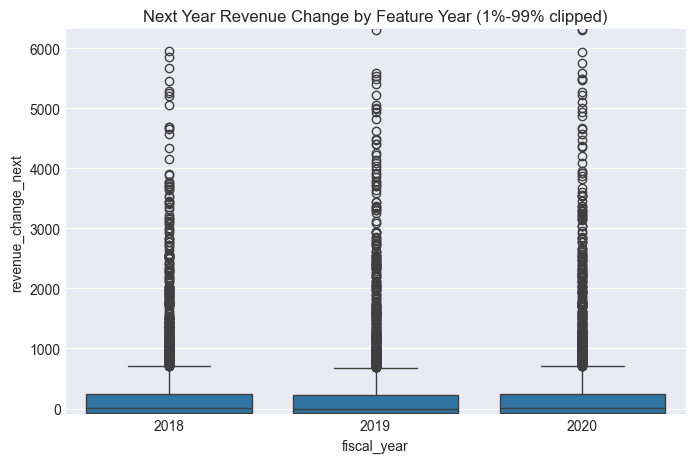

In [132]:
lower = eda_df['revenue_change_next'].quantile(0.01)
upper = eda_df['revenue_change_next'].quantile(0.99)

plt.figure(figsize=(8,5))
sns.boxplot(x='fiscal_year', y='revenue_change_next', data=eda_df)

plt.ylim(lower, upper)

plt.title("Next Year Revenue Change by Feature Year (1%-99% clipped)")
plt.show()

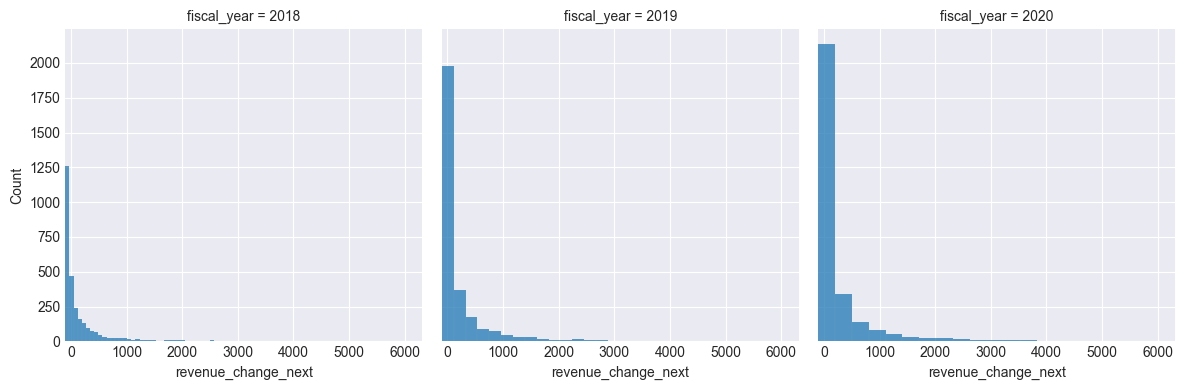

In [133]:
lower = eda_df['revenue_change_next'].quantile(0.01)
upper = eda_df['revenue_change_next'].quantile(0.99)

g = sns.FacetGrid(eda_df, col="fiscal_year", height=4)
g.map(sns.histplot, "revenue_change_next", bins=1000)

for ax in g.axes.flat:
    ax.set_xlim(lower, upper)

plt.show()

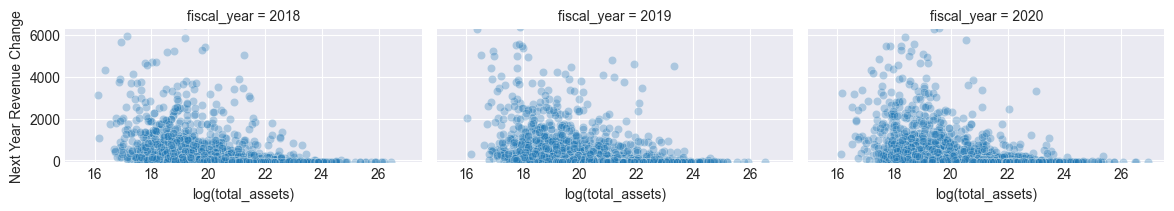

In [134]:
g = sns.FacetGrid(eda_df, col="fiscal_year", height=4)

g.map_dataframe(
    sns.scatterplot,
    x=np.log1p(eda_df['total_assets']),
    y='revenue_change_next',
    alpha=0.3
)

lower = eda_df['revenue_change_next'].quantile(0.01)
upper = eda_df['revenue_change_next'].quantile(0.99)

for ax in g.axes.flat:
    ax.set_ylim(lower, upper)

g.set_axis_labels("log(total_assets)", "Next Year Revenue Change")

plt.show()

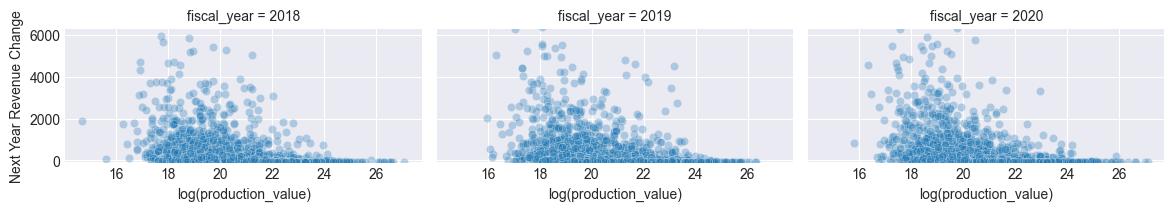

In [135]:
g = sns.FacetGrid(eda_df, col="fiscal_year", height=4)

g.map_dataframe(
    sns.scatterplot,
    x=np.log1p(eda_df['production_value']),
    y='revenue_change_next',
    alpha=0.3
)

lower = eda_df['revenue_change_next'].quantile(0.01)
upper = eda_df['revenue_change_next'].quantile(0.99)

for ax in g.axes.flat:
    ax.set_ylim(lower, upper)

g.set_axis_labels("log(production_value)", "Next Year Revenue Change")

plt.show()

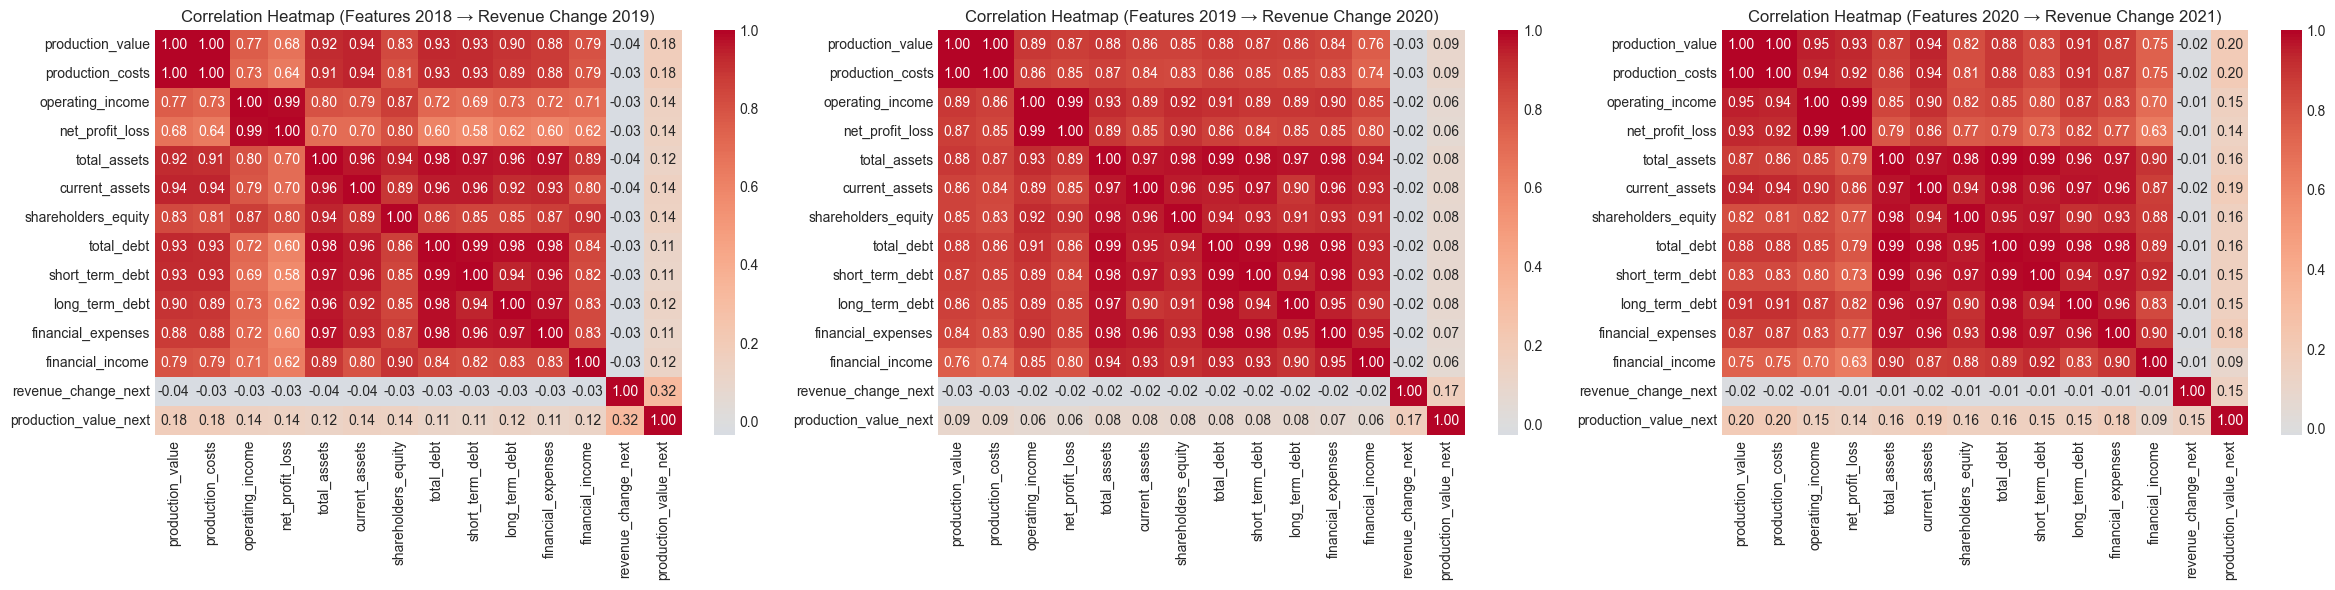

In [136]:
import seaborn as sns
import matplotlib.pyplot as plt

important_features = [
    'production_value',
    'production_costs',
    'operating_income',
    'net_profit_loss',
    'total_assets',
    'current_assets',
    'shareholders_equity',
    'total_debt',
    'short_term_debt',
    'long_term_debt',
    'financial_expenses',
    'financial_income',
    'revenue_change_next',
    'production_value_next'
]

years = sorted(eda_df['fiscal_year'].unique())

fig, axes = plt.subplots(1, len(years), figsize=(8 * len(years), 6))
if len(years) == 1:
    axes = [axes]

for i, year in enumerate(years):
    df_year = eda_df[eda_df['fiscal_year'] == year]
    corr = df_year[important_features].corr()

    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        ax=axes[i]
    )

    axes[i].set_title(f"Correlation Heatmap (Features {year} \u2192 Revenue Change {year+1})")

plt.tight_layout()
plt.show()


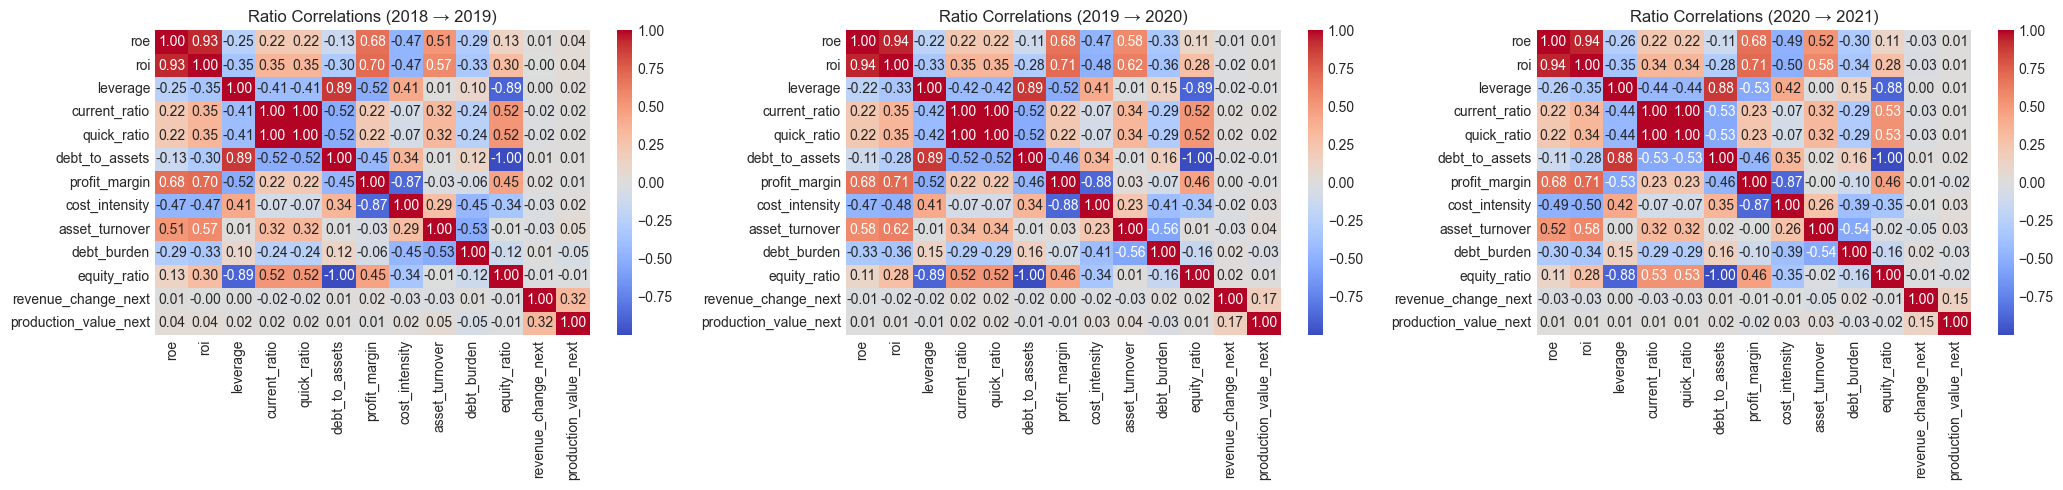

In [137]:
ratio_features = [
    'roe',
    'roi',
    'leverage',
    'current_ratio',
    'quick_ratio',
    'debt_to_assets',
    'profit_margin',
    'cost_intensity',
    'asset_turnover',
    'debt_burden',
    'equity_ratio',
    'revenue_change_next',
    'production_value_next'
]

years = sorted(eda_df['fiscal_year'].unique())

fig, axes = plt.subplots(1, len(years), figsize=(7 * len(years), 5))
if len(years) == 1:
    axes = [axes]

for i, year in enumerate(years):
    df_year = eda_df[eda_df['fiscal_year'] == year]
    corr = df_year[ratio_features].corr()

    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        ax=axes[i]
    )

    axes[i].set_title(f"Ratio Correlations ({year} \u2192 {year+1})")

plt.tight_layout()
plt.show()


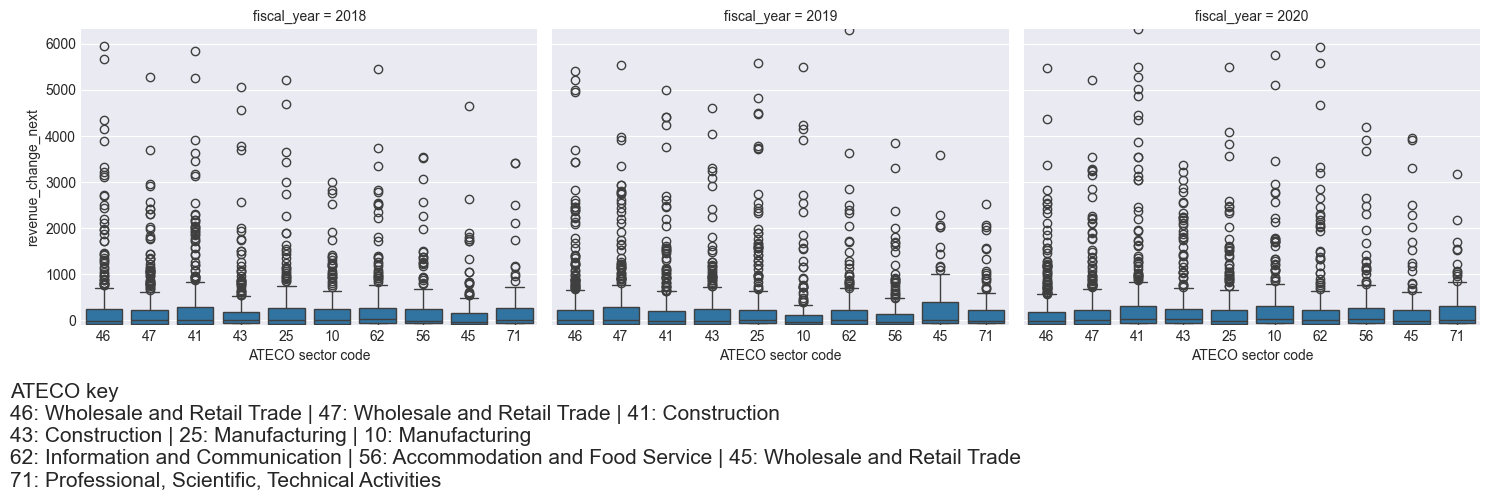

In [138]:
# Top sectors by frequency (keep sector codes separate)
top_sectors = eda_df['ateco_sector'].value_counts().nlargest(10).index

# ATECO main-category labels from docs/data_dictionary.md
ateco_ranges = [
    (1, 3, 'Agriculture, Forestry, Fishing'),
    (5, 9, 'Mining and Quarrying'),
    (10, 33, 'Manufacturing'),
    (35, 35, 'Electricity, Gas, Steam'),
    (36, 39, 'Water Supply, Sewerage, Waste'),
    (41, 43, 'Construction'),
    (45, 47, 'Wholesale and Retail Trade'),
    (49, 53, 'Transportation and Storage'),
    (55, 56, 'Accommodation and Food Service'),
    (58, 63, 'Information and Communication'),
    (64, 66, 'Financial and Insurance Activities'),
    (68, 68, 'Real Estate Activities'),
    (69, 75, 'Professional, Scientific, Technical Activities'),
    (77, 82, 'Administrative and Support Services'),
    (84, 84, 'Public Administration'),
    (85, 85, 'Education'),
    (86, 88, 'Human Health and Social Work'),
    (90, 93, 'Arts, Entertainment, Recreation'),
    (94, 96, 'Other Service Activities'),
]

def ateco_desc_from_code(code):
    code_str = str(code).strip()
    try:
        code_int = int(float(code_str))
    except Exception:
        return 'Unmapped'

    for lo, hi, label in ateco_ranges:
        if lo <= code_int <= hi:
            return label
    return 'Unmapped'

def ateco_code_fmt(code):
    try:
        return f"{int(float(str(code).strip())):02d}"
    except Exception:
        return str(code)

def chunk_list(items, size):
    return [items[i:i + size] for i in range(0, len(items), size)]

plot_df = eda_df[eda_df['ateco_sector'].isin(top_sectors)].copy()
plot_df['ateco_sector_code'] = plot_df['ateco_sector'].apply(ateco_code_fmt)

# Keep same frequency ordering
sector_order_codes = [ateco_code_fmt(s) for s in top_sectors]

g = sns.FacetGrid(
    plot_df,
    col='fiscal_year',
    height=5
)

g.map_dataframe(
    sns.boxplot,
    x='ateco_sector_code',
    y='revenue_change_next',
    order=sector_order_codes
)

for ax in g.axes.flat:
    ax.set_ylim(
        eda_df['revenue_change_next'].quantile(0.01),
        eda_df['revenue_change_next'].quantile(0.99)
    )
    ax.set_xlabel('ATECO sector code')
    ax.tick_params(axis='x', labelrotation=0)

# Add compact key below the chart (so x-axis can stay numeric)
key_items = [f"{code}: {ateco_desc_from_code(code)}" for code in sector_order_codes]
key_lines = [' | '.join(line) for line in chunk_list(key_items, 3)]
key_text = 'ATECO key' + '\n' + '\n'.join(key_lines)

g.fig.subplots_adjust(bottom=0.22 + 0.04 * max(0, len(key_lines) - 1))
g.fig.text(0.01, 0.01, key_text, ha='left', va='bottom', fontsize=15)

plt.show()


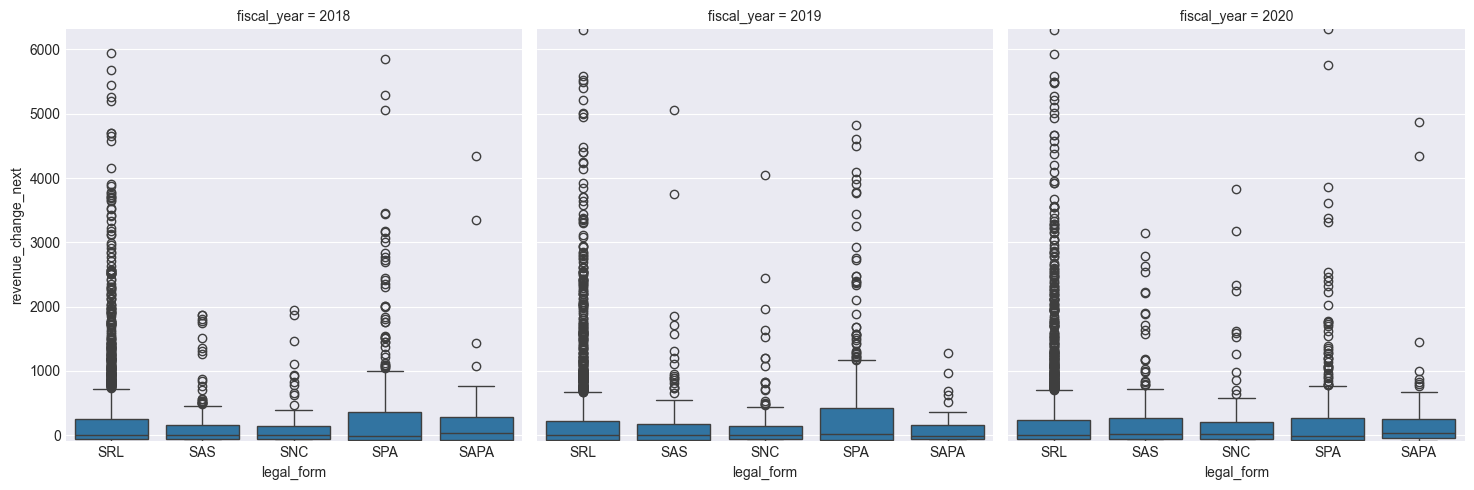

In [139]:
g = sns.FacetGrid(
    eda_df,
    col="fiscal_year",
    height=5
)

g.map_dataframe(
    sns.boxplot,
    x="legal_form",
    y="revenue_change_next"
)

for ax in g.axes.flat:
    ax.set_ylim(
        eda_df['revenue_change_next'].quantile(0.01),
        eda_df['revenue_change_next'].quantile(0.99)
    )

plt.show()

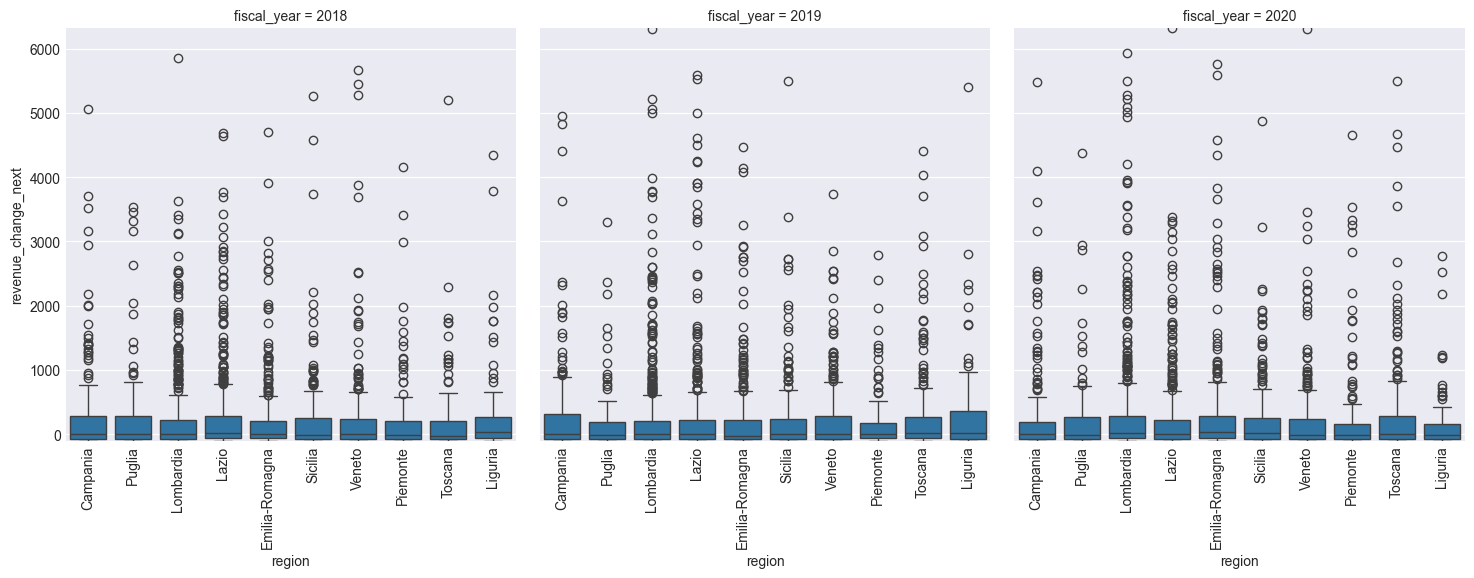

In [140]:
top_regions = eda_df['region'].value_counts().nlargest(10).index

g = sns.FacetGrid(
    eda_df[eda_df['region'].isin(top_regions)],
    col="fiscal_year",
    height=5
)

g.map_dataframe(
    sns.boxplot,
    x="region",
    y="revenue_change_next"
)

for ax in g.axes.flat:
    ax.set_ylim(
        eda_df['revenue_change_next'].quantile(0.01),
        eda_df['revenue_change_next'].quantile(0.99)
    )
    ax.tick_params(axis='x', rotation=90)

plt.show()

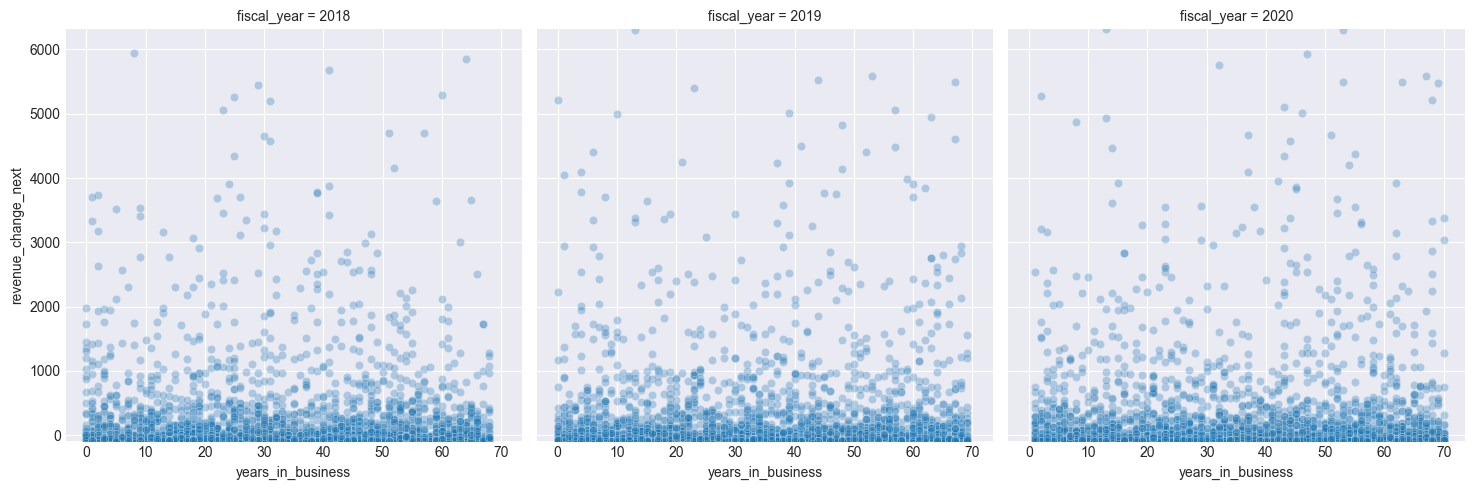

In [141]:
g = sns.FacetGrid(
    eda_df,
    col="fiscal_year",
    height=5
)

g.map_dataframe(
    sns.scatterplot,
    x="years_in_business",
    y="revenue_change_next",
    alpha=0.3
)

for ax in g.axes.flat:
    ax.set_ylim(
        eda_df['revenue_change_next'].quantile(0.01),
        eda_df['revenue_change_next'].quantile(0.99)
    )

plt.show()

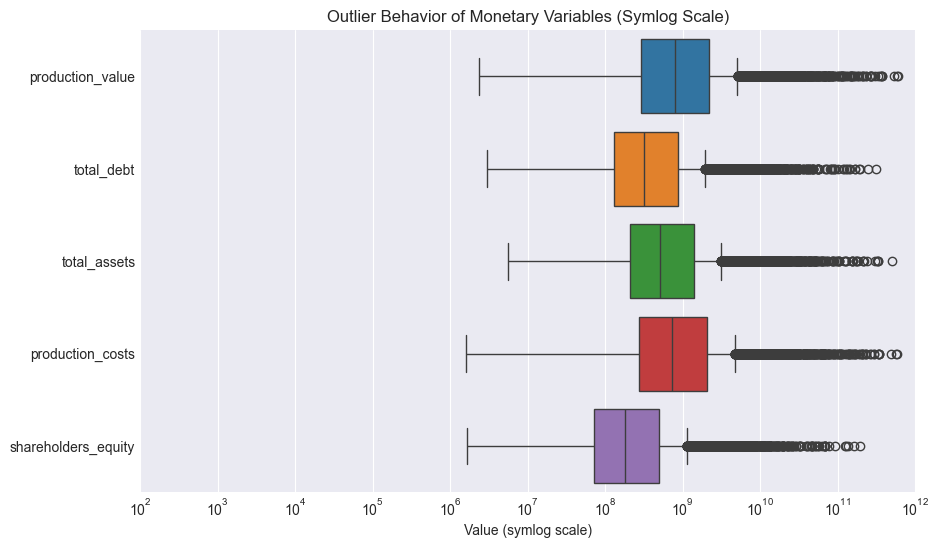

In [142]:
monetary_cols = [
    "production_value",
    "total_debt",
    "total_assets",
    "production_costs",
    "shareholders_equity"
]
plt.figure(figsize=(10,6))

sns.boxplot(
    data=eda_df[monetary_cols],
    orient="h"
)
plt.xscale("symlog")  # handles large values + near zero values

plt.xlim(1e2, 1e12)


plt.title("Outlier Behavior of Monetary Variables (Symlog Scale)")
plt.xlabel("Value (symlog scale)")

plt.show()

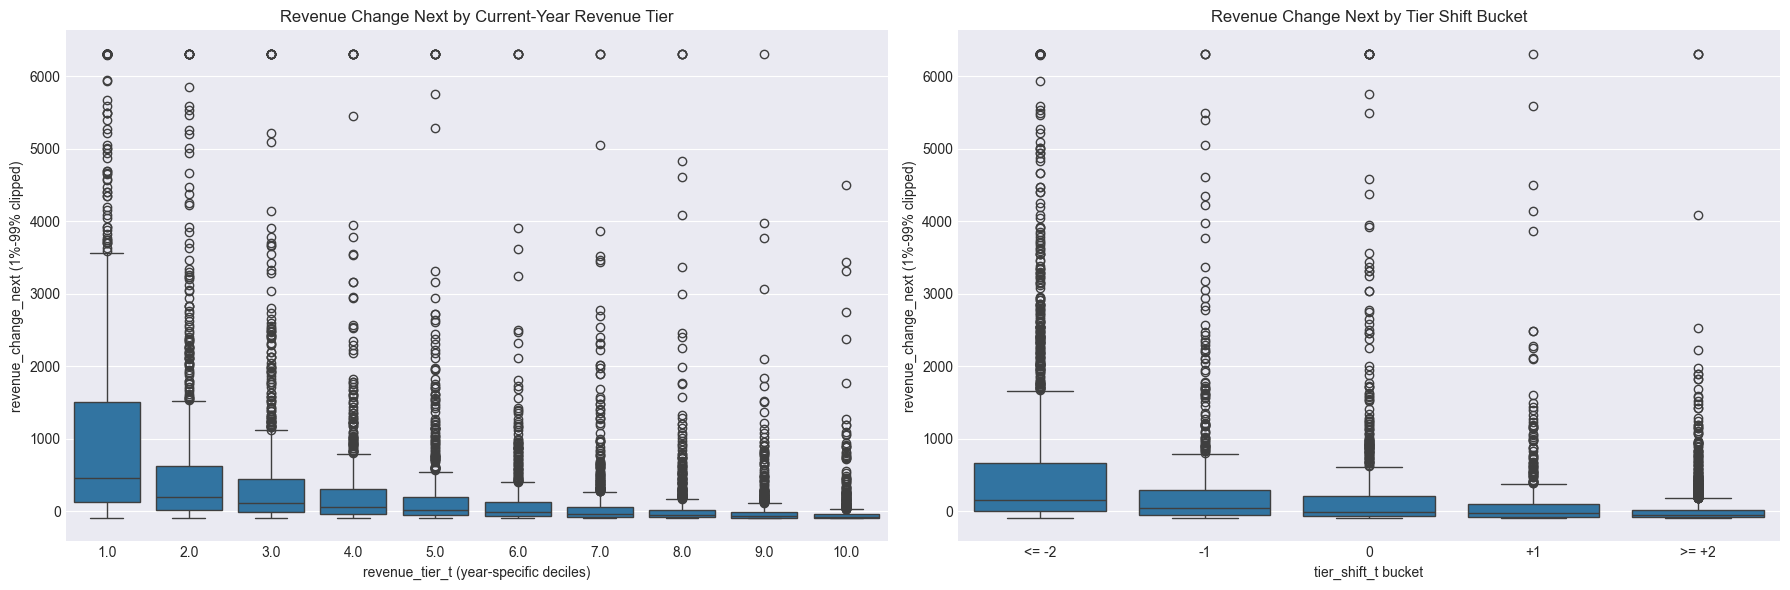

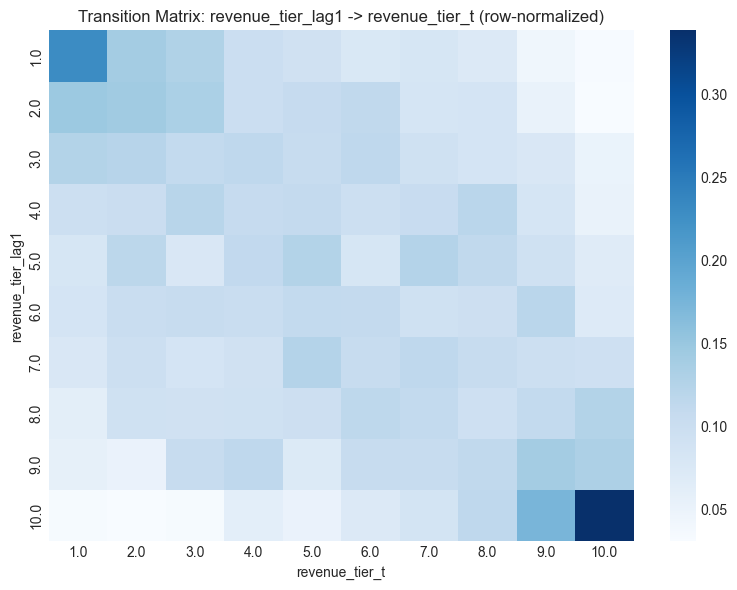

Target behavior by revenue_tier_t:


,revenue_tier_t,n_obs,median_change_next,mean_change_next
0,1.0,885,462.813011,2295.919719
1,2.0,883,190.191720,676.590440
2,3.0,882,107.273637,473.904812
3,4.0,883,53.723506,334.746229
4,5.0,882,18.553817,305.788371
5,6.0,883,-16.217050,178.291388
6,7.0,882,-39.203739,130.474815
7,8.0,883,-54.684693,102.733688
8,9.0,882,-69.043612,37.755237
9,10.0,884,-83.882556,-6.491891


Target behavior by tier_shift_t (with buckets):


,tier_shift_bucket,tier_shift_t,n_obs,median_change_next,mean_change_next
0,<= -2,-9.0,20,1975.422112,19861.261414
1,<= -2,-8.0,52,661.947057,2847.792847
2,<= -2,-7.0,87,448.402104,1427.979292
3,<= -2,-6.0,199,238.806359,986.713488
4,<= -2,-5.0,259,263.746628,785.002265
5,<= -2,-4.0,299,159.213360,1781.445464
6,<= -2,-3.0,413,127.100814,563.889363
7,<= -2,-2.0,511,80.884190,618.736372
8,<= -2,-1.0,0,NaN,NaN
9,<= -2,0.0,0,NaN,NaN


Transition counts (revenue_tier_lag1 -> revenue_tier_t):


revenue_tier_t,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
revenue_tier_lag1,,,,,,,,,,
1.0,134,82,75,58,54,45,48,43,25,19
2.0,86,83,78,58,63,66,49,50,31,18
3.0,74,72,65,67,62,67,55,50,46,30
4.0,58,60,71,63,64,58,61,70,49,31
5.0,48,69,46,65,74,48,73,66,55,40
6.0,50,61,62,61,65,64,55,57,70,42
7.0,46,58,50,54,73,62,67,62,58,56
8.0,37,55,54,55,57,68,65,56,65,74
9.0,34,30,62,67,42,62,62,66,82,77


Transition row-normalized proportions:


revenue_tier_t,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
revenue_tier_lag1,,,,,,,,,,
1.0,0.230,0.141,0.129,0.099,0.093,0.077,0.082,0.074,0.043,0.033
2.0,0.148,0.143,0.134,0.100,0.108,0.113,0.084,0.086,0.053,0.031
3.0,0.126,0.122,0.111,0.114,0.105,0.114,0.094,0.085,0.078,0.051
4.0,0.099,0.103,0.121,0.108,0.109,0.099,0.104,0.120,0.084,0.053
5.0,0.082,0.118,0.079,0.111,0.127,0.082,0.125,0.113,0.094,0.068
6.0,0.085,0.104,0.106,0.104,0.111,0.109,0.094,0.097,0.119,0.072
7.0,0.078,0.099,0.085,0.092,0.125,0.106,0.114,0.106,0.099,0.096
8.0,0.063,0.094,0.092,0.094,0.097,0.116,0.111,0.096,0.111,0.126
9.0,0.058,0.051,0.106,0.115,0.072,0.106,0.106,0.113,0.140,0.132


In [143]:
# Revenue-tier / tier-shift EDA (year-specific deciles)

def assign_year_specific_revenue_tier(df, value_col='production_value', year_col='fiscal_year', n_tiers=10):
    tier = pd.Series(np.nan, index=df.index, dtype='float64')

    for _, year_idx in df.groupby(year_col).groups.items():
        year_values = df.loc[year_idx, value_col]
        valid_idx = year_values[year_values.notna()].index

        if len(valid_idx) == 0:
            continue

        ranks = year_values.loc[valid_idx].rank(method='first')
        q = min(n_tiers, len(valid_idx))

        if q < 2:
            tier.loc[valid_idx] = 1
            continue

        tier.loc[valid_idx] = pd.qcut(
            ranks,
            q=q,
            labels=False,
            duplicates='drop'
        ) + 1

    return tier


eda_tier_df = eda_df.copy().sort_values(['company_id', 'fiscal_year']).reset_index(drop=True)

eda_tier_df['revenue_tier_t'] = assign_year_specific_revenue_tier(eda_tier_df)
eda_tier_df['revenue_tier_lag1'] = eda_tier_df.groupby('company_id')['revenue_tier_t'].shift(1)
eda_tier_df['tier_shift_t'] = eda_tier_df['revenue_tier_t'] - eda_tier_df['revenue_tier_lag1']

eda_tier_df['tier_shift_bucket'] = np.select(
    [
        eda_tier_df['tier_shift_t'] <= -2,
        eda_tier_df['tier_shift_t'] == -1,
        eda_tier_df['tier_shift_t'] == 0,
        eda_tier_df['tier_shift_t'] == 1,
        eda_tier_df['tier_shift_t'] >= 2,
    ],
    ['<= -2', '-1', '0', '+1', '>= +2'],
    default=np.nan
)

bucket_order = ['<= -2', '-1', '0', '+1', '>= +2']
eda_tier_df['tier_shift_bucket'] = pd.Categorical(
    eda_tier_df['tier_shift_bucket'],
    categories=bucket_order,
    ordered=True
)

clip_low = eda_tier_df['revenue_change_next'].quantile(0.01)
clip_high = eda_tier_df['revenue_change_next'].quantile(0.99)
eda_tier_df['revenue_change_next_clip'] = eda_tier_df['revenue_change_next'].clip(clip_low, clip_high)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(
    data=eda_tier_df[eda_tier_df['revenue_tier_t'].notna()],
    x='revenue_tier_t',
    y='revenue_change_next_clip',
    ax=axes[0]
)
axes[0].set_title('Revenue Change Next by Current-Year Revenue Tier')
axes[0].set_xlabel('revenue_tier_t (year-specific deciles)')
axes[0].set_ylabel('revenue_change_next (1%-99% clipped)')

sns.boxplot(
    data=eda_tier_df[eda_tier_df['tier_shift_bucket'].notna()],
    x='tier_shift_bucket',
    y='revenue_change_next_clip',
    order=bucket_order,
    ax=axes[1]
)
axes[1].set_title('Revenue Change Next by Tier Shift Bucket')
axes[1].set_xlabel('tier_shift_t bucket')
axes[1].set_ylabel('revenue_change_next (1%-99% clipped)')

plt.tight_layout()
plt.show()


tier_target_summary = (
    eda_tier_df.groupby('revenue_tier_t', dropna=False)
    .agg(
        n_obs=('company_id', 'size'),
        median_change_next=('revenue_change_next', 'median'),
        mean_change_next=('revenue_change_next', 'mean')
    )
    .reset_index()
    .sort_values('revenue_tier_t')
)

shift_target_summary = (
    eda_tier_df.groupby(['tier_shift_bucket', 'tier_shift_t'], observed=False)
    .agg(
        n_obs=('company_id', 'size'),
        median_change_next=('revenue_change_next', 'median'),
        mean_change_next=('revenue_change_next', 'mean')
    )
    .reset_index()
)

transition_counts = pd.crosstab(
    eda_tier_df['revenue_tier_lag1'],
    eda_tier_df['revenue_tier_t']
)

transition_row_pct = pd.crosstab(
    eda_tier_df['revenue_tier_lag1'],
    eda_tier_df['revenue_tier_t'],
    normalize='index'
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    transition_row_pct,
    cmap='Blues',
    ax=ax
)
ax.set_title('Transition Matrix: revenue_tier_lag1 -> revenue_tier_t (row-normalized)')
ax.set_xlabel('revenue_tier_t')
ax.set_ylabel('revenue_tier_lag1')
plt.tight_layout()
plt.show()

print('Target behavior by revenue_tier_t:')
display(tier_target_summary)

print('Target behavior by tier_shift_t (with buckets):')
display(shift_target_summary)

print('Transition counts (revenue_tier_lag1 -> revenue_tier_t):')
display(transition_counts)

print('Transition row-normalized proportions:')
display(transition_row_pct.round(3))


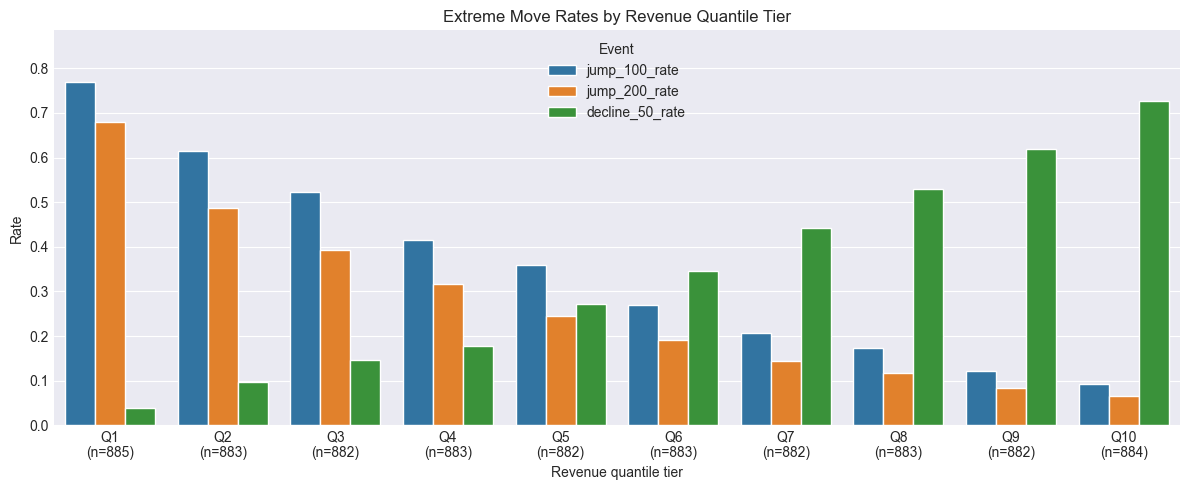

Extreme move rate summary by revenue quantile tier:


,tier_label,n,jump_100_rate,jump_200_rate,decline_50_rate
0,Q1,885,0.769492,0.680226,0.039548
1,Q2,883,0.613817,0.488109,0.096263
2,Q3,882,0.523810,0.393424,0.147392
3,Q4,883,0.414496,0.317101,0.178935
4,Q5,882,0.358277,0.244898,0.270975
5,Q6,883,0.270668,0.190260,0.345413
6,Q7,882,0.206349,0.143991,0.442177
7,Q8,883,0.174405,0.116648,0.530011
8,Q9,882,0.121315,0.082766,0.619048
9,Q10,884,0.091629,0.066742,0.726244


In [144]:
# Extreme move rates by revenue quantile tier (requested right-side chart)

rate_df = eda_tier_df.copy()

rate_df = rate_df[rate_df['revenue_tier_t'].notna() & rate_df['revenue_change_next'].notna()].copy()
rate_df['tier_int'] = pd.to_numeric(rate_df['revenue_tier_t'], errors='coerce').round().astype('Int64')
rate_df = rate_df[rate_df['tier_int'].notna()].copy()
rate_df['tier_int'] = rate_df['tier_int'].astype(int)

extreme_rate_summary = (
    rate_df.groupby('tier_int')
    .agg(
        n=('company_id', 'size'),
        jump_100_rate=('revenue_change_next', lambda s: (s > 100).mean()),
        jump_200_rate=('revenue_change_next', lambda s: (s > 200).mean()),
        decline_50_rate=('revenue_change_next', lambda s: (s < -50).mean())
    )
    .reindex(range(1, 11))
    .reset_index()
)

extreme_rate_summary['tier_label'] = extreme_rate_summary['tier_int'].apply(lambda x: f'Q{x}' if pd.notna(x) else np.nan)
extreme_rate_summary['tier_tick'] = extreme_rate_summary.apply(
    lambda r: f"{r['tier_label']}\n(n={int(r['n'])})" if pd.notna(r['n']) else f"{r['tier_label']}\n(n=0)",
    axis=1
)

plot_df = extreme_rate_summary.melt(
    id_vars=['tier_int', 'tier_label', 'tier_tick', 'n'],
    value_vars=['jump_100_rate', 'jump_200_rate', 'decline_50_rate'],
    var_name='Event',
    value_name='Rate'
)

event_order = ['jump_100_rate', 'jump_200_rate', 'decline_50_rate']

plt.figure(figsize=(12, 5))
sns.barplot(
    data=plot_df,
    x='tier_tick',
    y='Rate',
    hue='Event',
    hue_order=event_order,
    palette=['#1f77b4', '#ff7f0e', '#2ca02c']
)

plt.title('Extreme Move Rates by Revenue Quantile Tier')
plt.xlabel('Revenue quantile tier')
plt.ylabel('Rate')
plt.ylim(0, min(1.0, max(0.05, plot_df['Rate'].max() * 1.15)))
plt.legend(title='Event')
plt.tight_layout()
plt.show()

print('Extreme move rate summary by revenue quantile tier:')
display(extreme_rate_summary[['tier_label', 'n', 'jump_100_rate', 'jump_200_rate', 'decline_50_rate']])


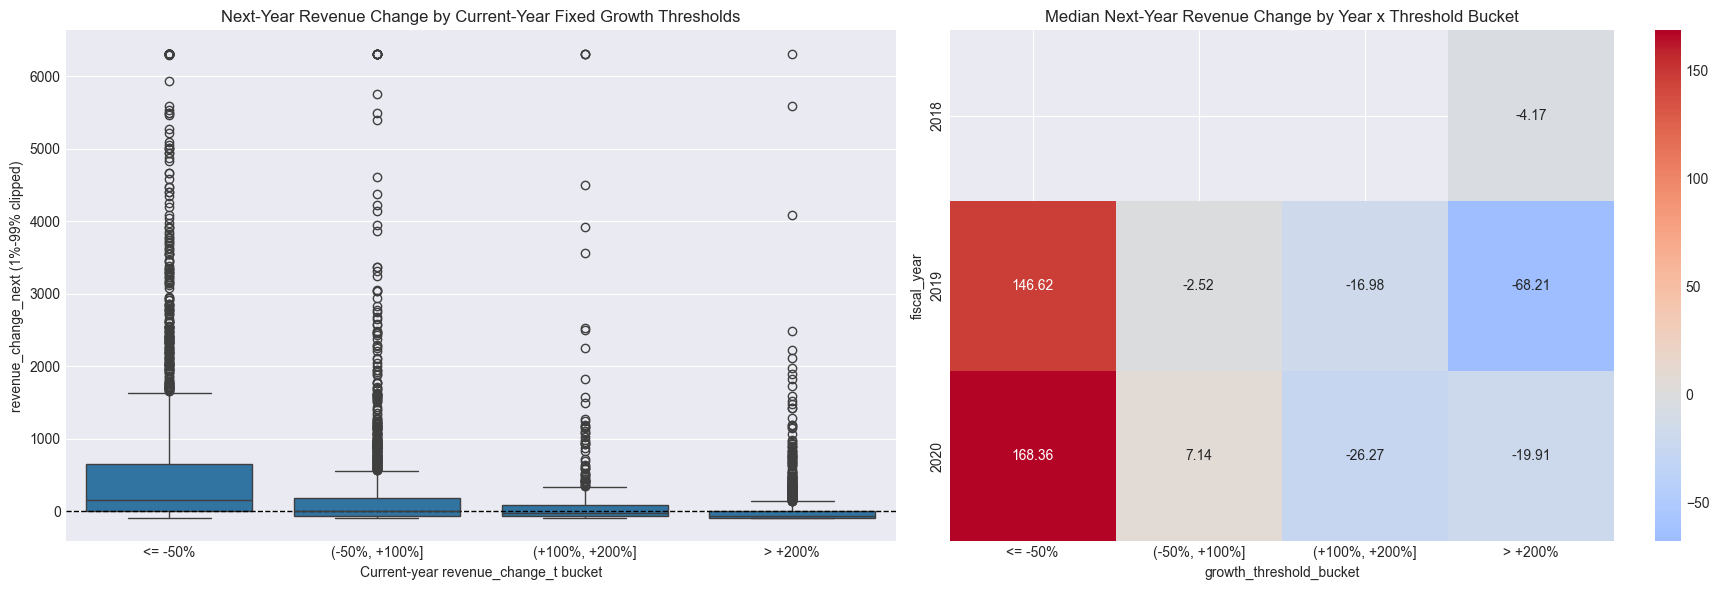

Fixed-threshold summary (-50%, +100%, +200%):


,growth_threshold_bucket,n_obs,median_change_next,mean_change_next
0,<= -50%,2008,156.536266,1116.818835
1,"(-50%, +100%]",1788,0.220348,258.600583
2,"(+100%, +200%]",463,-21.937055,190.773090
3,> +200%,1591,-67.312364,21.317507


In [145]:
# Fixed-threshold event EDA (-50%, +100%, +200%)
# Uses current-year growth signal to study next-year target behavior, clipped to 1%-99% for readability.

eda_threshold_df = eda_tier_df.copy().sort_values(['company_id', 'fiscal_year']).reset_index(drop=True)

eda_threshold_df['production_value_lag1'] = (
    eda_threshold_df.groupby('company_id')['production_value'].shift(1)
)

eda_threshold_df['revenue_change_t'] = 100 * (
    eda_threshold_df['production_value'] - eda_threshold_df['production_value_lag1']
) / eda_threshold_df['production_value_lag1'].replace(0, np.nan)

eda_threshold_df['growth_threshold_bucket'] = np.select(
    [
        eda_threshold_df['revenue_change_t'] <= -50,
        (eda_threshold_df['revenue_change_t'] > -50) & (eda_threshold_df['revenue_change_t'] <= 100),
        (eda_threshold_df['revenue_change_t'] > 100) & (eda_threshold_df['revenue_change_t'] <= 200),
        eda_threshold_df['revenue_change_t'] > 200,
    ],
    ['<= -50%', '(-50%, +100%]', '(+100%, +200%]', '> +200%'],
    default=np.nan
)

threshold_order = ['<= -50%', '(-50%, +100%]', '(+100%, +200%]', '> +200%']
eda_threshold_df['growth_threshold_bucket'] = pd.Categorical(
    eda_threshold_df['growth_threshold_bucket'],
    categories=threshold_order,
    ordered=True
)

clip_low = eda_threshold_df['revenue_change_next'].quantile(0.01)
clip_high = eda_threshold_df['revenue_change_next'].quantile(0.99)
eda_threshold_df['revenue_change_next_clip'] = eda_threshold_df['revenue_change_next'].clip(clip_low, clip_high)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(
    data=eda_threshold_df[eda_threshold_df['growth_threshold_bucket'].notna()],
    x='growth_threshold_bucket',
    y='revenue_change_next_clip',
    order=threshold_order,
    ax=axes[0]
)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Next-Year Revenue Change by Current-Year Fixed Growth Thresholds')
axes[0].set_xlabel('Current-year revenue_change_t bucket')
axes[0].set_ylabel('revenue_change_next (1%-99% clipped)')

threshold_year_median = (
    eda_threshold_df.groupby(['fiscal_year', 'growth_threshold_bucket'], observed=False)['revenue_change_next']
    .median()
    .unstack('growth_threshold_bucket')
    .reindex(columns=threshold_order)
)

sns.heatmap(
    threshold_year_median,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=axes[1]
)
axes[1].set_title('Median Next-Year Revenue Change by Year x Threshold Bucket')
axes[1].set_xlabel('growth_threshold_bucket')
axes[1].set_ylabel('fiscal_year')

plt.tight_layout()
plt.show()

threshold_summary = (
    eda_threshold_df.groupby('growth_threshold_bucket', observed=False)
    .agg(
        n_obs=('company_id', 'size'),
        median_change_next=('revenue_change_next', 'median'),
        mean_change_next=('revenue_change_next', 'mean')
    )
    .reindex(threshold_order)
    .reset_index()
)

print('Fixed-threshold summary (-50%, +100%, +200%):')
display(threshold_summary)


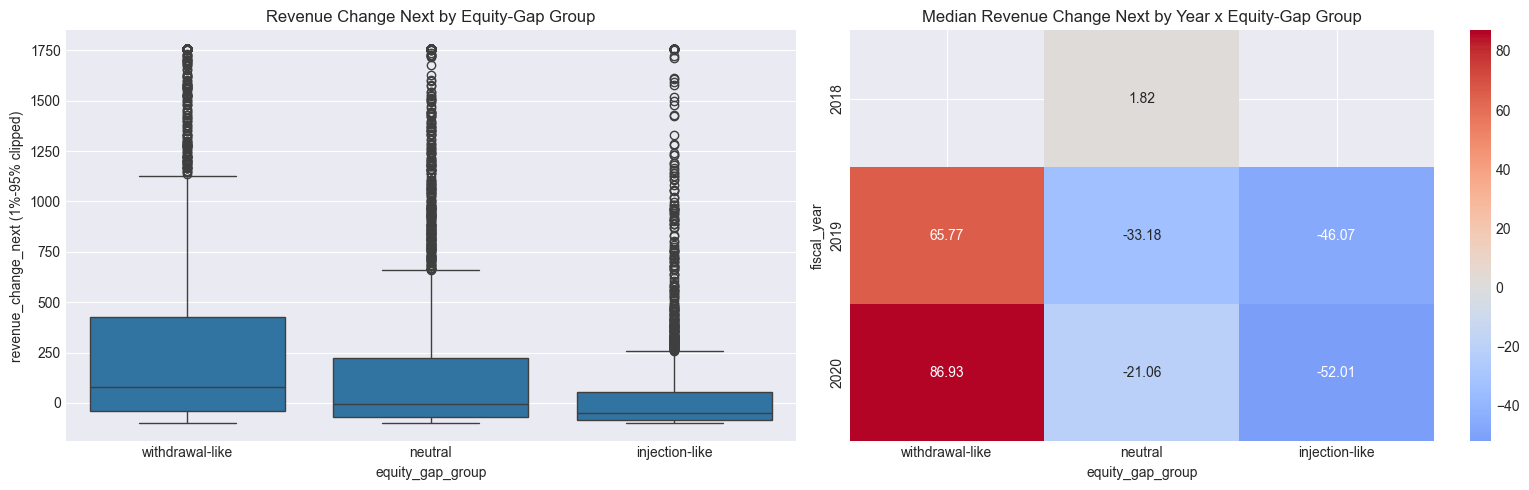

Equity-gap proxy summary (neutral interpretation):


,equity_gap_group,n_obs,median_change_next,mean_change_next,shock_rate
0,withdrawal-like,3209,77.675751,775.303470,1.0
1,neutral,3428,-3.242928,361.510613,0.0
2,injection-like,2192,-49.932114,125.988420,1.0


In [146]:
# Equity-gap proxy EDA (capital injection/withdrawal signal, neutral naming)

eda_equity_df = eda_df.copy().sort_values(['company_id', 'fiscal_year']).reset_index(drop=True)

eda_equity_df['shareholders_equity_lag1'] = (
    eda_equity_df.groupby('company_id')['shareholders_equity'].shift(1)
)

eda_equity_df['equity_expected_from_profit'] = (
    eda_equity_df['shareholders_equity_lag1'] + eda_equity_df['net_profit_loss']
)

eda_equity_df['equity_gap'] = (
    eda_equity_df['shareholders_equity'] - eda_equity_df['equity_expected_from_profit']
)

eda_equity_df['equity_gap_pct_assets'] = (
    eda_equity_df['equity_gap'] / eda_equity_df['total_assets'].replace(0, np.nan)
)

EQUITY_GAP_ASSET_THRESHOLD = 0.04  # 4% of assets threshold for injection/withdrawal-like shock

eda_equity_df['equity_injection_flag'] = (
    eda_equity_df['equity_gap_pct_assets'] >= EQUITY_GAP_ASSET_THRESHOLD
).astype(int)

eda_equity_df['equity_withdrawal_flag'] = (
    eda_equity_df['equity_gap_pct_assets'] <= -EQUITY_GAP_ASSET_THRESHOLD
).astype(int)

eda_equity_df['equity_shock_flag'] = (
    eda_equity_df['equity_gap_pct_assets'].abs() >= EQUITY_GAP_ASSET_THRESHOLD
).astype(int)

eda_equity_df['equity_gap_group'] = np.select(
    [
        eda_equity_df['equity_injection_flag'] == 1,
        eda_equity_df['equity_withdrawal_flag'] == 1,
    ],
    ['injection-like', 'withdrawal-like'],
    default='neutral'
)

group_order = ['withdrawal-like', 'neutral', 'injection-like']
clip_low = eda_equity_df['revenue_change_next'].quantile(0.01)
clip_high = eda_equity_df['revenue_change_next'].quantile(0.95)
eda_equity_df['revenue_change_next_clip'] = eda_equity_df['revenue_change_next'].clip(clip_low, clip_high)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(
    data=eda_equity_df,
    x='equity_gap_group',
    y='revenue_change_next_clip',
    order=group_order,
    ax=axes[0]
)
axes[0].set_title('Revenue Change Next by Equity-Gap Group')
axes[0].set_xlabel('equity_gap_group')
axes[0].set_ylabel('revenue_change_next (1%-95% clipped)')

year_group_pivot = (
    eda_equity_df.groupby(['fiscal_year', 'equity_gap_group'])['revenue_change_next']
    .median()
    .unstack('equity_gap_group')
    .reindex(columns=group_order)
)

sns.heatmap(
    year_group_pivot,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=axes[1]
)
axes[1].set_title('Median Revenue Change Next by Year x Equity-Gap Group')
axes[1].set_xlabel('equity_gap_group')
axes[1].set_ylabel('fiscal_year')

plt.tight_layout()
plt.show()


equity_group_summary = (
    eda_equity_df.groupby('equity_gap_group')
    .agg(
        n_obs=('company_id', 'size'),
        median_change_next=('revenue_change_next', 'median'),
        mean_change_next=('revenue_change_next', 'mean'),
        shock_rate=('equity_shock_flag', 'mean')
    )
    .reindex(group_order)
    .reset_index()
)

print('Equity-gap proxy summary (neutral interpretation):')
display(equity_group_summary)


### EDA Addition 1: Representative Company Revenue Trajectories
This section visualizes representative firm-level revenue paths to show the diversity of dynamics the model must learn: stable growth, high volatility, sharp declines, and potential COVID-style rebound behavior.

### EDA Addition 2: Revenue Change Autocorrelation
This plot tests whether current-year growth carries into next-year growth. Strong positive autocorrelation supports momentum features; weak or negative correlation suggests mean reversion or event-driven dynamics.

**Key Insights from EDA:**

TODO: Document your key findings
- 
- 
- 

## 3. Data Preprocessing

Handle missing values, outliers, and prepare data for modeling.

In [147]:
# Load datasets
train_df = pd.read_csv('../data/processed/train_data.csv')
test_df = pd.read_csv('../data/processed/test_features.csv')

target_cols_to_drop = ['bankruptcy_next_year','financial_health_class','revenue_change']
train_df = train_df.drop(columns=target_cols_to_drop).copy()


print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain years:", sorted(train_df['fiscal_year'].unique()))
print("Test years:", sorted(test_df['fiscal_year'].unique()))

print("\nTrain columns:", len(train_df.columns))
print("Test columns:", len(test_df.columns))

Train shape: (11828, 27)
Test shape: (5811, 27)

Train years: [2018, 2019, 2020, 2021]
Test years: [2022, 2023]

Train columns: 27
Test columns: 27


In [148]:
# Create next year's production value and next-year revenue change target
full_df = pd.concat([train_df, test_df], axis=0)
full_df = full_df.sort_values(['company_id', 'fiscal_year']).reset_index(drop=True)

full_df['production_value_next'] = (
    full_df.groupby('company_id')['production_value'].shift(-1)
)

full_df['revenue_change_next'] = 100 * (
    full_df['production_value_next'] - full_df['production_value']
) / full_df['production_value'].replace(0, np.nan)

print(full_df[['company_id', 'fiscal_year', 'production_value', 'production_value_next', 'revenue_change_next']].head(10))


   company_id  fiscal_year  production_value  production_value_next  \
0  COMP_00000         2018      1.846636e+09           4.289159e+08   
1  COMP_00000         2019      4.289159e+08           6.956197e+09   
2  COMP_00000         2020      6.956197e+09           5.031839e+08   
3  COMP_00000         2021      5.031839e+08           3.898393e+08   
4  COMP_00000         2022      3.898393e+08           7.742371e+09   
5  COMP_00000         2023      7.742371e+09                    NaN   
6  COMP_00001         2018      4.113380e+08           1.595547e+09   
7  COMP_00001         2019      1.595547e+09           1.827539e+08   
8  COMP_00001         2020      1.827539e+08           2.613448e+09   
9  COMP_00001         2021      2.613448e+09           1.439279e+08   

   revenue_change_next  
0           -76.773119  
1          1521.808901  
2           -92.766394  
3           -22.525468  
4          1886.041444  
5                  NaN  
6           287.891867  
7           -88.54

In [149]:
# Keep only rows where next year's revenue change target exists
model_df = full_df.dropna(subset=['revenue_change_next']).copy()

print("Model dataset shape:", model_df.shape)
print("\nYears in model dataset:", sorted(model_df['fiscal_year'].unique()))

print("\nRows by year:")
print(model_df['fiscal_year'].value_counts().sort_index())


Model dataset shape: (14640, 29)

Years in model dataset: [2018, 2019, 2020, 2021, 2022]

Rows by year:
fiscal_year
2018    2941
2019    2956
2020    2932
2021    2916
2022    2895
Name: count, dtype: int64


In [150]:
# Define sliding window folds
# 2020 is validation; 2021 is treated as a test-like holdout in the project narrative.
# 2022+ remain separate held-out years from test_features.
folds = [
    {'fold_name': 'Fold 1', 'train_years': [2018, 2019],       'val_year': 2020},
    {'fold_name': 'Fold 2', 'train_years': [2018, 2019, 2020], 'val_year': 2021},
]

for fold in folds:
    print(f"{fold['fold_name']}: train = {fold['train_years']}, val = {fold['val_year']}")


Fold 1: train = [2018, 2019], val = 2020
Fold 2: train = [2018, 2019, 2020], val = 2021


In [151]:
# Define columns
id_cols = ['company_id', 'fiscal_year']
target_col = 'revenue_change_next'

feature_cols = [
    col for col in model_df.columns
    if col not in id_cols + [target_col, 'production_value_next']
]

print("Number of feature columns:", len(feature_cols))
print("\nFeature columns:")
print(feature_cols)


Number of feature columns: 25

Feature columns:
['province', 'region', 'ateco_sector', 'legal_form', 'years_in_business', 'total_fixed_assets', 'current_assets', 'total_assets', 'shareholders_equity', 'total_debt', 'short_term_debt', 'long_term_debt', 'production_value', 'production_costs', 'operating_income', 'financial_income', 'financial_expenses', 'net_profit_loss', 'roe', 'roi', 'leverage', 'current_ratio', 'quick_ratio', 'debt_to_assets', 'profit_margin']


In [152]:
def get_fold_data(model_df, feature_cols, target_col, train_years, val_year):
    train_data = model_df[model_df['fiscal_year'].isin(train_years)].copy()
    val_data = model_df[model_df['fiscal_year'] == val_year].copy()

    X_train = train_data[feature_cols].copy()
    y_train = train_data[target_col].copy()

    X_val = val_data[feature_cols].copy()
    y_val = val_data[target_col].copy()

    return train_data, val_data, X_train, y_train, X_val, y_val

In [153]:
fold_1 = folds[0]

train_data, val_data, X_train, y_train, X_val, y_val = get_fold_data(
    model_df=model_df,
    feature_cols=feature_cols,
    target_col=target_col,
    train_years=fold_1['train_years'],
    val_year=fold_1['val_year']
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

print("\nTrain years:", sorted(train_data['fiscal_year'].unique()))
print("Validation year:", val_data['fiscal_year'].unique())

Train shape: (5897, 25)
Validation shape: (2932, 25)

Train years: [2018, 2019]
Validation year: [2020]


In [154]:
def evaluate_revenue_change(y_true_rev_change, y_pred_rev_change):
    # Metrics on revenue change target directly
    r2 = r2_score(y_true_rev_change, y_pred_rev_change)
    rmse = np.sqrt(mean_squared_error(y_true_rev_change, y_pred_rev_change))
    mae = mean_absolute_error(y_true_rev_change, y_pred_rev_change)

    # Avoid division by zero in MAPE
    mask = y_true_rev_change != 0
    mape = np.mean(
        np.abs((y_true_rev_change[mask] - y_pred_rev_change[mask]) / y_true_rev_change[mask])
    ) * 100

    return {'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}


In [155]:
# ============================================================
# FEATURE ENGINEERING — Clean, leakage-safe version
# ============================================================

import numpy as np
import pandas as pd

# Sort panel data
model_df = model_df.sort_values(['company_id', 'fiscal_year']).reset_index(drop=True)

# Group by company once
grp = model_df.groupby('company_id')

def safe_div(num, den):
    den = den.replace(0, np.nan)
    return num / den

In [156]:
# Core momentum / lag features


# Previous revenue levels
model_df['production_value_lag1'] = grp['production_value'].shift(1)
model_df['production_value_lag2'] = grp['production_value'].shift(2)


# Current revenue growth computed from production_value only
model_df['revenue_change'] = safe_div(
    model_df['production_value'] - model_df['production_value_lag1'],
    model_df['production_value_lag1']
) * 100


# Revenue growth history
model_df['rev_growth_lag1'] = grp['revenue_change'].shift(1)
model_df['rev_growth_lag2'] = grp['revenue_change'].shift(2)
model_df['rev_growth_accel'] = model_df['rev_growth_lag1'] - model_df['rev_growth_lag2']
model_df['rev_growth_avg2'] = model_df[['rev_growth_lag1', 'rev_growth_lag2']].mean(axis=1)


# Legacy fixed-threshold diagnostics (kept for reference, not used in ma_confidence_score)
model_df['high_growth_flag'] = (model_df['revenue_change'] > 100).astype(int)
model_df['negative_growth_flag'] = (model_df['revenue_change'] < 0).astype(int)
model_df['extreme_growth_flag'] = (model_df['revenue_change'] > 200).astype(int)
model_df['extreme_decline_flag'] = (model_df['revenue_change'] < -50).astype(int)


# Explicit extreme-event dummies requested for -50% / 200% thresholds
model_df['rev_decline_below_m50_dummy'] = (model_df['revenue_change'] < -50).astype(int)
model_df['rev_growth_above_200_dummy'] = (model_df['revenue_change'] > 200).astype(int)
model_df['rev_extreme_event_dummy'] = (
    (model_df['revenue_change'] < -50) | (model_df['revenue_change'] > 200)
).astype(int)


# Revenue size regime features (year-specific deciles within each fiscal year)
def assign_year_specific_revenue_tier(df, value_col='production_value', year_col='fiscal_year', n_tiers=10):
    tier = pd.Series(np.nan, index=df.index, dtype='float64')

    for _, year_idx in df.groupby(year_col).groups.items():
        year_values = df.loc[year_idx, value_col]
        valid_idx = year_values[year_values.notna()].index

        if len(valid_idx) == 0:
            continue

        ranks = year_values.loc[valid_idx].rank(method='first')
        q = min(n_tiers, len(valid_idx))

        if q < 2:
            tier.loc[valid_idx] = 1
            continue

        tier.loc[valid_idx] = pd.qcut(
            ranks,
            q=q,
            labels=False,
            duplicates='drop'
        ) + 1

    return tier


model_df['revenue_tier_t'] = assign_year_specific_revenue_tier(model_df)
model_df['revenue_tier_lag1'] = model_df.groupby('company_id')['revenue_tier_t'].shift(1)
model_df['tier_shift_t'] = model_df['revenue_tier_t'] - model_df['revenue_tier_lag1']
model_df['large_tier_jump_flag'] = model_df['tier_shift_t'].abs().ge(2).astype(int)


# Size-specific growth thresholds by revenue tier (train years only: fiscal_year <= 2021)
# We use rev_growth_lag1 for flagging, so thresholds are estimated on the same variable.
tier_threshold_source = model_df.loc[
    (model_df['fiscal_year'] <= 2021) &
    model_df['revenue_tier_t'].notna() &
    model_df['rev_growth_lag1'].notna(),
    ['revenue_tier_t', 'rev_growth_lag1']
].copy()

tier_growth_thresholds = (
    tier_threshold_source
    .groupby('revenue_tier_t', as_index=False)['rev_growth_lag1']
    .agg(
        tier_p1_growth=lambda s: s.quantile(0.01),
        tier_p5_growth=lambda s: s.quantile(0.05),
        tier_median_growth='median',
        tier_p95_growth=lambda s: s.quantile(0.95),
        tier_p99_growth=lambda s: s.quantile(0.99),
        tier_std_growth='std',
        tier_growth_count='count'
    )
    .sort_values('revenue_tier_t')
)

tier_growth_thresholds['tier_std_growth'] = tier_growth_thresholds['tier_std_growth'].replace(0, np.nan)

# Map tier-specific thresholds to each row by the row's own revenue tier.
tier_threshold_maps = tier_growth_thresholds.set_index('revenue_tier_t')
for _col in [
    'tier_p1_growth',
    'tier_p5_growth',
    'tier_median_growth',
    'tier_p95_growth',
    'tier_p99_growth',
    'tier_std_growth',
    'tier_growth_count'
]:
    model_df[_col] = model_df['revenue_tier_t'].map(tier_threshold_maps[_col])

# Tier-specific anomaly flags based on prior-year growth (rev_growth_lag1)
model_df['tier_extreme_growth_flag'] = (
    model_df['rev_growth_lag1'] > model_df['tier_p99_growth']
).astype(int)

model_df['tier_extreme_decline_flag'] = (
    model_df['rev_growth_lag1'] < model_df['tier_p1_growth']
).astype(int)

model_df['tier_unusual_growth_flag'] = (
    model_df['rev_growth_lag1'] > model_df['tier_p95_growth']
).astype(int)

model_df['tier_unusual_decline_flag'] = (
    model_df['rev_growth_lag1'] < model_df['tier_p5_growth']
).astype(int)

# Tier-relative growth z-score: same interpretation across company sizes
model_df['tier_relative_growth'] = safe_div(
    model_df['rev_growth_lag1'] - model_df['tier_median_growth'],
    model_df['tier_std_growth']
)

tier_threshold_table = (
    tier_growth_thresholds[
        [
            'revenue_tier_t',
            'tier_p1_growth',
            'tier_p5_growth',
            'tier_median_growth',
            'tier_p95_growth',
            'tier_p99_growth',
            'tier_growth_count'
        ]
    ]
    .rename(columns={
        'revenue_tier_t': 'Tier',
        'tier_p1_growth': 'P1',
        'tier_p5_growth': 'P5',
        'tier_median_growth': 'Median',
        'tier_p95_growth': 'P95',
        'tier_p99_growth': 'P99',
        'tier_growth_count': 'Count'
    })
)

print('Tier-specific growth thresholds (train years <= 2021, variable = rev_growth_lag1):')
display(tier_threshold_table.round(3))


# Lag features for important financial variables
lag_cols = [
    'production_costs',
    'operating_income',
    'net_profit_loss',
    'total_assets',
    'shareholders_equity',
    'total_debt',
    'current_assets',
    'total_fixed_assets',
    'short_term_debt',
    'long_term_debt',
    'financial_income',
    'financial_expenses'
]

for col in lag_cols:
    model_df[f'{col}_lag1'] = grp[col].shift(1)
    model_df[f'{col}_lag2'] = grp[col].shift(2)


# Equity-gap proxy features (capital intervention/withdrawal proxy; neutral naming)
model_df['shareholders_equity_lag1'] = grp['shareholders_equity'].shift(1)
model_df['equity_expected_from_profit'] = (
    model_df['shareholders_equity_lag1'] + model_df['net_profit_loss']
)
model_df['equity_gap'] = (
    model_df['shareholders_equity'] - model_df['equity_expected_from_profit']
)
model_df['equity_gap_pct_assets'] = safe_div(model_df['equity_gap'], model_df['total_assets'])

EQUITY_GAP_ASSET_THRESHOLD = 0.04  # 4% of total assets -> intervention-like equity shock threshold
model_df['equity_injection_flag'] = (
    model_df['equity_gap_pct_assets'] >= EQUITY_GAP_ASSET_THRESHOLD
).astype(int)
model_df['equity_withdrawal_flag'] = (
    model_df['equity_gap_pct_assets'] <= -EQUITY_GAP_ASSET_THRESHOLD
).astype(int)
model_df['equity_shock_flag'] = (
    model_df['equity_gap_pct_assets'].abs() >= EQUITY_GAP_ASSET_THRESHOLD
).astype(int)


# Equity-shock interactions (to be re-tuned per fold with selected threshold)
model_df['equity_shock_x_leverage'] = model_df['equity_shock_flag'] * model_df['leverage']
model_df['equity_shock_x_debt_to_assets'] = model_df['equity_shock_flag'] * model_df['debt_to_assets']


# M&A/extreme-event confidence proxy
# Tier-extreme flags carry weight 2 (strong signal) and replace fixed-threshold flags for this score.
model_df['ma_confidence_score'] = (
    2 * model_df['tier_extreme_growth_flag'] +
    2 * model_df['tier_extreme_decline_flag'] +
    1 * model_df['tier_unusual_growth_flag'] +
    1 * model_df['tier_unusual_decline_flag'] +
    1 * model_df['large_tier_jump_flag'] +
    1 * model_df['equity_shock_flag']
)

# Optional binary proxy for easier downstream analysis
model_df['ma_event_proxy_flag'] = (model_df['ma_confidence_score'] >= 4).astype(int)


# Year-over-year change features using lagged values only
change_cols = [
    'production_costs',
    'operating_income',
    'net_profit_loss',
    'total_assets',
    'shareholders_equity',
    'total_debt',
    'current_assets'
]

for col in change_cols:
    model_df[f'{col}_change'] = safe_div(
        model_df[f'{col}_lag1'] - model_df[f'{col}_lag2'],
        model_df[f'{col}_lag2'].abs()
    ) * 100


# Profitability / efficiency ratios
model_df['operating_margin'] = safe_div(
    model_df['operating_income'],
    model_df['production_value']
)

model_df['profit_margin_calc'] = safe_div(
    model_df['net_profit_loss'],
    model_df['production_value']
)

model_df['cost_intensity'] = safe_div(
    model_df['production_costs'],
    model_df['production_value']
)

model_df['financial_burden'] = safe_div(
    model_df['financial_expenses'],
    model_df['production_value']
)

model_df['asset_turnover'] = safe_div(
    model_df['production_value'],
    model_df['total_assets']
)

model_df['fixed_asset_turnover'] = safe_div(
    model_df['production_value'],
    model_df['total_fixed_assets']
)

model_df['capital_intensity'] = safe_div(
    model_df['total_fixed_assets'],
    model_df['production_value']
)


# Requested regime interactions
model_df['tier_shift_x_profit_margin'] = model_df['tier_shift_t'] * model_df['profit_margin_calc']
model_df['tier_shift_x_operating_margin'] = model_df['tier_shift_t'] * model_df['operating_margin']


# Balance sheet structure / stress features
model_df['equity_ratio'] = safe_div(
    model_df['shareholders_equity'],
    model_df['total_assets']
)

model_df['debt_to_equity'] = safe_div(
    model_df['total_debt'],
    model_df['shareholders_equity']
)

model_df['debt_mix_short'] = safe_div(
    model_df['short_term_debt'],
    model_df['total_debt']
)

model_df['debt_mix_long'] = safe_div(
    model_df['long_term_debt'],
    model_df['total_debt']
)

model_df['working_capital'] = model_df['current_assets'] - model_df['short_term_debt']

model_df['working_capital_to_assets'] = safe_div(
    model_df['working_capital'],
    model_df['total_assets']
)

model_df['interest_coverage_proxy'] = safe_div(
    model_df['operating_income'],
    model_df['financial_expenses'].abs()
)

model_df['profit_to_debt'] = safe_div(
    model_df['net_profit_loss'],
    model_df['total_debt']
)

model_df['net_debt'] = model_df['total_debt'] - model_df['current_assets']


# Risk / state flags
model_df['loss_flag'] = (model_df['net_profit_loss'] < 0).astype(int)
model_df['negative_operating_income_flag'] = (model_df['operating_income'] < 0).astype(int)
model_df['negative_equity_flag'] = (model_df['shareholders_equity'] < 0).astype(int)
model_df['high_leverage_flag'] = (model_df['leverage'] > 2).astype(int)
model_df['high_cost_flag'] = (model_df['cost_intensity'] > 0.9).astype(int)

model_df['financial_stress_flag'] = (
    (model_df['loss_flag'] == 1) &
    (model_df['debt_to_assets'] > 0.7)
).astype(int)

model_df['healthy_growth_flag'] = (
    (model_df['revenue_change'] > 0) &
    (model_df['profit_margin_calc'] > 0) &
    (model_df['debt_to_assets'] < 0.5)
).astype(int)


# Log size features for highly skewed positive scale variables
log_cols = [
    'production_value',
    'production_value_lag1',
    'production_costs',
    'total_assets',
    'total_assets_lag1',
    'current_assets',
    'total_fixed_assets',
    'total_debt',
    'short_term_debt',
    'long_term_debt',
    'years_in_business'
]

for col in log_cols:
    if col in model_df.columns:
        model_df[f'log_{col}'] = np.log1p(model_df[col].clip(lower=0))


# Leakage-safe sector and region relative features
# Each year T gets sector/region statistics from year T-1 only

# ---- Sector-year stats
sector_stats = (
    model_df.groupby(['ateco_sector', 'fiscal_year'])
    .agg(
        sector_median_revenue_change=('revenue_change', 'median'),
        sector_median_profit_margin=('profit_margin_calc', 'median'),
        sector_median_asset_turnover=('asset_turnover', 'median'),
        sector_size=('company_id', 'count')
    )
    .reset_index()
)

sector_stats['fiscal_year'] = sector_stats['fiscal_year'] + 1

model_df = model_df.merge(
    sector_stats,
    on=['ateco_sector', 'fiscal_year'],
    how='left'
)

# ---- Region-year stats
region_stats = (
    model_df.groupby(['region', 'fiscal_year'])
    .agg(
        region_median_revenue_change=('revenue_change', 'median')
    )
    .reset_index()
)

region_stats['fiscal_year'] = region_stats['fiscal_year'] + 1

model_df = model_df.merge(
    region_stats,
    on=['region', 'fiscal_year'],
    how='left'
)

# ---- Relative features
model_df['revenue_change_vs_sector'] = (
    model_df['rev_growth_lag1'] - model_df['sector_median_revenue_change']
)

model_df['profit_margin_vs_sector'] = (
    model_df['profit_margin_calc'] - model_df['sector_median_profit_margin']
)

model_df['asset_turnover_vs_sector'] = (
    model_df['asset_turnover'] - model_df['sector_median_asset_turnover']
)

model_df['revenue_change_vs_region'] = (
    model_df['rev_growth_lag1'] - model_df['region_median_revenue_change']
)


# COVID / regime features
model_df['covid_dummy'] = model_df['fiscal_year'].isin([2020, 2021]).astype(int)
model_df['post_covid_dummy'] = (model_df['fiscal_year'] >= 2022).astype(int)

# Leakage-safe sector shock: prior-year sector median growth
sector_covid_impact = (
    model_df.groupby(['ateco_sector', 'fiscal_year'])['revenue_change']
    .median()
    .reset_index(name='sector_covid_impact')
)
sector_covid_impact['fiscal_year'] = sector_covid_impact['fiscal_year'] + 1

model_df = model_df.merge(
    sector_covid_impact,
    on=['ateco_sector', 'fiscal_year'],
    how='left'
)


# Ratio change features (all leakage-safe: use only t-1 and t-2)
model_df['operating_margin_lag1'] = grp['operating_margin'].shift(1)
model_df['operating_margin_lag2'] = grp['operating_margin'].shift(2)
model_df['operating_margin_change'] = (
    model_df['operating_margin_lag1'] - model_df['operating_margin_lag2']
)

model_df['asset_turnover_lag1'] = grp['asset_turnover'].shift(1)
model_df['asset_turnover_lag2'] = grp['asset_turnover'].shift(2)
model_df['asset_turnover_change'] = (
    model_df['asset_turnover_lag1'] - model_df['asset_turnover_lag2']
)

model_df['debt_to_assets_lag1'] = grp['debt_to_assets'].shift(1)
model_df['debt_to_assets_lag2'] = grp['debt_to_assets'].shift(2)
model_df['debt_to_assets_change'] = (
    model_df['debt_to_assets_lag1'] - model_df['debt_to_assets_lag2']
)

model_df['leverage_lag1'] = grp['leverage'].shift(1)
model_df['leverage_lag2'] = grp['leverage'].shift(2)
model_df['leverage_change'] = (
    model_df['leverage_lag1'] - model_df['leverage_lag2']
)

model_df['current_ratio_lag1'] = grp['current_ratio'].shift(1)
model_df['current_ratio_lag2'] = grp['current_ratio'].shift(2)
model_df['current_ratio_change'] = (
    model_df['current_ratio_lag1'] - model_df['current_ratio_lag2']
)

model_df['financial_burden_lag1'] = grp['financial_burden'].shift(1)
model_df['financial_burden_lag2'] = grp['financial_burden'].shift(2)
model_df['financial_burden_change'] = (
    model_df['financial_burden_lag1'] - model_df['financial_burden_lag2']
)


# Replace inf values with NaN
model_df = model_df.replace([np.inf, -np.inf], np.nan)

print("Feature engineering complete.")
print("Current shape:", model_df.shape)


# Rebuild feature lists after feature engineering
id_cols = ['company_id', 'fiscal_year']
target_col = 'revenue_change_next'

feature_cols = [
    col for col in model_df.columns
    if col not in id_cols + [target_col, 'production_value_next']
]

categorical_cols = ['ateco_sector', 'region', 'province', 'legal_form']
categorical_cols = [col for col in categorical_cols if col in feature_cols]

numeric_cols = [col for col in feature_cols if col not in categorical_cols]

print("Total features:", len(feature_cols))
print("Categorical features:", categorical_cols)


Tier-specific growth thresholds (train years <= 2021, variable = rev_growth_lag1):


,Tier,P1,P5,Median,P95,P99,Count
0,1.0,-98.093,-94.000,9.581,1432.367,4776.703,585
1,2.0,-98.353,-95.169,4.670,1284.142,5718.831,581
2,3.0,-97.616,-92.134,7.873,1613.688,5065.122,579
3,4.0,-97.929,-92.708,8.488,1592.512,6881.614,584
4,5.0,-98.014,-94.921,-7.375,1335.177,8840.166,578
5,6.0,-97.668,-93.833,7.875,1556.549,4786.632,581
6,7.0,-98.803,-93.545,-6.562,1729.259,6602.117,579
7,8.0,-98.140,-93.913,-4.223,1357.882,3768.477,580
8,9.0,-98.300,-94.017,-3.810,2436.415,8264.824,580
9,10.0,-99.141,-95.942,7.216,3036.948,11981.506,584


Feature engineering complete.
Current shape: (14640, 166)
Total features: 162
Categorical features: ['ateco_sector', 'region', 'province', 'legal_form']


In [157]:
# Deep company-characteristics features (train-only aggregates, T-1 joins)
# All grouped aggregates are learned from fiscal_year <= 2021 only.

TRAIN_AGG_MAX_YEAR = 2021
PEER_MIN_COUNT = 10


# --- Helpers

def _add_tminus1_join_year(df):
    out = df.copy()
    out['fiscal_year'] = out['fiscal_year'] + 1
    return out


def _safe_corr(x, y, min_obs=5):
    tmp = pd.DataFrame({'x': x, 'y': y}).dropna()
    if len(tmp) < min_obs:
        return np.nan
    if tmp['x'].std() == 0 or tmp['y'].std() == 0:
        return np.nan
    return tmp['x'].corr(tmp['y'])


def age_bucket(years):
    if pd.isna(years):
        return np.nan
    if years <= 3:
        return 'startup'
    if years <= 10:
        return 'young'
    if years <= 25:
        return 'mature'
    return 'established'


# --- Base fields / fallbacks
if 'size_tier' not in model_df.columns:
    # Reuse the existing revenue-tier regime as size-tier proxy when explicit size_tier is absent.
    model_df['size_tier'] = model_df['revenue_tier_t']

model_df['size_tier_work'] = pd.to_numeric(model_df['size_tier'], errors='coerce').round().astype('Int64')
model_df['age_bucket'] = model_df['years_in_business'].apply(age_bucket)

if 'log_years_in_business' not in model_df.columns:
    model_df['log_years_in_business'] = np.log1p(model_df['years_in_business'].clip(lower=0))

if 'macro_area_encoded' not in model_df.columns:
    if 'macro_area' in model_df.columns:
        if pd.api.types.is_numeric_dtype(model_df['macro_area']):
            model_df['macro_area_encoded'] = pd.to_numeric(model_df['macro_area'], errors='coerce')
        else:
            macro_vals = model_df['macro_area'].astype(str).where(model_df['macro_area'].notna(), np.nan)
            macro_map = {v: i + 1 for i, v in enumerate(sorted(macro_vals.dropna().unique()))}
            model_df['macro_area_encoded'] = macro_vals.map(macro_map)
    else:
        # Region-backed proxy when macro_area is unavailable.
        region_vals = model_df['region'].astype(str).where(model_df['region'].notna(), np.nan)
        region_map = {v: i + 1 for i, v in enumerate(sorted(region_vals.dropna().unique()))}
        model_df['macro_area_encoded'] = region_vals.map(region_map)


# Training-only source for all aggregates
train_agg = model_df.loc[model_df['fiscal_year'] <= TRAIN_AGG_MAX_YEAR].copy()


# --- 1) Sector features (4)
sector_year_stats = (
    train_agg.groupby(['ateco_sector', 'fiscal_year'])
    .agg(
        sector_median_rev_growth=('revenue_change', 'median'),
        sector_growth_volatility=('revenue_change', 'std'),
        sector_company_count=('company_id', 'count')
    )
    .reset_index()
    .sort_values(['ateco_sector', 'fiscal_year'])
)

sector_year_stats['sector_growth_momentum'] = (
    sector_year_stats.groupby('ateco_sector')['sector_median_rev_growth'].diff()
)

sector_predictability = (
    train_agg.groupby(['ateco_sector', 'fiscal_year'])
    .apply(lambda g: _safe_corr(g['rev_growth_lag1'], g['revenue_change']))
    .reset_index(name='sector_predictability')
)

sector_year_stats = sector_year_stats.merge(
    sector_predictability,
    on=['ateco_sector', 'fiscal_year'],
    how='left'
)

model_df = model_df.merge(
    _add_tminus1_join_year(sector_year_stats),
    on=['ateco_sector', 'fiscal_year'],
    how='left'
)


# --- 2) Legal-form features (4)
legal_year_stats = (
    train_agg.groupby(['legal_form', 'fiscal_year'])
    .agg(
        legal_form_median_growth=('revenue_change', 'median'),
        legal_form_growth_volatility=('revenue_change', 'std')
    )
    .reset_index()
)

if 'ma_confirmed_flag' in train_agg.columns:
    ma_rate_col = 'ma_confirmed_flag'
elif 'ma_event_proxy_flag' in train_agg.columns:
    ma_rate_col = 'ma_event_proxy_flag'
else:
    ma_rate_col = None

if ma_rate_col is not None:
    legal_ma = (
        train_agg.groupby(['legal_form', 'fiscal_year'])[ma_rate_col]
        .mean()
        .reset_index(name='legal_form_ma_rate')
    )
    legal_year_stats = legal_year_stats.merge(
        legal_ma,
        on=['legal_form', 'fiscal_year'],
        how='left'
    )
else:
    legal_year_stats['legal_form_ma_rate'] = np.nan

model_df = model_df.merge(
    _add_tminus1_join_year(legal_year_stats),
    on=['legal_form', 'fiscal_year'],
    how='left'
)

legal_vals = model_df['legal_form'].astype(str).where(model_df['legal_form'].notna(), np.nan)
legal_form_map = {v: i + 1 for i, v in enumerate(sorted(legal_vals.dropna().unique()))}
model_df['legal_form_encoded'] = legal_vals.map(legal_form_map)

model_df['legal_x_sector_growth'] = model_df['legal_form_encoded'] * model_df['sector_median_rev_growth']
model_df['legal_x_sector_vol'] = model_df['legal_form_encoded'] * model_df['sector_growth_volatility']


# --- 3) Age features (6)
age_year_stats = (
    train_agg.assign(age_bucket=train_agg['years_in_business'].apply(age_bucket))
    .groupby(['age_bucket', 'fiscal_year'])
    .agg(
        age_bucket_median_growth=('revenue_change', 'median'),
        age_bucket_growth_volatility=('revenue_change', 'std')
    )
    .reset_index()
)

model_df = model_df.merge(
    _add_tminus1_join_year(age_year_stats),
    on=['age_bucket', 'fiscal_year'],
    how='left'
)

model_df['age_x_size_tier'] = model_df['years_in_business'] * model_df['size_tier_work'].astype(float)
model_df['age_x_sector_growth'] = model_df['log_years_in_business'] * model_df['sector_median_rev_growth']
model_df['survivor_flag'] = (model_df['years_in_business'] >= 20).astype(int)


# --- 4) Geographic features (3)
region_margin_col = 'profit_margin_calc' if 'profit_margin_calc' in train_agg.columns else None
if region_margin_col is None and 'profit_margin' in train_agg.columns:
    region_margin_col = 'profit_margin'
if region_margin_col is None:
    train_agg['_profit_margin_proxy'] = safe_div(train_agg['net_profit_loss'], train_agg['production_value'])
    region_margin_col = '_profit_margin_proxy'

region_year_stats = (
    train_agg.groupby(['region', 'fiscal_year'])
    .agg(
        region_median_revenue=('production_value', 'median'),
        region_median_assets=('total_assets', 'median'),
        region_median_margin=(region_margin_col, 'median'),
        region_company_density=('company_id', 'count')
    )
    .reset_index()
)

model_df = model_df.merge(
    _add_tminus1_join_year(region_year_stats),
    on=['region', 'fiscal_year'],
    how='left'
)

model_df['area_x_sector_growth'] = model_df['macro_area_encoded'] * model_df['sector_median_rev_growth']


# --- 5) Cross-characteristic peer-group features (3)
peer_source = train_agg.copy()
peer_source['age_bucket'] = peer_source['years_in_business'].apply(age_bucket)
peer_source['size_tier_work'] = pd.to_numeric(peer_source['size_tier'], errors='coerce').round().astype('Int64')

peer_source = peer_source.loc[
    peer_source['ateco_sector'].notna() &
    peer_source['age_bucket'].notna() &
    peer_source['size_tier_work'].notna() &
    peer_source['revenue_change'].notna(),
    ['fiscal_year', 'ateco_sector', 'age_bucket', 'size_tier_work', 'revenue_change']
].copy()

adj_rows = []
if not peer_source.empty:
    tier_values = sorted(int(t) for t in peer_source['size_tier_work'].dropna().unique())

    for (yr, sec, age), g in peer_source.groupby(['fiscal_year', 'ateco_sector', 'age_bucket']):
        for t in tier_values:
            sub = g[g['size_tier_work'].between(t - 1, t + 1)]
            if sub.empty:
                continue
            adj_rows.append({
                'fiscal_year': yr,
                'ateco_sector': sec,
                'age_bucket': age,
                'size_tier_work': t,
                'peer_median': sub['revenue_change'].median(),
                'peer_std': sub['revenue_change'].std(),
                'peer_count': int(sub['revenue_change'].count())
            })

adj_df = pd.DataFrame(adj_rows)

lvl2 = (
    peer_source.groupby(['fiscal_year', 'ateco_sector', 'size_tier_work'])['revenue_change']
    .agg(['median', 'std', 'count'])
    .reset_index()
)
lvl3 = (
    peer_source.groupby(['fiscal_year', 'ateco_sector', 'age_bucket'])['revenue_change']
    .agg(['median', 'std', 'count'])
    .reset_index()
)
lvl4 = (
    peer_source.groupby(['fiscal_year', 'ateco_sector'])['revenue_change']
    .agg(['median', 'std', 'count'])
    .reset_index()
)

adj_map = {
    (int(r.fiscal_year), r.ateco_sector, r.age_bucket, int(r.size_tier_work)): (r.peer_median, r.peer_std, int(r.peer_count))
    for r in adj_df.itertuples(index=False)
} if not adj_df.empty else {}

lvl2_map = {
    (int(r.fiscal_year), r.ateco_sector, int(r.size_tier_work)): (r.median, r.std, int(r.count))
    for r in lvl2.itertuples(index=False)
}
lvl3_map = {
    (int(r.fiscal_year), r.ateco_sector, r.age_bucket): (r.median, r.std, int(r.count))
    for r in lvl3.itertuples(index=False)
}
lvl4_map = {
    (int(r.fiscal_year), r.ateco_sector): (r.median, r.std, int(r.count))
    for r in lvl4.itertuples(index=False)
}


def _peer_lookup(row):
    sec = row['ateco_sector']
    age = row['age_bucket']
    tier = row['size_tier_work']
    fy = row['fiscal_year']

    if pd.isna(sec) or pd.isna(fy):
        return (np.nan, np.nan, np.nan)

    lag_year = int(fy - 1)

    if pd.notna(age) and pd.notna(tier):
        k1 = (lag_year, sec, age, int(tier))
        v1 = adj_map.get(k1)
        if (v1 is not None) and (v1[2] >= PEER_MIN_COUNT):
            return v1

    if pd.notna(tier):
        k2 = (lag_year, sec, int(tier))
        v2 = lvl2_map.get(k2)
        if (v2 is not None) and (v2[2] >= PEER_MIN_COUNT):
            return v2

    if pd.notna(age):
        k3 = (lag_year, sec, age)
        v3 = lvl3_map.get(k3)
        if (v3 is not None) and (v3[2] >= PEER_MIN_COUNT):
            return v3

    k4 = (lag_year, sec)
    v4 = lvl4_map.get(k4)
    if v4 is not None:
        return v4

    return (np.nan, np.nan, np.nan)


peer_vals = model_df.apply(_peer_lookup, axis=1, result_type='expand')
peer_vals.columns = ['peer_group_expected_growth', 'peer_group_volatility', 'peer_group_count']

model_df[['peer_group_expected_growth', 'peer_group_volatility', 'peer_group_count']] = peer_vals
model_df['growth_vs_peers'] = model_df['rev_growth_lag1'] - model_df['peer_group_expected_growth']


# --- 6) Sector-tier features (3)
sector_tier_stats = (
    train_agg.assign(size_tier_work=pd.to_numeric(train_agg['size_tier'], errors='coerce').round().astype('Int64'))
    .groupby(['ateco_sector', 'size_tier_work', 'fiscal_year'])
    .agg(
        sector_tier_median_growth=('revenue_change', 'median'),
        sector_tier_count=('company_id', 'count')
    )
    .reset_index()
)

sector_tier_stats = _add_tminus1_join_year(sector_tier_stats)

model_df = model_df.merge(
    sector_tier_stats,
    on=['ateco_sector', 'size_tier_work', 'fiscal_year'],
    how='left'
)

model_df['growth_vs_sector_tier'] = model_df['rev_growth_lag1'] - model_df['sector_tier_median_growth']

# Drop helper technical column
model_df = model_df.drop(columns=['size_tier_work'], errors='ignore')


# Final cleanup requested
model_df = model_df.replace([np.inf, -np.inf], np.nan)


# Rebuild feature lists after adding characteristics features
id_cols = ['company_id', 'fiscal_year']
target_col = 'revenue_change_next'

feature_cols = [
    col for col in model_df.columns
    if col not in id_cols + [target_col, 'production_value_next']
]

categorical_cols = ['ateco_sector', 'region', 'province', 'legal_form', 'age_bucket']
categorical_cols = [col for col in categorical_cols if col in feature_cols]
numeric_cols = [col for col in feature_cols if col not in categorical_cols]


new_characteristics_features = [
    'sector_growth_volatility',
    'sector_growth_momentum',
    'sector_company_count',
    'sector_predictability',
    'legal_form_median_growth',
    'legal_form_growth_volatility',
    'legal_form_ma_rate',
    'legal_x_sector_growth',
    'legal_x_sector_vol',
    'age_bucket_median_growth',
    'age_bucket_growth_volatility',
    'age_x_size_tier',
    'age_x_sector_growth',
    'survivor_flag',
    'region_median_revenue',
    'region_median_assets',
    'region_median_margin',
    'region_company_density',
    'area_x_sector_growth',
    'peer_group_expected_growth',
    'growth_vs_peers',
    'peer_group_volatility',
    'sector_tier_median_growth',
    'growth_vs_sector_tier',
    'sector_tier_count'
]

nan_rates = model_df[new_characteristics_features].isna().mean().sort_values(ascending=False)

print('Company characteristics features created:')
print('  Sector features: 4 (volatility, momentum, count, predictability)')
print('  Legal form features: 4 (median, volatility, M&A rate, interaction)')
print('  Age features: 6 (bucket, median, volatility, interactions, survival)')
print('  Geographic features: 3 (economic proxy, density, area interaction)')
print('  Peer group features: 3 (expected growth, relative, volatility)')
print('  Sector-tier features: 3 (median, relative, count)')
print('  TOTAL (requested groups): 23 new features')
print('  Added interaction/count fields also included in dataframe: legal_x_sector_vol, sector_tier_count, peer_group_count')

print('\nNaN rates for new features (>10%):')
high_nan = nan_rates[nan_rates > 0.10]
if high_nan.empty:
    print('  None')
else:
    for feat, rate in high_nan.items():
        print(f'  {feat}: {rate:.2%}')


Company characteristics features created:
  Sector features: 4 (volatility, momentum, count, predictability)
  Legal form features: 4 (median, volatility, M&A rate, interaction)
  Age features: 6 (bucket, median, volatility, interactions, survival)
  Geographic features: 3 (economic proxy, density, area interaction)
  Peer group features: 3 (expected growth, relative, volatility)
  Sector-tier features: 3 (median, relative, count)
  TOTAL (requested groups): 23 new features
  Added interaction/count fields also included in dataframe: legal_x_sector_vol, sector_tier_count, peer_group_count

NaN rates for new features (>10%):
  sector_predictability: 60.31%
  sector_growth_momentum: 60.31%
  growth_vs_sector_tier: 40.55%
  growth_vs_peers: 40.53%
  sector_tier_median_growth: 40.29%
  sector_growth_volatility: 40.28%
  age_bucket_growth_volatility: 40.28%
  peer_group_volatility: 40.28%
  peer_group_expected_growth: 40.28%
  area_x_sector_growth: 40.28%
  age_x_sector_growth: 40.28%
  age

In [158]:
print("revenue_change_next in feature_cols?", 'revenue_change_next' in feature_cols)
print("production_value_next in feature_cols?", 'production_value_next' in feature_cols)
print("company_id in feature_cols?", 'company_id' in feature_cols)
print("fiscal_year in feature_cols?", 'fiscal_year' in feature_cols)


revenue_change_next in feature_cols? False
production_value_next in feature_cols? False
company_id in feature_cols? False
fiscal_year in feature_cols? False


In [159]:
# Leakage-safe feature selection helpers
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_pinball_loss


RATIO_FEATURE_PRIORITY = {
    'roe', 'roi', 'leverage', 'current_ratio', 'quick_ratio', 'debt_to_assets', 'profit_margin',
    'operating_margin', 'profit_margin_calc', 'cost_intensity', 'financial_burden',
    'asset_turnover', 'fixed_asset_turnover', 'capital_intensity', 'equity_ratio',
    'debt_to_equity', 'debt_mix_short', 'debt_mix_long', 'working_capital_to_assets',
    'interest_coverage_proxy', 'profit_to_debt', 'revenue_change', 'rev_growth_lag1',
    'rev_growth_lag2', 'rev_growth_accel', 'rev_growth_avg2', 'revenue_change_vs_sector',
    'revenue_change_vs_region', 'revenue_change_vs_macro', 'profit_margin_vs_sector',
    'asset_turnover_vs_sector', 'sector_median_revenue_change', 'region_median_revenue_change',
    'macro_median_revenue_change', 'sector_median_profit_margin', 'sector_median_asset_turnover',
    'operating_margin_change', 'asset_turnover_change', 'debt_to_assets_change',
    'leverage_change', 'current_ratio_change', 'financial_burden_change',
    'equity_gap_pct_assets', 'prior_revchg_backoff_median',
    'tier_shift_x_profit_margin', 'tier_shift_x_operating_margin',
    'equity_shock_x_leverage', 'equity_shock_x_debt_to_assets', 'tier_relative_growth', 'ma_confidence_score'
}


RATIO_KEYWORDS = (
    'ratio', 'margin', 'turnover', 'intensity', 'burden', 'leverage',
    'debt_to', 'coverage', 'revenue_change', 'rev_growth', 'roi', 'roe', 'equity_gap',
    'tier_shift_x_', 'equity_shock_x_', 'tier_relative_growth'
)


PRIOR_FEATURE_COLS = [
    'prior_revchg_tier_median',
    'prior_revchg_tier_shift_median',
    'prior_revchg_sector_tier_shift_median',
    'prior_revchg_sector_tier_shift_count',
    'prior_revchg_backoff_median'
]


def identify_ratio_features(columns):
    return [
        c for c in columns
        if (c in RATIO_FEATURE_PRIORITY) or any(k in c for k in RATIO_KEYWORDS)
    ]



def compute_quantile_stability_metrics(y_true, y_pred, lower_q=0.10, upper_q=0.90):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    q_low = np.nanquantile(y_true, lower_q)
    q_high = np.nanquantile(y_true, upper_q)

    low_mask = y_true <= q_low
    high_mask = y_true >= q_high
    mid_mask = (y_true > q_low) & (y_true < q_high)

    def _safe_mae(mask):
        if mask.any():
            return mean_absolute_error(y_true[mask], y_pred[mask])
        return np.nan

    low_mae = _safe_mae(low_mask)
    high_mae = _safe_mae(high_mask)
    mid_mae = _safe_mae(mid_mask)

    return {
        'Q10_MAE': low_mae,
        'Q90_MAE': high_mae,
        'Middle80_MAE': mid_mae,
        'Tail_MAE': np.nanmean([low_mae, high_mae]),
        'Pinball_Q10': mean_pinball_loss(y_true, y_pred, alpha=0.10),
        'Pinball_Q50': mean_pinball_loss(y_true, y_pred, alpha=0.50),
        'Pinball_Q90': mean_pinball_loss(y_true, y_pred, alpha=0.90),
    }



def compute_regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    mask = y_true != 0
    mape = (
        np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
        if mask.any() else np.nan
    )

    directional_acc = (np.mean(np.sign(y_true) == np.sign(y_pred)) * 100)

    metrics = {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'MAPE': mape,
        'DirectionalAcc': directional_acc
    }
    metrics.update(compute_quantile_stability_metrics(y_true, y_pred))

    return metrics



def apply_equity_gap_threshold_features(df, threshold):
    out = df.copy()

    out['equity_injection_flag'] = (out['equity_gap_pct_assets'] >= threshold).astype(int)
    out['equity_withdrawal_flag'] = (out['equity_gap_pct_assets'] <= -threshold).astype(int)
    out['equity_shock_flag'] = (out['equity_gap_pct_assets'].abs() >= threshold).astype(int)

    # Keep interactions aligned with fold-specific thresholding
    out['equity_shock_x_leverage'] = out['equity_shock_flag'] * out['leverage']
    out['equity_shock_x_debt_to_assets'] = out['equity_shock_flag'] * out['debt_to_assets']

    return out



def select_equity_gap_threshold(
    train_data,
    target_col,
    candidate_thresholds=(0.03, 0.04, 0.05),
    min_group_frac=0.03
):
    rows = []

    for th in candidate_thresholds:
        tmp = apply_equity_gap_threshold_features(train_data, threshold=th)

        tmp['_equity_gap_group'] = np.select(
            [
                tmp['equity_injection_flag'] == 1,
                tmp['equity_withdrawal_flag'] == 1,
            ],
            ['injection-like', 'withdrawal-like'],
            default='neutral'
        )

        shares = tmp['_equity_gap_group'].value_counts(normalize=True)
        inj_share = float(shares.get('injection-like', 0.0))
        wd_share = float(shares.get('withdrawal-like', 0.0))
        neu_share = float(shares.get('neutral', 0.0))

        med = tmp.groupby('_equity_gap_group')[target_col].median()
        med_inj = med.get('injection-like', np.nan)
        med_wd = med.get('withdrawal-like', np.nan)
        med_neu = med.get('neutral', np.nan)

        spread_main = abs(med_inj - med_wd) if pd.notna(med_inj) and pd.notna(med_wd) else 0.0
        spread_secondary = 0.0
        if pd.notna(med_inj) and pd.notna(med_neu):
            spread_secondary += abs(med_inj - med_neu)
        if pd.notna(med_wd) and pd.notna(med_neu):
            spread_secondary += abs(med_wd - med_neu)

        support_penalty = 0.0
        if (inj_share < min_group_frac) or (wd_share < min_group_frac):
            support_penalty = -5.0

        score = spread_main + 0.5 * spread_secondary + 2.0 * min(inj_share, wd_share) + support_penalty

        rows.append({
            'threshold': float(th),
            'injection_share': inj_share,
            'withdrawal_share': wd_share,
            'neutral_share': neu_share,
            'spread_main': spread_main,
            'spread_secondary': spread_secondary,
            'score': score,
        })

    threshold_eval = pd.DataFrame(rows).sort_values('score', ascending=False).reset_index(drop=True)

    if threshold_eval.empty:
        return 0.04, threshold_eval

    return float(threshold_eval.loc[0, 'threshold']), threshold_eval



def add_fold_safe_revenue_tier_priors(
    train_data,
    val_data,
    target_col,
    min_sector_tier_shift_count=25,
    alpha_tier=40.0,
    alpha_tier_shift=30.0,
    alpha_sector_tier_shift=20.0
):
    """
    Build grouped priors from train_data only, with empirical-Bayes smoothing and backoff:
    sector+tier+shift -> tier+shift -> tier -> global.
    """
    train_data = train_data.copy()
    val_data = val_data.copy()

    required_cols = ['ateco_sector', 'revenue_tier_t', 'tier_shift_t', target_col]
    missing = [c for c in required_cols if c not in train_data.columns]
    if missing:
        raise ValueError(f'Missing required columns for priors: {missing}')

    global_median = train_data[target_col].median()

    # Tier-level smoothing toward global
    tier_stats = train_data.groupby('revenue_tier_t')[target_col].agg(['median', 'size'])
    tier_stats['smoothed'] = (
        tier_stats['median'] * tier_stats['size'] + alpha_tier * global_median
    ) / (tier_stats['size'] + alpha_tier)
    tier_map = tier_stats['smoothed'].to_dict()

    # Tier+shift smoothing toward smoothed tier prior
    tier_shift_stats = train_data.groupby(['revenue_tier_t', 'tier_shift_t'])[target_col].agg(['median', 'size'])
    tier_shift_parent = np.array([
        tier_map.get(tier, global_median)
        for tier in tier_shift_stats.index.get_level_values(0)
    ])
    tier_shift_stats['smoothed'] = (
        tier_shift_stats['median'] * tier_shift_stats['size'] + alpha_tier_shift * tier_shift_parent
    ) / (tier_shift_stats['size'] + alpha_tier_shift)
    tier_shift_map = dict(zip(tier_shift_stats.index.tolist(), tier_shift_stats['smoothed']))

    # Sector+tier+shift smoothing toward smoothed tier+shift prior
    sector_stats = train_data.groupby(['ateco_sector', 'revenue_tier_t', 'tier_shift_t'])[target_col].agg(['median', 'size'])

    sector_parent = []
    for sec, tier, shift in sector_stats.index.tolist():
        parent_val = tier_shift_map.get((tier, shift), tier_map.get(tier, global_median))
        sector_parent.append(parent_val)
    sector_parent = np.array(sector_parent)

    sector_stats['smoothed'] = (
        sector_stats['median'] * sector_stats['size'] + alpha_sector_tier_shift * sector_parent
    ) / (sector_stats['size'] + alpha_sector_tier_shift)

    sector_smoothed_map = dict(zip(sector_stats.index.tolist(), sector_stats['smoothed']))
    sector_count_map = dict(zip(sector_stats.index.tolist(), sector_stats['size']))

    def _apply(df):
        out = df.copy()

        tier_shift_keys = list(zip(out['revenue_tier_t'], out['tier_shift_t']))
        sector_tier_shift_keys = list(zip(
            out['ateco_sector'],
            out['revenue_tier_t'],
            out['tier_shift_t']
        ))

        out['prior_revchg_tier_median'] = out['revenue_tier_t'].map(tier_map)

        out['prior_revchg_tier_shift_median'] = (
            pd.Series(tier_shift_keys, index=out.index).map(tier_shift_map)
        )

        out['prior_revchg_sector_tier_shift_median_raw'] = (
            pd.Series(sector_tier_shift_keys, index=out.index).map(sector_smoothed_map)
        )

        out['prior_revchg_sector_tier_shift_count'] = (
            pd.Series(sector_tier_shift_keys, index=out.index).map(sector_count_map)
        )

        out['prior_revchg_sector_tier_shift_median'] = (
            out['prior_revchg_sector_tier_shift_median_raw']
            .where(out['prior_revchg_sector_tier_shift_count'] >= min_sector_tier_shift_count)
        )

        out['prior_revchg_backoff_median'] = (
            out['prior_revchg_sector_tier_shift_median']
            .fillna(out['prior_revchg_tier_shift_median'])
            .fillna(out['prior_revchg_tier_median'])
            .fillna(global_median)
        )

        out['prior_revchg_tier_median'] = out['prior_revchg_tier_median'].fillna(global_median)
        out['prior_revchg_tier_shift_median'] = (
            out['prior_revchg_tier_shift_median'].fillna(out['prior_revchg_tier_median'])
        )
        out['prior_revchg_sector_tier_shift_count'] = (
            out['prior_revchg_sector_tier_shift_count'].fillna(0)
        )

        out = out.drop(columns=['prior_revchg_sector_tier_shift_median_raw'])
        return out

    train_out = _apply(train_data)
    val_out = _apply(val_data)

    return train_out, val_out



def leakage_safe_fold_prepare(
    train_data, val_data, candidate_features, target_col, categorical_cols,
    missing_threshold=0.40, corr_threshold=0.95, variance_threshold=1e-8,
    ratio_winsor_lower_q=0.01, ratio_winsor_upper_q=0.99
):
    keep_features = [f for f in candidate_features if f in train_data.columns]

    # 1) Drop high-missing features using train years only
    missing_ratio = train_data[keep_features].isna().mean()
    keep_features = [f for f in keep_features if missing_ratio[f] <= missing_threshold]

    cat_keep = [c for c in categorical_cols if c in keep_features]
    num_keep = [f for f in keep_features if f not in cat_keep]

    X_train_num = train_data[num_keep].copy()
    X_val_num = val_data[num_keep].copy()

    # 2) Median-impute numerics on train only
    num_medians = X_train_num.median()
    X_train_num = X_train_num.fillna(num_medians)
    X_val_num = X_val_num.fillna(num_medians)

    # 3) Ratio-only winsorization using train quantiles (no raw size clipping)
    ratio_candidates = identify_ratio_features(num_keep)
    ratio_winsorized_cols = []

    for col in ratio_candidates:
        low = X_train_num[col].quantile(ratio_winsor_lower_q)
        high = X_train_num[col].quantile(ratio_winsor_upper_q)

        if pd.notna(low) and pd.notna(high) and low < high:
            X_train_num[col] = X_train_num[col].clip(lower=low, upper=high)
            X_val_num[col] = X_val_num[col].clip(lower=low, upper=high)
            ratio_winsorized_cols.append(col)

    # 4) Near-zero variance filter on train only
    var_series = X_train_num.var()
    nzv_drop = var_series[var_series <= variance_threshold].index.tolist()

    num_keep = [f for f in num_keep if f not in nzv_drop]
    X_train_num = X_train_num[num_keep]
    X_val_num = X_val_num[num_keep]

    # 5) High-correlation filter on train only
    corr_matrix = X_train_num.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    corr_drop = [col for col in upper.columns if (upper[col] > corr_threshold).any()]

    num_keep = [f for f in num_keep if f not in corr_drop]
    X_train_num = X_train_num[num_keep]
    X_val_num = X_val_num[num_keep]

    # 6) Train-only categorical encoding (unknown/NaN -> -1)
    X_train_cat = pd.DataFrame(index=train_data.index)
    X_val_cat = pd.DataFrame(index=val_data.index)

    for col in cat_keep:
        train_vals = train_data[col].astype(str).where(train_data[col].notna(), '__MISSING__')
        val_vals = val_data[col].astype(str).where(val_data[col].notna(), '__MISSING__')

        categories = pd.Index(train_vals.unique())
        X_train_cat[col] = pd.Categorical(train_vals, categories=categories).codes
        X_val_cat[col] = pd.Categorical(val_vals, categories=categories).codes

    X_train_prepared = pd.concat([X_train_num, X_train_cat], axis=1)
    X_val_prepared = pd.concat([X_val_num, X_val_cat], axis=1)

    y_train = train_data[target_col].copy()
    y_val = val_data[target_col].copy()

    return {
        'X_train': X_train_prepared,
        'X_val': X_val_prepared,
        'y_train': y_train,
        'y_val': y_val,
        'filtered_features': X_train_prepared.columns.tolist(),
        'missing_drop': [f for f in candidate_features if f in train_data.columns and f not in keep_features],
        'nzv_drop': nzv_drop,
        'corr_drop': corr_drop,
        'ratio_winsorized_cols': ratio_winsorized_cols
    }



def rank_features_with_permutation(X_train, y_train, X_val, y_val):
    rank_model = RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    rank_model.fit(X_train, y_train)

    p_importance = permutation_importance(
        rank_model,
        X_val,
        y_val,
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scoring='neg_mean_absolute_error'
    )

    importance_df = pd.DataFrame({
        'feature': X_train.columns,
        'importance': p_importance.importances_mean
    }).sort_values('importance', ascending=False)

    return importance_df


print('Leakage-safe helpers ready (smoothed priors + fold threshold tuning + quantile metrics).')


Leakage-safe helpers ready (smoothed priors + fold threshold tuning + quantile metrics).


In [160]:
# Fold-wise feature filtering, ranking, and top-K search
k_grid = [20, 35, 50]
fold_results = []
fold_importances = []
selected_features_by_fold = {}
best_k_by_fold = {}

# Target winsorization (train-only, leakage-safe)
TARGET_WINSOR_LOWER_Q = 0.01
TARGET_WINSOR_UPPER_Q = 0.99
RATIO_WINSOR_LOWER_Q = 0.01
RATIO_WINSOR_UPPER_Q = 0.99

# Fold-safe prior + threshold settings
MIN_SECTOR_TIER_SHIFT_COUNT = 25
SMOOTH_ALPHA_TIER = 40.0
SMOOTH_ALPHA_TIER_SHIFT = 30.0
SMOOTH_ALPHA_SECTOR_TIER_SHIFT = 20.0
EQUITY_THRESHOLD_CANDIDATES = [0.03, 0.04, 0.05]

for fold in folds:
    fold_name = fold['fold_name']
    train_years = fold['train_years']
    val_year = fold['val_year']

    train_data = model_df[model_df['fiscal_year'].isin(train_years)].copy()
    val_data = model_df[model_df['fiscal_year'] == val_year].copy()

    # Fold-specific threshold tuning on training years only
    best_equity_threshold, _ = select_equity_gap_threshold(
        train_data=train_data,
        target_col=target_col,
        candidate_thresholds=EQUITY_THRESHOLD_CANDIDATES,
        min_group_frac=0.03
    )

    train_data = apply_equity_gap_threshold_features(train_data, threshold=best_equity_threshold)
    val_data = apply_equity_gap_threshold_features(val_data, threshold=best_equity_threshold)

    # Train-only smoothed grouped priors with explicit backoff
    train_data, val_data = add_fold_safe_revenue_tier_priors(
        train_data=train_data,
        val_data=val_data,
        target_col=target_col,
        min_sector_tier_shift_count=MIN_SECTOR_TIER_SHIFT_COUNT,
        alpha_tier=SMOOTH_ALPHA_TIER,
        alpha_tier_shift=SMOOTH_ALPHA_TIER_SHIFT,
        alpha_sector_tier_shift=SMOOTH_ALPHA_SECTOR_TIER_SHIFT
    )

    fold_candidate_features = list(dict.fromkeys(feature_cols + PRIOR_FEATURE_COLS))

    prep = leakage_safe_fold_prepare(
        train_data=train_data,
        val_data=val_data,
        candidate_features=fold_candidate_features,
        target_col=target_col,
        categorical_cols=categorical_cols,
        missing_threshold=0.40,
        corr_threshold=0.95,
        variance_threshold=1e-8,
        ratio_winsor_lower_q=RATIO_WINSOR_LOWER_Q,
        ratio_winsor_upper_q=RATIO_WINSOR_UPPER_Q
    )

    X_train = prep['X_train']
    X_val = prep['X_val']
    y_train_raw = prep['y_train']
    y_val = prep['y_val']

    # Constrained target tail handling: winsorize training target only
    y_lower = y_train_raw.quantile(TARGET_WINSOR_LOWER_Q)
    y_upper = y_train_raw.quantile(TARGET_WINSOR_UPPER_Q)
    y_train = y_train_raw.clip(lower=y_lower, upper=y_upper)

    imp_df = rank_features_with_permutation(X_train, y_train, X_val, y_val)
    imp_df['fold_name'] = fold_name
    fold_importances.append(imp_df)

    ranked_features = imp_df['feature'].tolist()
    valid_k = [k for k in k_grid if k <= len(ranked_features)]
    if not valid_k and len(ranked_features) > 0:
        valid_k = [len(ranked_features)]
    if not valid_k:
        raise ValueError(f'No features available after filtering in {fold_name}')

    best = None

    for k in valid_k:
        selected = ranked_features[:k]

        model_k = RandomForestRegressor(
            n_estimators=400,
            max_depth=10,
            min_samples_leaf=8,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

        model_k.fit(X_train[selected], y_train)
        pred_val = model_k.predict(X_val[selected])

        # Keep predictions in train-supported tail range for stable evaluation
        pred_val = np.clip(pred_val, y_lower, y_upper)

        metrics = compute_regression_metrics(y_val.values, pred_val)

        row = {
            'fold_name': fold_name,
            'train_years': str(train_years),
            'val_year': val_year,
            'equity_gap_threshold': best_equity_threshold,
            'k': k,
            **metrics,
            'n_after_missing_variance_corr': len(prep['filtered_features']),
            'n_missing_dropped': len(prep['missing_drop']),
            'n_nzv_dropped': len(prep['nzv_drop']),
            'n_corr_dropped': len(prep['corr_drop']),
            'n_ratio_winsorized': len(prep['ratio_winsorized_cols'])
        }
        fold_results.append(row)

        if best is None:
            best = (k, metrics['MAPE'], metrics['DirectionalAcc'], selected)
        else:
            # Primary: lower MAPE, tie-breaker: higher directional accuracy
            if (metrics['MAPE'] < best[1]) or (
                np.isclose(metrics['MAPE'], best[1]) and metrics['DirectionalAcc'] > best[2]
            ):
                best = (k, metrics['MAPE'], metrics['DirectionalAcc'], selected)

    selected_features_by_fold[fold_name] = best[3]
    best_k_by_fold[fold_name] = best[0]

    print(f"{fold_name}:")
    print(f"  Train years: {train_years} | Validation year: {val_year}")
    print(f"  Equity-gap threshold selected on train years: {best_equity_threshold:.2%}")
    print(f"  Features after filtering: {len(prep['filtered_features'])}")
    print(f"  Ratio features winsorized: {len(prep['ratio_winsorized_cols'])}")
    print(f"  Prior min count (sector+tier+shift): {MIN_SECTOR_TIER_SHIFT_COUNT}")
    print(f"  Target clip range: [{y_lower:.2f}, {y_upper:.2f}]")
    print(f"  Best K: {best[0]} | MAPE: {best[1]:.3f} | DirectionalAcc: {best[2]:.2f}%")

feature_selection_results = pd.DataFrame(fold_results)
display(feature_selection_results.sort_values(['fold_name', 'k']))


Fold 1:
  Train years: [2018, 2019] | Validation year: 2020
  Equity-gap threshold selected on train years: 5.00%
  Features after filtering: 59
  Ratio features winsorized: 27
  Prior min count (sector+tier+shift): 25
  Target clip range: [-98.44, 6972.60]
  Best K: 35 | MAPE: 1406.696 | DirectionalAcc: 67.39%
Fold 2:
  Train years: [2018, 2019, 2020] | Validation year: 2021
  Equity-gap threshold selected on train years: 5.00%
  Features after filtering: 94
  Ratio features winsorized: 43
  Prior min count (sector+tier+shift): 25
  Target clip range: [-98.58, 6313.31]
  Best K: 20 | MAPE: 1043.663 | DirectionalAcc: 66.87%


,fold_name,train_years,val_year,equity_gap_threshold,k,RMSE,MAE,R2,MAPE,DirectionalAcc,Q10_MAE,Q90_MAE,Middle80_MAE,Tail_MAE,Pinball_Q10,Pinball_Q50,Pinball_Q90,n_after_missing_variance_corr,n_missing_dropped,n_nzv_dropped,n_corr_dropped,n_ratio_winsorized
0,Fold 1,"[2018, 2019]",2020,0.05,20,6198.204324,546.204436,0.027079,1474.420225,68.076398,100.061287,3440.420458,239.150928,1770.240872,197.075250,273.102218,349.129186,59,102,8,29,27
1,Fold 1,"[2018, 2019]",2020,0.05,35,6197.497175,548.562483,0.027301,1406.695556,67.394270,103.529312,3425.018216,243.597366,1764.273764,201.969653,274.281241,346.592830,59,102,8,29,27
2,Fold 1,"[2018, 2019]",2020,0.05,50,6197.457064,549.069870,0.027314,1411.404183,67.121419,103.629752,3425.463506,244.163584,1764.546629,202.498293,274.534935,346.571577,59,102,8,29,27
3,Fold 2,"[2018, 2019, 2020]",2021,0.05,20,2578.769890,472.346372,0.097772,1043.662966,66.872428,76.914492,2684.576893,244.857006,1380.745693,196.985883,236.173186,275.360489,94,61,3,40,43
4,Fold 2,"[2018, 2019, 2020]",2021,0.05,35,2576.869595,473.721653,0.099102,1087.746661,66.906722,77.921518,2679.783928,247.050750,1378.852723,198.590702,236.860826,275.130951,94,61,3,40,43
5,Fold 2,"[2018, 2019, 2020]",2021,0.05,50,2578.623547,474.645296,0.097875,1088.510322,66.735254,78.224831,2678.887954,248.279910,1378.556392,200.027578,237.322648,274.617719,94,61,3,40,43


In [161]:
# Build a final feature set from fold-wise results
all_importances = pd.concat(fold_importances, axis=0, ignore_index=True)
avg_importance = (
    all_importances.groupby('feature', as_index=False)['importance']
    .mean()
    .sort_values('importance', ascending=False)
)

feature_freq = pd.Series(
    [f for fs in selected_features_by_fold.values() for f in fs]
).value_counts()

# Consensus = selected in both folds
consensus_features = feature_freq[feature_freq >= 2].index.tolist()

# If consensus is small, backfill by average permutation importance
if best_k_by_fold:
    target_final_k = int(np.median(list(best_k_by_fold.values())))
else:
    target_final_k = 35

if len(consensus_features) < min(20, target_final_k):
    ranked = avg_importance['feature'].tolist()
    merged = list(dict.fromkeys(consensus_features + ranked))
    final_feature_cols = merged[:max(target_final_k, 20)]
else:
    final_feature_cols = consensus_features[:target_final_k]

print(f"Consensus features (selected in both folds): {len(consensus_features)}")
print(f"Final selected feature count: {len(final_feature_cols)}")
print('Final selected features:')
print(final_feature_cols)

display(avg_importance.head(25))


Consensus features (selected in both folds): 14
Final selected feature count: 27
Final selected features:
['production_value', 'legal_form', 'log_total_assets', 'current_assets', 'legal_form_encoded', 'total_fixed_assets', 'asset_turnover', 'net_debt', 'financial_income', 'financial_burden', 'capital_intensity', 'operating_income', 'working_capital', 'operating_margin', 'revenue_change', 'asset_turnover_vs_sector', 'total_fixed_assets_lag1', 'equity_gap_pct_assets', 'fixed_asset_turnover', 'equity_gap', 'ateco_sector', 'asset_turnover_lag1', 'working_capital_to_assets', 'financial_income_lag1', 'age_x_size_tier', 'current_ratio', 'log_total_assets_lag1']


,feature,importance
54,production_value,137.131263
33,legal_form,93.874454
38,log_total_assets,76.160156
8,current_assets,60.340965
34,legal_form_encoded,58.026646
89,total_fixed_assets,7.691967
65,revenue_change,3.707629
2,asset_turnover,2.567873
47,net_debt,2.468134
24,financial_income,2.286014


In [162]:
# Summary table for feature-selection quality
feature_selection_summary = (
    feature_selection_results
    .groupby('k', as_index=False)
    .agg(
        RMSE_mean=('RMSE', 'mean'),
        MAE_mean=('MAE', 'mean'),
        MAPE_mean=('MAPE', 'mean'),
        DirectionalAcc_mean=('DirectionalAcc', 'mean'),
        Tail_MAE_mean=('Tail_MAE', 'mean'),
        Pinball_Q90_mean=('Pinball_Q90', 'mean'),
        RMSE_std=('RMSE', 'std'),
        MAPE_std=('MAPE', 'std')
    )
    .sort_values('MAPE_mean')
)

print('Feature-selection summary across folds (lower MAPE / Tail_MAE is better):')
display(feature_selection_summary)

# Keep final feature list as the active modeling feature set
feature_cols = final_feature_cols.copy()
print(f"Active feature_cols replaced with {len(feature_cols)} selected features.")


Feature-selection summary across folds (lower MAPE / Tail_MAE is better):


,k,RMSE_mean,MAE_mean,MAPE_mean,DirectionalAcc_mean,Tail_MAE_mean,Pinball_Q90_mean,RMSE_std,MAPE_std
1,35,4387.183385,511.142068,1247.221108,67.150496,1571.563243,310.861891,2560.170314,225.530927
2,50,4388.040305,511.857583,1249.957253,66.928336,1571.551511,310.594648,2558.901720,228.320439
0,20,4388.487107,509.275404,1259.041596,67.474413,1575.493282,312.244838,2559.326632,304.591380


Active feature_cols replaced with 27 selected features.


In [163]:
# Create a copy for preprocessing
df_processed = train_df.copy()

# TODO: Handle missing values
# - Decide on imputation strategy (median, mean, by group, etc.)
# - Document your rationale

# TODO: Handle outliers
# - Identify outliers (IQR, winsorization, etc.)
# - Decide on treatment strategy

# TODO: Encode categorical variables
# - One-hot encoding, label encoding, etc.

print("Preprocessing complete!")

Preprocessing complete!


In [164]:
# Feature scaling
# IMPORTANT: Fit scaler on training data only!

from sklearn.preprocessing import StandardScaler, RobustScaler

# TODO: Choose and apply scaler
# scaler = StandardScaler()  # or RobustScaler() for outlier resistance
# X_train_scaled = scaler.fit_transform(X_train)
# X_val_scaled = scaler.transform(X_val)

print("Feature scaling complete!")

Feature scaling complete!


## 4. Feature Engineering

Create new features based on domain knowledge.

In [165]:
# TODO: Engineer features
# Ideas:
# - Financial ratios (if not already present)
# - Year-over-year changes (growth rates)
# - Interaction features
# - Altman Z-Score or similar bankruptcy models
# - Sector-relative features (company vs sector average)
# - Temporal features (trends, volatility)

# Example: Year-over-year change
# model_df = model_df.sort_values(['company_id', 'fiscal_year'])
# model_df['roe_yoy_change'] = model_df.groupby('company_id')['roe'].diff()

print("Feature engineering complete!")
print(f"Total features: {model_df.shape[1]}")


Feature engineering complete!
Total features: 197


In [166]:
# Basic impossible value checks
checks = {
    'negative_production_value': (model_df['production_value'] < 0).sum(),
    'negative_total_assets': (model_df['total_assets'] < 0).sum(),
    'negative_current_assets': (model_df['current_assets'] < 0).sum(),
    'negative_total_fixed_assets': (model_df['total_fixed_assets'] < 0).sum(),
    'negative_total_debt': (model_df['total_debt'] < 0).sum(),
}

print("Impossible / suspicious value checks:")
for k, v in checks.items():
    print(f"{k}: {v}")

Impossible / suspicious value checks:
negative_production_value: 0
negative_total_assets: 0
negative_current_assets: 0
negative_total_fixed_assets: 0
negative_total_debt: 0


In [167]:
# Accounting identity check: total_assets ≈ shareholders_equity + total_debt
model_df['accounting_gap'] = model_df['total_assets'] - (
    model_df['shareholders_equity'] + model_df['total_debt']
)

model_df['accounting_gap_pct_assets'] = (
    model_df['accounting_gap'] / model_df['total_assets'].replace(0, np.nan)
) * 100

print("Accounting gap summary:")
print(model_df['accounting_gap'].describe())

print("\nAccounting gap as % of assets summary:")
print(model_df['accounting_gap_pct_assets'].describe())

Accounting gap summary:
count    14640.000000
mean        -0.000005
std          0.005000
min         -0.010010
25%          0.000000
50%          0.000000
75%          0.000000
max          0.010010
Name: accounting_gap, dtype: float64

Accounting gap as % of assets summary:
count    1.464000e+04
mean     4.994692e-11
std      5.498780e-09
min     -1.078798e-07
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.927779e-07
Name: accounting_gap_pct_assets, dtype: float64


In [168]:
# Ratio verification checks
model_df['debt_to_assets_recalc'] = model_df['total_debt'] / model_df['total_assets'].replace(0, np.nan)
model_df['profit_margin_recalc'] = model_df['net_profit_loss'] / model_df['production_value'].replace(0, np.nan)
model_df['roe_recalc'] = model_df['net_profit_loss'] / model_df['shareholders_equity'].replace(0, np.nan)

print("Debt-to-assets difference:")
print((model_df['debt_to_assets'] - model_df['debt_to_assets_recalc']).describe())

print("\nProfit margin difference:")
print((model_df['profit_margin'] - model_df['profit_margin_recalc']).describe())

print("\nROE difference:")
print((model_df['roe'] - model_df['roe_recalc']).describe())

Debt-to-assets difference:
count    1.464000e+04
mean     2.923316e-07
std      2.907449e-05
min     -4.999267e-05
25%     -2.492329e-05
50%      3.491462e-07
75%      2.582301e-05
max      4.999921e-05
dtype: float64

Profit margin difference:
count    1.464000e+04
mean     1.966679e-07
std      2.894979e-05
min     -4.999153e-05
25%     -2.513318e-05
50%      4.816087e-08
75%      2.550257e-05
max      4.999306e-05
dtype: float64

ROE difference:
count    1.464000e+04
mean    -1.560391e-07
std      2.887166e-05
min     -4.998945e-05
25%     -2.496274e-05
50%     -1.689540e-07
75%      2.488090e-05
max      4.999962e-05
dtype: float64


**Engineered Features:**

TODO: List and explain your engineered features
1. 
2. 
3. 

## 5. Model Development

Train multiple models and compare performance.

In [169]:
# Import models (Challenge 3 regression)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import ParameterGrid

print("Regression model libraries imported!")


Regression model libraries imported!


In [170]:
# Prepare fold-wise train/validation matrices for model comparison
# Uses the same leakage-safe preprocessing rules and selected feature set.

model_fold_data = []

for fold in folds:
    fold_name = fold['fold_name']
    train_years = fold['train_years']
    val_year = fold['val_year']

    train_data = model_df[model_df['fiscal_year'].isin(train_years)].copy()
    val_data = model_df[model_df['fiscal_year'] == val_year].copy()

    # Fold-specific equity threshold from train years only
    best_equity_threshold, _ = select_equity_gap_threshold(
        train_data=train_data,
        target_col=target_col,
        candidate_thresholds=(0.03, 0.04, 0.05),
        min_group_frac=0.03
    )

    train_data = apply_equity_gap_threshold_features(train_data, threshold=best_equity_threshold)
    val_data = apply_equity_gap_threshold_features(val_data, threshold=best_equity_threshold)

    # Fold-safe smoothed priors from train years only
    train_data, val_data = add_fold_safe_revenue_tier_priors(
        train_data=train_data,
        val_data=val_data,
        target_col=target_col,
        min_sector_tier_shift_count=25,
        alpha_tier=40.0,
        alpha_tier_shift=30.0,
        alpha_sector_tier_shift=20.0
    )

    fold_candidate_features = list(dict.fromkeys(feature_cols + PRIOR_FEATURE_COLS))

    prep = leakage_safe_fold_prepare(
        train_data=train_data,
        val_data=val_data,
        candidate_features=fold_candidate_features,
        target_col=target_col,
        categorical_cols=categorical_cols,
        missing_threshold=0.40,
        corr_threshold=0.95,
        variance_threshold=1e-8,
        ratio_winsor_lower_q=0.01,
        ratio_winsor_upper_q=0.99
    )

    X_train = prep['X_train']
    X_val = prep['X_val']
    y_train_raw = prep['y_train']
    y_val = prep['y_val']

    # Constrained outlier handling for training target tails
    y_lower = y_train_raw.quantile(0.01)
    y_upper = y_train_raw.quantile(0.99)
    y_train = y_train_raw.clip(lower=y_lower, upper=y_upper)

    active_features = [f for f in feature_cols if f in X_train.columns]
    if not active_features:
        active_features = X_train.columns.tolist()

    model_fold_data.append({
        'fold_name': fold_name,
        'train_years': train_years,
        'val_year': val_year,
        'equity_gap_threshold': best_equity_threshold,
        'X_train': X_train,
        'X_val': X_val,
        'y_train': y_train,
        'y_val': y_val,
        'y_train_lower': y_lower,
        'y_train_upper': y_upper,
        'active_features': active_features,
    })

    print(
        f"{fold_name}: train={train_years}, val={val_year}, "
        f"threshold={best_equity_threshold:.2%}, n_features={len(active_features)}"
    )

print(f"Prepared fold datasets for modeling: {len(model_fold_data)} folds")


Fold 1: train=[2018, 2019], val=2020, threshold=5.00%, n_features=19
Fold 2: train=[2018, 2019, 2020], val=2021, threshold=5.00%, n_features=27
Prepared fold datasets for modeling: 2 folds


### Baseline Model

In [171]:
# Baseline model: Linear Regression
all_model_fold_results = []
trained_models = {}

for fd in model_fold_data:
    model_name = 'Baseline_LinearRegression'
    model = LinearRegression()

    Xtr = fd['X_train'][fd['active_features']]
    Xva = fd['X_val'][fd['active_features']]

    model.fit(Xtr, fd['y_train'])
    pred_val = model.predict(Xva)

    # Constrain predictions to train-supported tail range
    pred_val = np.clip(pred_val, fd['y_train_lower'], fd['y_train_upper'])

    metrics = compute_regression_metrics(fd['y_val'].values, pred_val)

    all_model_fold_results.append({
        'fold_name': fd['fold_name'],
        'model': model_name,
        'val_year': fd['val_year'],
        'equity_gap_threshold': fd['equity_gap_threshold'],
        **metrics
    })

    trained_models[(fd['fold_name'], model_name)] = model

baseline_results_df = pd.DataFrame([r for r in all_model_fold_results if r['model'] == 'Baseline_LinearRegression'])
print('Baseline fold results:')
display(baseline_results_df)


Baseline fold results:


,fold_name,model,val_year,equity_gap_threshold,RMSE,MAE,R2,MAPE,DirectionalAcc,Q10_MAE,Q90_MAE,Middle80_MAE,Tail_MAE,Pinball_Q10,Pinball_Q50,Pinball_Q90
0,Fold 1,Baseline_LinearRegression,2020,0.05,6231.133110,597.756535,0.016714,2351.987969,67.053206,108.031367,3451.347046,301.264892,1779.689207,242.986012,298.878267,354.770522
1,Fold 2,Baseline_LinearRegression,2021,0.05,2615.329287,521.958599,0.072009,1738.906846,65.432099,85.378001,2772.707133,294.798634,1429.042567,233.243038,260.979299,288.715560


### Advanced Models

In [172]:
# Advanced models (3 selected): RandomForest, XGBoost, CatBoost
advanced_model_factories = {
    'RandomForest': lambda: RandomForestRegressor(
        n_estimators=350,
        max_depth=10,
        min_samples_leaf=6,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'XGBoost': lambda: XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        objective='reg:squarederror',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'CatBoost': lambda: CatBoostRegressor(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function='RMSE',
        random_seed=RANDOM_STATE,
        verbose=False
    ),
}

for fd in model_fold_data:
    Xtr = fd['X_train'][fd['active_features']]
    Xva = fd['X_val'][fd['active_features']]

    for model_name, model_factory in advanced_model_factories.items():
        model = model_factory()
        model.fit(Xtr, fd['y_train'])

        pred_val = model.predict(Xva)
        pred_val = np.clip(pred_val, fd['y_train_lower'], fd['y_train_upper'])

        metrics = compute_regression_metrics(fd['y_val'].values, pred_val)

        all_model_fold_results.append({
            'fold_name': fd['fold_name'],
            'model': model_name,
            'val_year': fd['val_year'],
            'equity_gap_threshold': fd['equity_gap_threshold'],
            **metrics
        })

        trained_models[(fd['fold_name'], model_name)] = model

advanced_results_df = pd.DataFrame([r for r in all_model_fold_results if r['model'] in advanced_model_factories])
print('Advanced model fold results:')
display(advanced_results_df.sort_values(['model', 'fold_name']))


Advanced model fold results:


,fold_name,model,val_year,equity_gap_threshold,RMSE,MAE,R2,MAPE,DirectionalAcc,Q10_MAE,Q90_MAE,Middle80_MAE,Tail_MAE,Pinball_Q10,Pinball_Q50,Pinball_Q90
2,Fold 1,CatBoost,2020,0.05,6180.039830,539.581368,0.032773,1723.787619,66.882674,101.934532,3415.206686,233.793964,1758.570609,192.580946,269.790684,347.000421
5,Fold 2,CatBoost,2021,0.05,2567.763670,471.921106,0.105457,1131.721735,65.123457,78.469414,2725.835163,238.964412,1402.152289,193.075600,235.960553,278.845507
0,Fold 1,RandomForest,2020,0.05,6191.740686,546.383928,0.029107,1527.363357,67.939973,100.161128,3441.475806,239.230554,1770.818467,197.656536,273.191964,348.727393
3,Fold 2,RandomForest,2021,0.05,2577.967668,474.359036,0.098334,1075.131153,66.632373,76.914321,2689.739955,246.727230,1383.327138,198.863432,237.179518,275.495604
1,Fold 1,XGBoost,2020,0.05,6170.435664,554.684626,0.035777,2676.653071,66.336971,106.848083,3453.196583,247.304689,1780.022333,202.901574,277.342313,351.783051
4,Fold 2,XGBoost,2021,0.05,2592.084973,485.204876,0.088431,1226.104950,66.700960,82.926207,2718.593536,255.923522,1400.759871,205.131219,242.602438,280.073657


In [173]:
import ast

# Robust boosting focus: tune CatBoost on folds (small, leakage-safe search)
catboost_param_candidates = [
    {'iterations': 250, 'depth': 6, 'learning_rate': 0.05},
    {'iterations': 350, 'depth': 6, 'learning_rate': 0.03},
    {'iterations': 300, 'depth': 8, 'learning_rate': 0.04},
]

cb_tuning_rows = []

for params in catboost_param_candidates:
    fold_metrics = []

    for fd in model_fold_data:
        model = CatBoostRegressor(
            **params,
            loss_function='RMSE',
            random_seed=RANDOM_STATE,
            verbose=False
        )

        Xtr = fd['X_train'][fd['active_features']]
        Xva = fd['X_val'][fd['active_features']]

        model.fit(Xtr, fd['y_train'])
        pred_val = model.predict(Xva)
        pred_val = np.clip(pred_val, fd['y_train_lower'], fd['y_train_upper'])

        m = compute_regression_metrics(fd['y_val'].values, pred_val)
        fold_metrics.append(m)

    cb_tuning_rows.append({
        'params': str(params),
        'MAPE_mean': np.mean([m['MAPE'] for m in fold_metrics]),
        'RMSE_mean': np.mean([m['RMSE'] for m in fold_metrics]),
        'Tail_MAE_mean': np.mean([m['Tail_MAE'] for m in fold_metrics]),
        'DirectionalAcc_mean': np.mean([m['DirectionalAcc'] for m in fold_metrics]),
    })

catboost_tuning_df = pd.DataFrame(cb_tuning_rows).sort_values(['MAPE_mean', 'Tail_MAE_mean'])
best_catboost_params = ast.literal_eval(catboost_tuning_df.iloc[0]['params'])

print('CatBoost tuning summary:')
display(catboost_tuning_df)
print('Best CatBoost params:', best_catboost_params)

# Train tuned CatBoost and include in model comparison
for fd in model_fold_data:
    model_name = 'CatBoost_Tuned'
    model = CatBoostRegressor(
        **best_catboost_params,
        loss_function='RMSE',
        random_seed=RANDOM_STATE,
        verbose=False
    )

    Xtr = fd['X_train'][fd['active_features']]
    Xva = fd['X_val'][fd['active_features']]

    model.fit(Xtr, fd['y_train'])
    pred_val = model.predict(Xva)
    pred_val = np.clip(pred_val, fd['y_train_lower'], fd['y_train_upper'])

    metrics = compute_regression_metrics(fd['y_val'].values, pred_val)

    all_model_fold_results.append({
        'fold_name': fd['fold_name'],
        'model': model_name,
        'val_year': fd['val_year'],
        'equity_gap_threshold': fd['equity_gap_threshold'],
        **metrics
    })

    trained_models[(fd['fold_name'], model_name)] = model

print('Tuned CatBoost evaluated and added to comparison table.')


CatBoost tuning summary:


,params,MAPE_mean,RMSE_mean,Tail_MAE_mean,DirectionalAcc_mean
2,"{'iterations': 300, 'depth': 8, 'learning_rate...",1361.229635,4385.951449,1585.639394,65.919484
1,"{'iterations': 350, 'depth': 6, 'learning_rate...",1390.309678,4376.159718,1581.075647,66.447852
0,"{'iterations': 250, 'depth': 6, 'learning_rate...",1435.082323,4374.787089,1582.632628,65.763385


Best CatBoost params: {'iterations': 300, 'depth': 8, 'learning_rate': 0.04}
Tuned CatBoost evaluated and added to comparison table.


In [174]:
# New approach: indirect target modeling (predict production_value_next) + hybrid blend
# Motivation: revenue_change_next is heavy-tailed; modeling level first can stabilize predictions.

if 'best_catboost_params' not in globals():
    best_catboost_params = {'iterations': 250, 'depth': 6, 'learning_rate': 0.05}

HYBRID_DIRECT_WEIGHT = 0.60
HYBRID_INDIRECT_WEIGHT = 0.40

for fd in model_fold_data:
    Xtr = fd['X_train'][fd['active_features']]
    Xva = fd['X_val'][fd['active_features']]

    idx_tr = Xtr.index
    idx_va = Xva.index

    y_train_level_raw = model_df.loc[idx_tr, 'production_value_next']
    y_val_current_revenue = model_df.loc[idx_va, 'production_value']

    lvl_train_mask = y_train_level_raw.notna()
    Xtr_lvl = Xtr.loc[lvl_train_mask]
    ytr_lvl = np.log1p(y_train_level_raw.loc[lvl_train_mask].clip(lower=0))

    indirect_model = CatBoostRegressor(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function='RMSE',
        random_seed=RANDOM_STATE,
        verbose=False
    )

    indirect_model.fit(Xtr_lvl, ytr_lvl)

    pred_level_log = indirect_model.predict(Xva)
    pred_level_next = np.expm1(pred_level_log)
    pred_level_next = np.clip(pred_level_next, 0, None)

    pred_change_indirect = safe_div(
        pd.Series(pred_level_next, index=idx_va) - y_val_current_revenue,
        y_val_current_revenue
    ) * 100
    pred_change_indirect = pred_change_indirect.fillna(0.0).values

    pred_change_indirect = np.clip(pred_change_indirect, fd['y_train_lower'], fd['y_train_upper'])

    metrics_indirect = compute_regression_metrics(fd['y_val'].values, pred_change_indirect)

    all_model_fold_results.append({
        'fold_name': fd['fold_name'],
        'model': 'Indirect_CatBoost_LogPVNext',
        'val_year': fd['val_year'],
        'equity_gap_threshold': fd['equity_gap_threshold'],
        **metrics_indirect
    })

    trained_models[(fd['fold_name'], 'Indirect_CatBoost_LogPVNext')] = indirect_model

    # Hybrid: blend direct tuned CatBoost with indirect level-based prediction
    direct_model = CatBoostRegressor(
        **best_catboost_params,
        loss_function='RMSE',
        random_seed=RANDOM_STATE,
        verbose=False
    )

    direct_model.fit(Xtr, fd['y_train'])
    pred_direct = direct_model.predict(Xva)
    pred_direct = np.clip(pred_direct, fd['y_train_lower'], fd['y_train_upper'])

    pred_hybrid = (
        HYBRID_DIRECT_WEIGHT * pred_direct +
        HYBRID_INDIRECT_WEIGHT * pred_change_indirect
    )
    pred_hybrid = np.clip(pred_hybrid, fd['y_train_lower'], fd['y_train_upper'])

    metrics_hybrid = compute_regression_metrics(fd['y_val'].values, pred_hybrid)

    all_model_fold_results.append({
        'fold_name': fd['fold_name'],
        'model': 'Hybrid_CatBoost_DirectIndirect',
        'val_year': fd['val_year'],
        'equity_gap_threshold': fd['equity_gap_threshold'],
        **metrics_hybrid
    })

    trained_models[(fd['fold_name'], 'Hybrid_CatBoost_DirectIndirect')] = {
        'direct_model': direct_model,
        'indirect_model': indirect_model,
        'weights': (HYBRID_DIRECT_WEIGHT, HYBRID_INDIRECT_WEIGHT)
    }

print('Added new models: Indirect_CatBoost_LogPVNext and Hybrid_CatBoost_DirectIndirect')


Added new models: Indirect_CatBoost_LogPVNext and Hybrid_CatBoost_DirectIndirect


In [175]:
# Tune direct/indirect blend weight for better MAPE vs tail-error balance
# Uses fold-safe train/val splits already prepared in model_fold_data.

blend_weight_grid = [0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

blend_cache = []

for fd in model_fold_data:
    Xtr = fd['X_train'][fd['active_features']]
    Xva = fd['X_val'][fd['active_features']]

    idx_tr = Xtr.index
    idx_va = Xva.index

    # Indirect: predict log(next-year production value)
    y_train_level_raw = model_df.loc[idx_tr, 'production_value_next']
    y_val_current_revenue = model_df.loc[idx_va, 'production_value']

    lvl_mask = y_train_level_raw.notna()
    Xtr_lvl = Xtr.loc[lvl_mask]
    ytr_lvl = np.log1p(y_train_level_raw.loc[lvl_mask].clip(lower=0))

    indirect_model = CatBoostRegressor(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function='RMSE',
        random_seed=RANDOM_STATE,
        verbose=False
    )
    indirect_model.fit(Xtr_lvl, ytr_lvl)

    pred_level_log = indirect_model.predict(Xva)
    pred_level_next = np.clip(np.expm1(pred_level_log), 0, None)

    pred_indirect = safe_div(
        pd.Series(pred_level_next, index=idx_va) - y_val_current_revenue,
        y_val_current_revenue
    ) * 100
    pred_indirect = pred_indirect.fillna(0.0).values
    pred_indirect = np.clip(pred_indirect, fd['y_train_lower'], fd['y_train_upper'])

    # Direct tuned CatBoost
    direct_model = CatBoostRegressor(
        **best_catboost_params,
        loss_function='RMSE',
        random_seed=RANDOM_STATE,
        verbose=False
    )
    direct_model.fit(Xtr, fd['y_train'])

    pred_direct = direct_model.predict(Xva)
    pred_direct = np.clip(pred_direct, fd['y_train_lower'], fd['y_train_upper'])

    blend_cache.append({
        'fd': fd,
        'pred_direct': pred_direct,
        'pred_indirect': pred_indirect,
        'direct_model': direct_model,
        'indirect_model': indirect_model
    })

# Evaluate candidate blend weights without retraining
blend_tuning_rows = []
blend_fold_rows = {}

for w_direct in blend_weight_grid:
    w_indirect = 1.0 - w_direct
    fold_rows = []

    for cache in blend_cache:
        fd = cache['fd']

        pred_blend = (
            w_direct * cache['pred_direct'] +
            w_indirect * cache['pred_indirect']
        )
        pred_blend = np.clip(pred_blend, fd['y_train_lower'], fd['y_train_upper'])

        m = compute_regression_metrics(fd['y_val'].values, pred_blend)

        fold_rows.append({
            'fold_name': fd['fold_name'],
            'val_year': fd['val_year'],
            'equity_gap_threshold': fd['equity_gap_threshold'],
            **m
        })

    tmp = pd.DataFrame(fold_rows)

    blend_tuning_rows.append({
        'w_direct': w_direct,
        'w_indirect': w_indirect,
        'MAPE_mean': tmp['MAPE'].mean(),
        'Tail_MAE_mean': tmp['Tail_MAE'].mean(),
        'Pinball_Q90_mean': tmp['Pinball_Q90'].mean(),
        'RMSE_mean': tmp['RMSE'].mean(),
        'DirectionalAcc_mean': tmp['DirectionalAcc'].mean()
    })

    blend_fold_rows[w_direct] = fold_rows

blend_tuning_df = pd.DataFrame(blend_tuning_rows)

# Composite objective: prioritize MAPE while penalizing tail instability
for col in ['MAPE_mean', 'Tail_MAE_mean', 'Pinball_Q90_mean']:
    lo = blend_tuning_df[col].min()
    hi = blend_tuning_df[col].max()
    blend_tuning_df[f'{col}_norm'] = (blend_tuning_df[col] - lo) / (hi - lo + 1e-9)

blend_tuning_df['balanced_score'] = (
    0.55 * blend_tuning_df['MAPE_mean_norm'] +
    0.30 * blend_tuning_df['Tail_MAE_mean_norm'] +
    0.15 * blend_tuning_df['Pinball_Q90_mean_norm']
)

blend_tuning_df = blend_tuning_df.sort_values(['balanced_score', 'MAPE_mean']).reset_index(drop=True)

best_w_direct = float(blend_tuning_df.loc[0, 'w_direct'])
best_w_indirect = float(blend_tuning_df.loc[0, 'w_indirect'])

print('Hybrid blend tuning summary (MAPE/tail-balanced objective):')
display(blend_tuning_df)
print(f'Best blend weights -> direct: {best_w_direct:.2f}, indirect: {best_w_indirect:.2f}')

# Add best-balanced hybrid results to global comparison table
best_fold_rows = blend_fold_rows[best_w_direct]
for row in best_fold_rows:
    all_model_fold_results.append({
        'fold_name': row['fold_name'],
        'model': 'Hybrid_CatBoost_BalancedTuned',
        'val_year': row['val_year'],
        'equity_gap_threshold': row['equity_gap_threshold'],
        'blend_w_direct': best_w_direct,
        'blend_w_indirect': best_w_indirect,
        'balanced_objective': float(blend_tuning_df.loc[0, 'balanced_score']),
        'RMSE': row['RMSE'],
        'MAE': row['MAE'],
        'R2': row['R2'],
        'MAPE': row['MAPE'],
        'DirectionalAcc': row['DirectionalAcc'],
        'Q10_MAE': row['Q10_MAE'],
        'Q90_MAE': row['Q90_MAE'],
        'Middle80_MAE': row['Middle80_MAE'],
        'Tail_MAE': row['Tail_MAE'],
        'Pinball_Q10': row['Pinball_Q10'],
        'Pinball_Q50': row['Pinball_Q50'],
        'Pinball_Q90': row['Pinball_Q90']
    })

for cache in blend_cache:
    fd = cache['fd']
    trained_models[(fd['fold_name'], 'Hybrid_CatBoost_BalancedTuned')] = {
        'direct_model': cache['direct_model'],
        'indirect_model': cache['indirect_model'],
        'weights': (best_w_direct, best_w_indirect)
    }


Hybrid blend tuning summary (MAPE/tail-balanced objective):


,w_direct,w_indirect,MAPE_mean,Tail_MAE_mean,Pinball_Q90_mean,RMSE_mean,DirectionalAcc_mean,MAPE_mean_norm,Tail_MAE_mean_norm,Pinball_Q90_mean_norm,balanced_score
0,0.3,0.7,673.209291,1669.678854,343.508162,4358.731323,73.614760,0.000000,1.000000,1.000000,0.450000
1,0.4,0.6,767.662686,1655.456818,338.091297,4361.786473,72.571708,0.194282,0.778878,0.761592,0.454757
2,0.5,0.5,863.335394,1641.764719,333.134796,4365.119665,71.460255,0.391072,0.565994,0.543445,0.466405
3,0.6,0.4,960.448786,1629.053020,328.622140,4368.730861,70.228775,0.590825,0.368355,0.344833,0.487185
4,0.7,0.3,1059.371504,1616.963829,324.528325,4372.619921,69.116199,0.794300,0.180393,0.164656,0.515681
5,0.8,0.2,1159.376207,1605.361387,320.787190,4376.786612,67.664057,1.000000,0.000000,0.000000,0.550000


Best blend weights -> direct: 0.30, indirect: 0.70


## 6. Model Evaluation

Compare models and select the best one.

In [176]:
# Model comparison table (Challenge 3)
all_model_results_df = pd.DataFrame(all_model_fold_results)

print('Fold-level metrics:')
display(all_model_results_df.sort_values(['model', 'fold_name']))

models_comparison = (
    all_model_results_df
    .groupby('model', as_index=False)
    .agg(
        RMSE_mean=('RMSE', 'mean'),
        MAE_mean=('MAE', 'mean'),
        MAPE_mean=('MAPE', 'mean'),
        R2_mean=('R2', 'mean'),
        DirectionalAcc_mean=('DirectionalAcc', 'mean'),
        Tail_MAE_mean=('Tail_MAE', 'mean'),
        Q10_MAE_mean=('Q10_MAE', 'mean'),
        Q90_MAE_mean=('Q90_MAE', 'mean'),
        Pinball_Q90_mean=('Pinball_Q90', 'mean'),
        RMSE_std=('RMSE', 'std'),
        MAPE_std=('MAPE', 'std')
    )
    .sort_values(['MAPE_mean', 'Tail_MAE_mean'])
)

print('Model comparison summary (primary sort: MAPE, tie-breaker: Tail_MAE):')
display(models_comparison)

best_model_name = models_comparison.iloc[0]['model']
print(f"Selected best model: {best_model_name}")


# Additional ranking focused on MAPE/tail balance
balanced_models = models_comparison.copy()
for _col in ['MAPE_mean', 'Tail_MAE_mean', 'Pinball_Q90_mean']:
    _lo = balanced_models[_col].min()
    _hi = balanced_models[_col].max()
    balanced_models[f'{_col}_norm'] = (balanced_models[_col] - _lo) / (_hi - _lo + 1e-9)

balanced_models['BalancedScore'] = (
    0.55 * balanced_models['MAPE_mean_norm'] +
    0.30 * balanced_models['Tail_MAE_mean_norm'] +
    0.15 * balanced_models['Pinball_Q90_mean_norm']
)

balanced_models = balanced_models.sort_values('BalancedScore').reset_index(drop=True)

print('Balanced ranking (MAPE + Tail_MAE + Pinball_Q90):')
display(balanced_models[['model', 'MAPE_mean', 'Tail_MAE_mean', 'Pinball_Q90_mean', 'BalancedScore']])
print(f"Best balanced model: {balanced_models.iloc[0]['model']}")


# Final strategy arrangement: keep submission target as revenue_change_next,
# but use indirect level-modeling as the primary training path.
SUBMISSION_TARGET = 'revenue_change_next'
PRIMARY_TRAINING_TARGET = 'log1p(production_value_next) -> converted back to revenue_change_next'

available_models = set(models_comparison['model'].tolist())
preferred_primary = 'Indirect_CatBoost_LogPVNext'
preferred_backup = 'Hybrid_CatBoost_BalancedTuned'

if preferred_primary in available_models:
    primary_model_name = preferred_primary
else:
    primary_model_name = models_comparison.iloc[0]['model']

if preferred_backup in available_models:
    backup_model_name = preferred_backup
else:
    # Backup from balanced table, excluding primary when possible
    backup_candidates = [m for m in balanced_models['model'].tolist() if m != primary_model_name]
    backup_model_name = backup_candidates[0] if backup_candidates else primary_model_name

final_model_strategy = {
    'submission_target': SUBMISSION_TARGET,
    'primary_training_target': PRIMARY_TRAINING_TARGET,
    'primary_model': primary_model_name,
    'backup_model': backup_model_name,
    'selection_rule': 'Primary by MAPE; fallback/monitor by balanced tail metrics'
}

print('\nFinal strategy (arranged):')
for k, v in final_model_strategy.items():
    print(f'  {k}: {v}')

print('\nConversion formula used for indirect model:')
print('  revenue_change_next_pred = ((pred_production_value_next - production_value_t) / production_value_t) * 100')


Fold-level metrics:


,fold_name,model,val_year,equity_gap_threshold,RMSE,MAE,R2,MAPE,DirectionalAcc,Q10_MAE,Q90_MAE,Middle80_MAE,Tail_MAE,Pinball_Q10,Pinball_Q50,Pinball_Q90,blend_w_direct,blend_w_indirect,balanced_objective
0,Fold 1,Baseline_LinearRegression,2020,0.05,6231.133110,597.756535,0.016714,2351.987969,67.053206,108.031367,3451.347046,301.264892,1779.689207,242.986012,298.878267,354.770522,NaN,NaN,NaN
1,Fold 2,Baseline_LinearRegression,2021,0.05,2615.329287,521.958599,0.072009,1738.906846,65.432099,85.378001,2772.707133,294.798634,1429.042567,233.243038,260.979299,288.715560,NaN,NaN,NaN
4,Fold 1,CatBoost,2020,0.05,6180.039830,539.581368,0.032773,1723.787619,66.882674,101.934532,3415.206686,233.793964,1758.570609,192.580946,269.790684,347.000421,NaN,NaN,NaN
7,Fold 2,CatBoost,2021,0.05,2567.763670,471.921106,0.105457,1131.721735,65.123457,78.469414,2725.835163,238.964412,1402.152289,193.075600,235.960553,278.845507,NaN,NaN,NaN
8,Fold 1,CatBoost_Tuned,2020,0.05,6195.852385,539.790631,0.027817,1606.456246,66.098226,104.246999,3424.928385,232.546317,1764.587692,191.587288,269.895316,348.203343,NaN,NaN,NaN
9,Fold 2,CatBoost_Tuned,2021,0.05,2576.050513,470.289069,0.099674,1116.003024,65.740741,78.686851,2734.695341,235.787018,1406.691096,189.957192,235.144535,280.331877,NaN,NaN,NaN
14,Fold 1,Hybrid_CatBoost_BalancedTuned,2020,0.05,6139.450544,494.065417,0.045437,731.093021,73.669850,51.571499,3648.443627,153.922933,1850.007563,114.564178,247.032708,379.501238,0.3,0.7,0.45
15,Fold 2,Hybrid_CatBoost_BalancedTuned,2021,0.05,2578.012101,422.617202,0.098303,615.325561,73.559671,42.896003,2935.804288,155.476534,1489.350145,115.102116,211.308601,307.515087,0.3,0.7,0.45
11,Fold 1,Hybrid_CatBoost_DirectIndirect,2020,0.05,6162.700079,508.585953,0.038193,1098.047927,70.361528,74.008763,3544.055634,182.364796,1809.032198,145.036091,254.292977,363.549863,NaN,NaN,NaN
13,Fold 2,Hybrid_CatBoost_DirectIndirect,2021,0.05,2574.761643,438.706559,0.100575,822.849646,70.096022,58.106404,2840.041278,185.681476,1449.073841,145.012141,219.353279,293.694418,NaN,NaN,NaN


Model comparison summary (primary sort: MAPE, tie-breaker: Tail_MAE):


,model,RMSE_mean,MAE_mean,MAPE_mean,R2_mean,DirectionalAcc_mean,Tail_MAE_mean,Q10_MAE_mean,Q90_MAE_mean,Pinball_Q90_mean,RMSE_std,MAPE_std
5,Indirect_CatBoost_LogPVNext,4351.233066,452.708525,404.721738,0.072861,74.641508,1715.329059,28.587127,3402.070991,363.230266,2498.023826,29.550975
3,Hybrid_CatBoost_BalancedTuned,4358.731323,458.341310,673.209291,0.071870,73.614760,1669.678854,47.233751,3292.123958,343.508162,2518.317274,81.859956
4,Hybrid_CatBoost_DirectIndirect,4368.730861,473.646256,960.448786,0.069384,70.228775,1629.053020,66.057584,3192.048456,328.622140,2537.055599,194.594571
6,RandomForest,4384.854177,510.371482,1301.247255,0.063720,67.286173,1577.072803,88.537724,3065.607881,312.111499,2555.323407,319.776458
2,CatBoost_Tuned,4385.951449,505.039850,1361.229635,0.063746,65.919484,1585.639394,91.466925,3079.811863,314.267610,2559.586450,346.802799
1,CatBoost,4373.901750,505.751237,1427.754677,0.069115,66.003065,1580.361449,90.201973,3070.520925,312.922964,2554.264968,418.653801
7,XGBoost,4381.260318,519.944751,1951.379011,0.062104,66.518966,1590.391102,94.887145,3085.895060,315.928354,2530.276040,1025.692412
0,Baseline_LinearRegression,4423.231198,559.857567,2045.447408,0.044362,66.242652,1604.365887,96.704684,3112.027089,321.743041,2556.759403,433.513819


Selected best model: Indirect_CatBoost_LogPVNext
Balanced ranking (MAPE + Tail_MAE + Pinball_Q90):


,model,MAPE_mean,Tail_MAE_mean,Pinball_Q90_mean,BalancedScore
0,RandomForest,1301.247255,1577.072803,312.111499,0.300531
1,CatBoost_Tuned,1361.229635,1585.639394,314.267610,0.345553
2,Hybrid_CatBoost_DirectIndirect,960.448786,1629.053020,328.622140,0.347528
3,CatBoost,1427.754677,1580.361449,312.922964,0.352456
4,Hybrid_CatBoost_BalancedTuned,673.209291,1669.678854,343.508162,0.383075
5,Indirect_CatBoost_LogPVNext,404.721738,1715.329059,363.230266,0.450000
6,XGBoost,1951.379011,1590.391102,315.928354,0.558566
7,Baseline_LinearRegression,2045.447408,1604.365887,321.743041,0.637485


Best balanced model: RandomForest

Final strategy (arranged):
  submission_target: revenue_change_next
  primary_training_target: log1p(production_value_next) -> converted back to revenue_change_next
  primary_model: Indirect_CatBoost_LogPVNext
  backup_model: Hybrid_CatBoost_BalancedTuned
  selection_rule: Primary by MAPE; fallback/monitor by balanced tail metrics

Conversion formula used for indirect model:
  revenue_change_next_pred = ((pred_production_value_next - production_value_t) / production_value_t) * 100


In [177]:
# TODO: Confusion Matrix (for classification)
# from sklearn.metrics import ConfusionMatrixDisplay

# ConfusionMatrixDisplay.from_estimator(best_model, X_val_scaled, y_val)
# plt.title('Confusion Matrix - Best Model')
# plt.show()

In [178]:
# TODO: ROC Curve (for binary classification)
# from sklearn.metrics import RocCurveDisplay

# RocCurveDisplay.from_estimator(best_model, X_val_scaled, y_val)
# plt.title('ROC Curve - Best Model')
# plt.show()

**Model Selection:**

- Submission target remains `revenue_change_next`.
- Primary training path: indirect model `Indirect_CatBoost_LogPVNext` (train on `log1p(production_value_next)`, then convert to % change).
- Backup/robustness path: `Hybrid_CatBoost_BalancedTuned` (better MAPE-tail tradeoff monitoring).


## 7. Interpretation and Business Insights

Explain the model and extract business value.

In [179]:
# TODO: Feature Importance
# For tree-based models, use built-in feature importance
# For other models, consider SHAP values

# Example:
# feature_importance = pd.DataFrame({
#     'feature': feature_cols,
#     'importance': best_model.feature_importances_
# }).sort_values('importance', ascending=False)

# plt.figure(figsize=(10, 6))
# plt.barh(feature_importance['feature'][:15], feature_importance['importance'][:15])
# plt.xlabel('Importance')
# plt.title('Top 15 Most Important Features')
# plt.gca().invert_yaxis()
# plt.tight_layout()
# plt.show()

In [180]:
# TODO: Error Analysis
# - Which cases does the model misclassify/mispredicts?
# - Are there patterns in the errors?
# - How do errors vary by sector, size, region, etc.?

# Example:
# errors_df = df_val.copy()
# errors_df['prediction'] = y_pred
# errors_df['error'] = (errors_df['prediction'] != errors_df[target_col])

# print("Error rate by sector:")
# print(errors_df.groupby('ateco_sector')['error'].mean().sort_values(ascending=False))

**Business Insights:**

TODO: Translate technical findings into business language

**Key Risk Factors** (for bankruptcy/health challenges):
1. 
2. 
3. 

**Revenue Drivers** (for forecasting challenge):
1. 
2. 
3. 

**Actionable Recommendations:**
- 
- 
- 

## 8. Conclusions and Future Work

Summarize findings and discuss limitations.

**Summary:**

TODO: Summarize your work
- 
- 

**Performance vs Targets:**

TODO: Compare your results to challenge targets
- My F1-Score: [X.XX] vs Target: [0.55-0.70]
- ...

**Model Limitations:**

TODO: Discuss limitations honestly
1. 
2. 
3. 

**Future Improvements:**

TODO: What would you do with more time?
1. 
2. 
3. 

**Lessons Learned:**

TODO: Reflect on the experience
- 
- 

---

## Final Checklist

Before submitting, verify:

- [ ] All code cells execute without errors
- [ ] Markdown cells explain each step clearly
- [ ] Visualizations are clear and labeled
- [ ] Feature importance is analyzed
- [ ] Error analysis is performed
- [ ] Business insights are provided
- [ ] Model limitations are discussed
- [ ] Code is well-commented
- [ ] Results meet or exceed minimum performance targets
- [ ] No data leakage (temporal split, proper scaling, etc.)
- [ ] Citations for any external code/resources

**Good luck with your challenge!** 🚀

In [181]:
# Plotly Interactive Diagnostics (single self-contained cell)
# This cell adds 4 interactive visuals without modifying earlier notebook outputs.

print('Interactive Plotly diagnostics:')
print('1) Region-level Italy map (actual / count / prediction-error metrics)')
print('2) Size-decile distribution (year/sector/raw-vs-clipped controls)')
print('3) Actual vs predicted scatter (validation folds, metadata-rich hover)')
print('4) Residual heatmap (size tier x region/sector, MAE vs signed bias)')

# -----------------------------
# Imports (local to this cell)
# -----------------------------
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display

try:
    import ipywidgets as widgets
    viz_has_widgets = True
except Exception:
    viz_has_widgets = False
    widgets = None

warnings.filterwarnings('ignore')


# -----------------------------
# Helpers (viz_ prefixed)
# -----------------------------
def viz_normalize_text(viz_s):
    if pd.isna(viz_s):
        return ''
    viz_s = str(viz_s).strip().lower()
    viz_s = viz_s.replace('-', ' ').replace('_', ' ').replace("'", ' ')
    viz_s = viz_s.replace('à', 'a').replace('è', 'e').replace('é', 'e').replace('ì', 'i').replace('ò', 'o').replace('ù', 'u')
    viz_s = ' '.join(viz_s.split())
    return viz_s


def viz_assign_year_deciles(viz_df, viz_value_col='production_value', viz_year_col='fiscal_year', viz_n=10):
    viz_out = pd.Series(np.nan, index=viz_df.index, dtype='float64')
    for _, viz_idx in viz_df.groupby(viz_year_col).groups.items():
        viz_vals = pd.to_numeric(viz_df.loc[viz_idx, viz_value_col], errors='coerce')
        viz_valid_idx = viz_vals[viz_vals.notna()].index
        if len(viz_valid_idx) == 0:
            continue
        viz_ranks = viz_vals.loc[viz_valid_idx].rank(method='first')
        viz_q = min(viz_n, len(viz_valid_idx))
        if viz_q < 2:
            viz_out.loc[viz_valid_idx] = 1
            continue
        viz_out.loc[viz_valid_idx] = pd.qcut(viz_ranks, q=viz_q, labels=False, duplicates='drop') + 1
    return viz_out


def viz_filter_rows(viz_df, viz_year='All', viz_sector='All', viz_size='All'):
    viz_tmp = viz_df.copy()
    if viz_year != 'All':
        viz_tmp = viz_tmp[viz_tmp['fiscal_year'] == viz_year]
    if viz_sector != 'All':
        viz_tmp = viz_tmp[viz_tmp['ateco_sector'] == viz_sector]
    if viz_size != 'All':
        viz_tmp = viz_tmp[viz_tmp['viz_size_tier'] == viz_size]
    return viz_tmp


# -----------------------------
# Region canonicalization
# -----------------------------
viz_region_alias = {
    'valle d aosta': 'Valle d\'Aosta',
    'valle d aosta valle d aoste': 'Valle d\'Aosta',
    'aosta valley': 'Valle d\'Aosta',
    'trentino alto adige': 'Trentino-Alto Adige',
    'trentino alto adige sudtirol': 'Trentino-Alto Adige',
    'friuli venezia giulia': 'Friuli-Venezia Giulia',
    'emilia romagna': 'Emilia-Romagna',
}

viz_regions_20 = [
    'Abruzzo', 'Basilicata', 'Calabria', 'Campania', 'Emilia-Romagna', 'Friuli-Venezia Giulia',
    'Lazio', 'Liguria', 'Lombardia', 'Marche', 'Molise', 'Piemonte', 'Puglia', 'Sardegna',
    'Sicilia', 'Toscana', 'Trentino-Alto Adige', 'Umbria', 'Valle d\'Aosta', 'Veneto'
]


def viz_to_canonical_region(viz_s):
    viz_n = viz_normalize_text(viz_s)
    if viz_n in viz_region_alias:
        return viz_region_alias[viz_n]

    # direct match against canonical list
    for viz_r in viz_regions_20:
        if viz_normalize_text(viz_r) == viz_n:
            return viz_r

    # partial match fallback
    for viz_r in viz_regions_20:
        viz_nr = viz_normalize_text(viz_r)
        if viz_nr in viz_n or viz_n in viz_nr:
            return viz_r

    return str(viz_s) if pd.notna(viz_s) else np.nan


viz_region_centroids = {
    'Abruzzo': (42.35, 13.40),
    'Basilicata': (40.50, 16.25),
    'Calabria': (39.00, 16.60),
    'Campania': (40.83, 14.25),
    'Emilia-Romagna': (44.50, 11.35),
    'Friuli-Venezia Giulia': (45.65, 13.77),
    'Lazio': (41.90, 12.50),
    'Liguria': (44.41, 8.93),
    'Lombardia': (45.47, 9.19),
    'Marche': (43.62, 13.52),
    'Molise': (41.56, 14.66),
    'Piemonte': (45.07, 7.69),
    'Puglia': (41.12, 16.87),
    'Sardegna': (39.22, 9.12),
    'Sicilia': (38.12, 13.36),
    'Toscana': (43.77, 11.25),
    'Trentino-Alto Adige': (46.07, 11.12),
    'Umbria': (43.11, 12.39),
    'Valle d\'Aosta': (45.74, 7.32),
    'Veneto': (45.44, 12.33),
}


# -----------------------------
# Build / validate base data
# -----------------------------
def viz_prepare_base_df(viz_input_df):
    viz_df = viz_input_df.copy()

    # Ensure mandatory columns (best effort)
    for viz_col in ['company_id', 'fiscal_year', 'region', 'ateco_sector', 'legal_form', 'production_value']:
        if viz_col not in viz_df.columns:
            viz_df[viz_col] = np.nan

    # Target availability
    if 'revenue_change_next' not in viz_df.columns:
        if {'production_value_next', 'production_value'}.issubset(viz_df.columns):
            viz_df['revenue_change_next'] = 100 * (
                viz_df['production_value_next'] - viz_df['production_value']
            ) / viz_df['production_value'].replace(0, np.nan)
        else:
            viz_df['revenue_change_next'] = np.nan

    # Size tier / decile
    if 'revenue_tier_t' in viz_df.columns:
        viz_df['viz_size_tier'] = pd.to_numeric(viz_df['revenue_tier_t'], errors='coerce')
    elif 'size_tier' in viz_df.columns:
        viz_df['viz_size_tier'] = pd.to_numeric(viz_df['size_tier'], errors='coerce')
    else:
        viz_df['viz_size_tier'] = viz_assign_year_deciles(viz_df, viz_value_col='production_value')

    # Canonical region for mapping
    viz_df['viz_region_canonical'] = viz_df['region'].map(viz_to_canonical_region)
    return viz_df


# Base for general visual EDA (prefer eda_df if available)
if 'eda_df' in globals() and isinstance(eda_df, pd.DataFrame):
    viz_base_df = viz_prepare_base_df(eda_df)
elif 'model_df' in globals() and isinstance(model_df, pd.DataFrame):
    viz_base_df = viz_prepare_base_df(model_df)
else:
    viz_base_df = pd.DataFrame()

# Base for prediction reconstruction (prefer model_df to match fold indices)
if 'model_df' in globals() and isinstance(model_df, pd.DataFrame) and not model_df.empty:
    viz_pred_base_df = viz_prepare_base_df(model_df)
elif not viz_base_df.empty:
    viz_pred_base_df = viz_base_df.copy()
else:
    viz_pred_base_df = pd.DataFrame()

if viz_base_df.empty:
    print('No EDA/model dataframe found; skipping interactive visuals.')


# -----------------------------
# Build validation prediction df
# -----------------------------
viz_pred_df = pd.DataFrame()

if not viz_pred_base_df.empty and ('model_fold_data' in globals()) and ('trained_models' in globals()):
    try:
        viz_available_model_names = sorted({k[1] for k in trained_models.keys() if isinstance(k, tuple) and len(k) == 2})
    except Exception:
        viz_available_model_names = []

    viz_priority = []
    if 'final_model_strategy' in globals() and isinstance(final_model_strategy, dict):
        viz_priority.append(final_model_strategy.get('primary_model'))
    if 'primary_model_name' in globals():
        viz_priority.append(primary_model_name)
    viz_priority.extend(['Indirect_CatBoost_LogPVNext'])
    if 'best_model_name' in globals():
        viz_priority.append(best_model_name)

    viz_model_choice = None
    for viz_name in viz_priority:
        if viz_name in viz_available_model_names:
            viz_model_choice = viz_name
            break
    if viz_model_choice is None and viz_available_model_names:
        viz_model_choice = viz_available_model_names[0]

    def viz_take_rows(viz_df, viz_index):
        if viz_df is None or viz_df.empty:
            return pd.DataFrame(index=viz_index)
        try:
            return viz_df.reindex(viz_index)
        except Exception:
            try:
                return viz_df.loc[viz_index]
            except Exception:
                return pd.DataFrame(index=viz_index)

    def viz_get_current_production_value(viz_fd, viz_Xva):
        viz_curr = None

        # First choice: pull from fold X_val if it carries raw production_value
        if isinstance(viz_fd.get('X_val'), pd.DataFrame) and ('production_value' in viz_fd['X_val'].columns):
            try:
                viz_curr = pd.to_numeric(viz_fd['X_val'].reindex(viz_Xva.index)['production_value'], errors='coerce')
            except Exception:
                viz_curr = None

        # Fallback: prediction base dataframe aligned to model fold indices
        if viz_curr is None:
            viz_rows = viz_take_rows(viz_pred_base_df, viz_Xva.index)
            if 'production_value' in viz_rows.columns:
                viz_curr = pd.to_numeric(viz_rows['production_value'], errors='coerce')

        if viz_curr is None:
            viz_curr = pd.Series(np.nan, index=viz_Xva.index, dtype='float64')

        return viz_curr.reindex(viz_Xva.index)

    def viz_predict_from_model(viz_model_name, viz_model_obj, viz_fd, viz_Xva):
        # direct + indirect hybrid dict models
        if isinstance(viz_model_obj, dict) and {'direct_model', 'indirect_model', 'weights'}.issubset(viz_model_obj.keys()):
            viz_pred_direct = viz_model_obj['direct_model'].predict(viz_Xva)
            viz_pred_lvl_log = viz_model_obj['indirect_model'].predict(viz_Xva)
            viz_pred_lvl = np.clip(np.expm1(viz_pred_lvl_log), 0, None)
            viz_curr = viz_get_current_production_value(viz_fd, viz_Xva)
            viz_pred_ind = 100 * (viz_pred_lvl - viz_curr.values) / viz_curr.replace(0, np.nan).values
            viz_pred_ind = pd.Series(viz_pred_ind, index=viz_Xva.index).replace([np.inf, -np.inf], np.nan).fillna(0.0).values
            viz_wd, viz_wi = viz_model_obj.get('weights', (0.6, 0.4))
            viz_pred = viz_wd * viz_pred_direct + viz_wi * viz_pred_ind
            return np.asarray(viz_pred)

        # pure indirect model path (predicts log next-level, then transform to growth)
        if viz_model_name == 'Indirect_CatBoost_LogPVNext':
            viz_pred_lvl_log = viz_model_obj.predict(viz_Xva)
            viz_pred_lvl = np.clip(np.expm1(viz_pred_lvl_log), 0, None)
            viz_curr = viz_get_current_production_value(viz_fd, viz_Xva)
            viz_pred = 100 * (viz_pred_lvl - viz_curr.values) / viz_curr.replace(0, np.nan).values
            viz_pred = pd.Series(viz_pred, index=viz_Xva.index).replace([np.inf, -np.inf], np.nan).fillna(0.0).values
            return np.asarray(viz_pred)

        # direct models
        return np.asarray(viz_model_obj.predict(viz_Xva))

    viz_pred_rows = []

    if viz_model_choice is not None:
        for viz_fd in model_fold_data:
            viz_key = (viz_fd['fold_name'], viz_model_choice)
            if viz_key not in trained_models:
                continue

            viz_model_obj = trained_models[viz_key]
            viz_Xva = viz_fd['X_val'][viz_fd['active_features']]

            viz_pred = viz_predict_from_model(viz_model_choice, viz_model_obj, viz_fd, viz_Xva)
            viz_pred = np.clip(viz_pred, viz_fd['y_train_lower'], viz_fd['y_train_upper'])

            viz_actual = viz_fd['y_val']
            if not isinstance(viz_actual, pd.Series):
                viz_actual = pd.Series(viz_actual, index=viz_Xva.index)

            viz_meta_cols = [
                'company_id', 'fiscal_year', 'region', 'ateco_sector', 'legal_form',
                'production_value', 'viz_size_tier', 'viz_region_canonical'
            ]
            viz_meta_source = viz_pred_base_df if not viz_pred_base_df.empty else viz_base_df
            viz_meta_cols = [c for c in viz_meta_cols if c in viz_meta_source.columns]

            viz_meta = viz_take_rows(viz_meta_source, viz_Xva.index).copy()
            for viz_c in viz_meta_cols:
                if viz_c not in viz_meta.columns:
                    viz_meta[viz_c] = np.nan
            viz_meta = viz_meta[viz_meta_cols]
            viz_meta['actual'] = viz_actual.values
            viz_meta['predicted'] = viz_pred
            viz_meta['residual'] = viz_meta['actual'] - viz_meta['predicted']
            viz_meta['abs_error'] = viz_meta['residual'].abs()
            viz_meta['model_name'] = viz_model_choice
            viz_meta['fold_name'] = viz_fd['fold_name']
            viz_meta['val_year'] = viz_fd.get('val_year', np.nan)

            viz_pred_rows.append(viz_meta)

    if viz_pred_rows:
        viz_pred_df = pd.concat(viz_pred_rows, axis=0, ignore_index=True)
    else:
        print('Prediction artifacts not fully available; prediction-based visuals will be limited.')


# -----------------------------
# Map helper: local Italy geojson lookup
# -----------------------------
def viz_find_local_italy_geojson():
    viz_skip_parts = {'.git', '.venv', '__pycache__', 'node_modules'}
    viz_root = Path('.').resolve()

    viz_candidates = []
    for viz_pattern in ('*.geojson', '*.json'):
        for viz_p in viz_root.rglob(viz_pattern):
            if any(v in viz_skip_parts for v in viz_p.parts):
                continue
            viz_name = viz_p.name.lower()
            if any(k in viz_name for k in ['ital', 'region', 'regione', 'nuts']):
                viz_candidates.append(viz_p)

    viz_prop_candidates = [
        'region', 'name', 'NAME', 'NAME_1', 'den_reg', 'DEN_REG',
        'reg_name', 'REG_NAME', 'nome_reg', 'NOME_REG', 'Regione'
    ]

    for viz_p in viz_candidates:
        try:
            viz_js = json.loads(viz_p.read_text(encoding='utf-8'))
        except Exception:
            continue

        viz_features = viz_js.get('features', []) if isinstance(viz_js, dict) else []
        if not (10 <= len(viz_features) <= 30):
            continue

        viz_first_props = viz_features[0].get('properties', {}) if viz_features else {}
        if not isinstance(viz_first_props, dict):
            continue

        for viz_key in viz_prop_candidates:
            if viz_key not in viz_first_props:
                continue

            viz_canon_to_geo = {}
            for viz_ft in viz_features:
                viz_props = viz_ft.get('properties', {})
                viz_name = viz_props.get(viz_key)
                if viz_name is None:
                    continue
                viz_canon = viz_to_canonical_region(viz_name)
                if pd.notna(viz_canon):
                    viz_canon_to_geo[viz_canon] = viz_name

            viz_cover = len(set(viz_canon_to_geo.keys()) & set(viz_regions_20))
            if viz_cover >= 10:
                return viz_js, viz_key, viz_canon_to_geo, str(viz_p)

    return None, None, None, None


# -----------------------------
# Visual 1: Region-level Italy map
# -----------------------------
if viz_base_df.empty:
    print('Visual 1 skipped: no base dataframe available.')
else:
    viz_map_source = viz_base_df.copy()

    # add prediction columns if available
    if not viz_pred_df.empty:
        viz_join_cols = [c for c in ['company_id', 'fiscal_year'] if c in viz_map_source.columns and c in viz_pred_df.columns]
        if len(viz_join_cols) == 2:
            viz_map_source = viz_map_source.merge(
                viz_pred_df[viz_join_cols + ['predicted', 'residual', 'abs_error']].drop_duplicates(viz_join_cols),
                on=viz_join_cols,
                how='left'
            )

    viz_geojson, viz_geo_prop_key, viz_canon_to_geo_name, viz_geo_path = viz_find_local_italy_geojson()

    viz_map_metric_defs = {
        'avg_actual_growth': {
            'label': 'Average actual revenue_change_next',
            'col': 'revenue_change_next',
            'agg': 'mean',
            'scale': 'RdBu',
            'center_zero': True,
            'fmt': '.2f'
        },
        'company_count': {
            'label': 'Company count',
            'col': 'company_id',
            'agg': 'count',
            'scale': 'Blues',
            'center_zero': False,
            'fmt': '.0f'
        },
        'avg_predicted_growth': {
            'label': 'Average predicted growth',
            'col': 'predicted',
            'agg': 'mean',
            'scale': 'RdBu',
            'center_zero': True,
            'fmt': '.2f'
        },
        'avg_abs_error': {
            'label': 'Average absolute error',
            'col': 'abs_error',
            'agg': 'mean',
            'scale': 'Magma',
            'center_zero': False,
            'fmt': '.2f'
        },
        'avg_signed_error': {
            'label': 'Average signed error',
            'col': 'residual',
            'agg': 'mean',
            'scale': 'RdBu',
            'center_zero': True,
            'fmt': '.2f'
        },
    }

    viz_map_year_options = ['All'] + sorted([v for v in viz_map_source['fiscal_year'].dropna().unique()])
    viz_map_sector_options = ['All'] + sorted([str(v) for v in viz_map_source['ateco_sector'].dropna().unique()])
    viz_map_size_options = ['All'] + sorted([v for v in viz_map_source['viz_size_tier'].dropna().unique()])
    viz_map_metric_options = [
        k for k, v in viz_map_metric_defs.items() if (v['col'] in viz_map_source.columns)
    ]
    if not viz_map_metric_options:
        viz_map_metric_options = ['avg_actual_growth', 'company_count']

    def viz_make_region_map(viz_year='All', viz_sector='All', viz_size='All', viz_metric='avg_actual_growth'):
        viz_tmp = viz_filter_rows(viz_map_source, viz_year=viz_year, viz_sector=viz_sector, viz_size=viz_size)
        viz_cfg = viz_map_metric_defs.get(viz_metric, viz_map_metric_defs['avg_actual_growth'])
        viz_label, viz_col, viz_agg = viz_cfg['label'], viz_cfg['col'], viz_cfg['agg']

        if viz_col not in viz_tmp.columns:
            print(f"Metric '{viz_metric}' unavailable in current artifacts.")
            return

        viz_tmp = viz_tmp[viz_tmp['viz_region_canonical'].notna()].copy()
        if viz_tmp.empty:
            print('No rows after map filters.')
            return

        # aggregate metric and group size for hover/marker sizing
        if viz_agg == 'count':
            viz_agg_df = viz_tmp.groupby('viz_region_canonical', as_index=False).agg(
                metric_value=(viz_col, 'count'),
                n_companies=('company_id', 'size')
            )
        else:
            viz_agg_df = viz_tmp.groupby('viz_region_canonical', as_index=False).agg(
                metric_value=(viz_col, 'mean'),
                n_companies=('company_id', 'size')
            )

        viz_agg_df = viz_agg_df[viz_agg_df['metric_value'].notna()].copy()
        if viz_agg_df.empty:
            print('No non-null values for selected map metric after filters.')
            return

        viz_n_regions = int(viz_agg_df['viz_region_canonical'].nunique())
        viz_n_rows = int(viz_tmp.shape[0])

        # robust color range
        viz_values = pd.to_numeric(viz_agg_df['metric_value'], errors='coerce')
        if viz_cfg['center_zero']:
            viz_abs_max = np.nanmax(np.abs(viz_values)) if np.isfinite(np.nanmax(np.abs(viz_values))) else np.nan
            if (not np.isfinite(viz_abs_max)) or (viz_abs_max == 0):
                viz_abs_max = 1.0
            viz_cmin, viz_cmax = -float(viz_abs_max), float(viz_abs_max)
        else:
            viz_cmin = float(np.nanpercentile(viz_values, 5))
            viz_cmax = float(np.nanpercentile(viz_values, 95))
            if (not np.isfinite(viz_cmin)) or (not np.isfinite(viz_cmax)) or (viz_cmin == viz_cmax):
                viz_cmin = float(np.nanmin(viz_values)) if np.isfinite(np.nanmin(viz_values)) else 0.0
                viz_cmax = float(np.nanmax(viz_values)) if np.isfinite(np.nanmax(viz_values)) else 1.0
                if viz_cmin == viz_cmax:
                    viz_cmin, viz_cmax = viz_cmin - 1.0, viz_cmax + 1.0

        viz_title = (
            f"Italy Region Map | {viz_label}<br>"
            f"year={viz_year}, sector={viz_sector}, size={viz_size} | rows={viz_n_rows}, regions={viz_n_regions}"
        )

        # Prefer choropleth if local geometry exists and mapping coverage is sufficient
        if viz_geojson is not None and viz_canon_to_geo_name is not None:
            viz_plot_df = viz_agg_df.copy()
            viz_plot_df['geo_location'] = viz_plot_df['viz_region_canonical'].map(viz_canon_to_geo_name)
            viz_plot_df = viz_plot_df[viz_plot_df['geo_location'].notna()].copy()

            if not viz_plot_df.empty:
                viz_custom = np.column_stack([
                    viz_plot_df['viz_region_canonical'].astype(str).values,
                    viz_plot_df['n_companies'].astype(int).astype(str).values,
                ])

                viz_fig = go.Figure(
                    go.Choropleth(
                        geojson=viz_geojson,
                        locations=viz_plot_df['geo_location'],
                        z=viz_plot_df['metric_value'],
                        featureidkey=f'properties.{viz_geo_prop_key}',
                        colorscale=viz_cfg['scale'],
                        zmin=viz_cmin,
                        zmax=viz_cmax,
                        marker_line_color='white',
                        marker_line_width=1.2,
                        customdata=viz_custom,
                        colorbar=dict(title=viz_label, len=0.8),
                        hovertemplate=(
                            '<b>%{customdata[0]}</b><br>'
                            'Companies: %{customdata[1]}<br>'
                            + viz_label + ': %{z:' + viz_cfg['fmt'] + '}'
                            + '<extra></extra>'
                        ),
                    )
                )
                viz_fig.update_geos(
                    fitbounds='locations',
                    visible=False,
                    showcoastlines=True,
                    coastlinecolor='rgba(70,70,70,0.7)',
                    showland=True,
                    landcolor='rgb(245,245,245)',
                    showcountries=True,
                    countrycolor='rgba(90,90,90,0.35)',
                    lataxis_range=[35.0, 48.5],
                    lonaxis_range=[6.0, 19.0],
                )
                viz_fig.update_layout(
                    title=viz_title + f" (local geometry: {Path(viz_geo_path).name})",
                    margin=dict(l=10, r=10, t=85, b=10),
                    height=650,
                )
                display(viz_fig)
                return

        # Fallback: enhanced scatter_geo with hardcoded centroids
        viz_plot_df = viz_agg_df.copy()
        viz_plot_df['lat'] = viz_plot_df['viz_region_canonical'].map(lambda r: viz_region_centroids.get(r, (np.nan, np.nan))[0])
        viz_plot_df['lon'] = viz_plot_df['viz_region_canonical'].map(lambda r: viz_region_centroids.get(r, (np.nan, np.nan))[1])
        viz_plot_df = viz_plot_df[viz_plot_df['lat'].notna() & viz_plot_df['lon'].notna()].copy()

        if viz_plot_df.empty:
            print('No regional coordinates available for map fallback.')
            return

        viz_n_min = float(viz_plot_df['n_companies'].min())
        viz_n_max = float(viz_plot_df['n_companies'].max())
        if viz_n_max > viz_n_min:
            viz_plot_df['viz_marker_size'] = 14 + 28 * np.sqrt((viz_plot_df['n_companies'] - viz_n_min) / (viz_n_max - viz_n_min))
        else:
            viz_plot_df['viz_marker_size'] = 20

        viz_custom = np.column_stack([
            viz_plot_df['viz_region_canonical'].astype(str).values,
            viz_plot_df['n_companies'].astype(int).astype(str).values,
            viz_plot_df['metric_value'].astype(float).values,
        ])

        viz_fig = go.Figure(
            go.Scattergeo(
                lat=viz_plot_df['lat'],
                lon=viz_plot_df['lon'],
                text=viz_plot_df['viz_region_canonical'],
                mode='markers+text',
                textposition='top center',
                textfont=dict(size=10, color='rgba(20,20,20,0.9)'),
                marker=dict(
                    size=viz_plot_df['viz_marker_size'],
                    color=viz_plot_df['metric_value'],
                    colorscale=viz_cfg['scale'],
                    cmin=viz_cmin,
                    cmax=viz_cmax,
                    line=dict(color='white', width=1.2),
                    opacity=0.9,
                    showscale=True,
                    colorbar=dict(title=viz_label, len=0.8),
                ),
                customdata=viz_custom,
                hovertemplate=(
                    '<b>%{customdata[0]}</b><br>'
                    'Companies: %{customdata[1]}<br>'
                    + viz_label + ': %{customdata[2]:' + viz_cfg['fmt'] + '}'
                    + '<extra></extra>'
                ),
            )
        )
        viz_fig.update_geos(
            scope='europe',
            projection_type='mercator',
            center=dict(lat=42.5, lon=12.5),
            projection_scale=6.0,
            showland=True,
            landcolor='rgb(245,245,245)',
            showocean=True,
            oceancolor='rgb(226,237,249)',
            showcoastlines=True,
            coastlinecolor='rgba(70,70,70,0.8)',
            showcountries=True,
            countrycolor='rgba(90,90,90,0.45)',
            lataxis_range=[35.0, 48.5],
            lonaxis_range=[6.0, 19.0],
        )
        viz_fig.update_layout(
            title=viz_title + ' (enhanced centroid fallback)',
            margin=dict(l=10, r=10, t=85, b=10),
            height=650,
        )
        display(viz_fig)

    if viz_has_widgets:
        print('\nVisual 1 controls (Map):')
        viz_map_year_dd = widgets.Dropdown(options=viz_map_year_options, value='All', description='Year')
        viz_map_sector_dd = widgets.Dropdown(options=viz_map_sector_options, value='All', description='Sector')
        viz_map_size_dd = widgets.Dropdown(options=viz_map_size_options, value='All', description='Size')
        viz_map_metric_dd = widgets.Dropdown(options=viz_map_metric_options, value='avg_actual_growth', description='Metric')

        viz_map_out = widgets.interactive_output(
            viz_make_region_map,
            {
                'viz_year': viz_map_year_dd,
                'viz_sector': viz_map_sector_dd,
                'viz_size': viz_map_size_dd,
                'viz_metric': viz_map_metric_dd,
            }
        )
        display(widgets.HBox([viz_map_year_dd, viz_map_sector_dd, viz_map_size_dd, viz_map_metric_dd]))
        display(viz_map_out)
    else:
        print('\nipywidgets not available; rendering default map and exposing helper function viz_make_region_map(...)')
        viz_make_region_map()


# -----------------------------
# Visual 2: Interactive size-decile distribution
# -----------------------------
if viz_base_df.empty:
    print('Visual 2 skipped: no base dataframe available.')
else:
    viz_dist_df = viz_base_df.copy()
    viz_dist_df = viz_dist_df[viz_dist_df['revenue_change_next'].notna() & viz_dist_df['viz_size_tier'].notna()].copy()

    viz_dist_year_options = ['All'] + sorted([v for v in viz_dist_df['fiscal_year'].dropna().unique()])
    viz_dist_sector_options = ['All'] + sorted([str(v) for v in viz_dist_df['ateco_sector'].dropna().unique()])
    viz_dist_mode_options = ['raw', 'clipped_1_99']

    def viz_make_size_distribution(viz_year='All', viz_sector='All', viz_mode='raw'):
        viz_tmp = viz_filter_rows(viz_dist_df, viz_year=viz_year, viz_sector=viz_sector, viz_size='All')
        viz_tmp = viz_tmp[viz_tmp['revenue_change_next'].notna() & viz_tmp['viz_size_tier'].notna()].copy()

        if viz_tmp.empty:
            print('No rows after size-distribution filters.')
            return

        viz_tmp['viz_plot_y'] = viz_tmp['revenue_change_next']
        if viz_mode == 'clipped_1_99':
            viz_lo = viz_tmp['revenue_change_next'].quantile(0.01)
            viz_hi = viz_tmp['revenue_change_next'].quantile(0.99)
            viz_tmp['viz_plot_y'] = viz_tmp['revenue_change_next'].clip(viz_lo, viz_hi)

        viz_fig = px.box(
            viz_tmp,
            x='viz_size_tier',
            y='viz_plot_y',
            points='outliers',
            title=f"Revenue Change Next by Size Tier | year={viz_year}, sector={viz_sector}, mode={viz_mode}",
            labels={'viz_size_tier': 'Size decile/tier', 'viz_plot_y': 'revenue_change_next'}
        )
        viz_fig.update_layout(height=550)
        display(viz_fig)

    if viz_has_widgets:
        print('\nVisual 2 controls (Size distribution):')
        viz_d_year = widgets.Dropdown(options=viz_dist_year_options, value='All', description='Year')
        viz_d_sector = widgets.Dropdown(options=viz_dist_sector_options, value='All', description='Sector')
        viz_d_mode = widgets.Dropdown(options=viz_dist_mode_options, value='raw', description='Mode')
        viz_d_out = widgets.interactive_output(
            viz_make_size_distribution,
            {'viz_year': viz_d_year, 'viz_sector': viz_d_sector, 'viz_mode': viz_d_mode}
        )
        display(widgets.HBox([viz_d_year, viz_d_sector, viz_d_mode]))
        display(viz_d_out)
    else:
        print('\nipywidgets not available; rendering default size distribution and exposing viz_make_size_distribution(...)')
        viz_make_size_distribution()


# -----------------------------
# Visual 3: Actual vs predicted scatter
# -----------------------------
if viz_pred_df.empty:
    print('\nVisual 3 skipped: no validation prediction dataframe could be built from existing model artifacts.')
else:
    viz_scatter_df = viz_pred_df.copy()
    viz_scatter_df = viz_scatter_df[viz_scatter_df['actual'].notna() & viz_scatter_df['predicted'].notna()].copy()

    viz_scatter_year_opts = ['All'] + sorted([v for v in viz_scatter_df['fiscal_year'].dropna().unique()])
    viz_scatter_sector_opts = ['All'] + sorted([str(v) for v in viz_scatter_df['ateco_sector'].dropna().unique()])

    def viz_make_scatter(viz_year='All', viz_sector='All'):
        viz_tmp = viz_scatter_df.copy()
        if viz_year != 'All':
            viz_tmp = viz_tmp[viz_tmp['fiscal_year'] == viz_year]
        if viz_sector != 'All':
            viz_tmp = viz_tmp[viz_tmp['ateco_sector'] == viz_sector]

        if viz_tmp.empty:
            print('No rows after scatter filters.')
            return

        viz_fig = px.scatter(
            viz_tmp,
            x='actual',
            y='predicted',
            color='fiscal_year',
            opacity=0.55,
            title=f"Actual vs Predicted (Validation) | model={viz_tmp['model_name'].iloc[0]} | year={viz_year}, sector={viz_sector}",
            hover_data=[
                'company_id', 'fiscal_year', 'region', 'ateco_sector', 'viz_size_tier',
                'actual', 'predicted', 'residual', 'abs_error', 'fold_name'
            ]
        )

        viz_min = np.nanmin([viz_tmp['actual'].min(), viz_tmp['predicted'].min()])
        viz_max = np.nanmax([viz_tmp['actual'].max(), viz_tmp['predicted'].max()])
        viz_fig.add_trace(
            go.Scatter(
                x=[viz_min, viz_max], y=[viz_min, viz_max],
                mode='lines', name='45-degree line',
                line=dict(color='black', dash='dash')
            )
        )
        viz_fig.update_layout(height=600)
        display(viz_fig)

    if viz_has_widgets:
        print('\nVisual 3 controls (Actual vs predicted):')
        viz_s_year = widgets.Dropdown(options=viz_scatter_year_opts, value='All', description='Year')
        viz_s_sector = widgets.Dropdown(options=viz_scatter_sector_opts, value='All', description='Sector')
        viz_s_out = widgets.interactive_output(
            viz_make_scatter,
            {'viz_year': viz_s_year, 'viz_sector': viz_s_sector}
        )
        display(widgets.HBox([viz_s_year, viz_s_sector]))
        display(viz_s_out)
    else:
        print('\nipywidgets not available; rendering default scatter and exposing viz_make_scatter(...)')
        viz_make_scatter()


# -----------------------------
# Visual 4: Residual heatmap
# -----------------------------
if viz_pred_df.empty:
    print('\nVisual 4 skipped: residual heatmap needs validation predictions.')
else:
    viz_heat_df = viz_pred_df.copy()
    viz_heat_df = viz_heat_df[
        viz_heat_df['viz_size_tier'].notna() &
        viz_heat_df['region'].notna() &
        viz_heat_df['ateco_sector'].notna()
    ].copy()

    def viz_make_residual_heatmap(viz_col_dim='region', viz_metric='MAE', viz_top_n=12):
        if viz_heat_df.empty:
            print('No data for residual heatmap.')
            return

        viz_tmp = viz_heat_df.copy()

        if viz_col_dim not in ['region', 'ateco_sector']:
            viz_col_dim = 'region'

        viz_top_vals = viz_tmp[viz_col_dim].value_counts().head(int(viz_top_n)).index
        viz_tmp = viz_tmp[viz_tmp[viz_col_dim].isin(viz_top_vals)].copy()

        if viz_metric == 'MAE':
            viz_value_col = 'abs_error'
            viz_cmap = 'Viridis'
            viz_title_metric = 'MAE'
        else:
            viz_value_col = 'residual'
            viz_cmap = 'RdBu'
            viz_title_metric = 'Signed bias'

        viz_pivot = (
            viz_tmp.groupby(['viz_size_tier', viz_col_dim])[viz_value_col]
            .mean()
            .reset_index()
            .pivot(index='viz_size_tier', columns=viz_col_dim, values=viz_value_col)
            .sort_index()
        )

        if viz_pivot.empty:
            print('Heatmap pivot is empty after filtering.')
            return

        viz_fig = px.imshow(
            viz_pivot,
            aspect='auto',
            color_continuous_scale=viz_cmap,
            origin='lower',
            title=f"Residual Heatmap | rows=size tier | cols={viz_col_dim} | metric={viz_title_metric}",
            labels={'x': viz_col_dim, 'y': 'Size tier', 'color': viz_title_metric}
        )
        viz_fig.update_layout(height=600)
        display(viz_fig)

    if viz_has_widgets:
        print('\nVisual 4 controls (Residual heatmap):')
        viz_h_col = widgets.Dropdown(options=['region', 'ateco_sector'], value='region', description='Columns')
        viz_h_metric = widgets.Dropdown(options=['MAE', 'SignedBias'], value='MAE', description='Metric')
        viz_h_topn = widgets.IntSlider(value=12, min=6, max=20, step=1, description='Top N')

        def viz_h_metric_map(viz_col_dim='region', viz_metric='MAE', viz_top_n=12):
            viz_metric_name = 'MAE' if viz_metric == 'MAE' else 'SignedBias'
            if viz_metric_name == 'SignedBias':
                viz_make_residual_heatmap(viz_col_dim=viz_col_dim, viz_metric='SignedBias', viz_top_n=viz_top_n)
            else:
                viz_make_residual_heatmap(viz_col_dim=viz_col_dim, viz_metric='MAE', viz_top_n=viz_top_n)

        viz_h_out = widgets.interactive_output(
            viz_h_metric_map,
            {'viz_col_dim': viz_h_col, 'viz_metric': viz_h_metric, 'viz_top_n': viz_h_topn}
        )
        display(widgets.HBox([viz_h_col, viz_h_metric, viz_h_topn]))
        display(viz_h_out)
    else:
        print('\nipywidgets not available; rendering default residual heatmap and exposing viz_make_residual_heatmap(...)')
        viz_make_residual_heatmap(viz_col_dim='region', viz_metric='MAE', viz_top_n=12)


# Keep a standardized prediction table (if available) with requested fields
if not viz_pred_df.empty:
    viz_required_cols = [
        'company_id', 'fiscal_year', 'region', 'ateco_sector', 'legal_form', 'production_value',
        'viz_size_tier', 'actual', 'predicted', 'residual', 'abs_error'
    ]
    viz_required_cols = [c for c in viz_required_cols if c in viz_pred_df.columns]
    viz_prediction_table = viz_pred_df[viz_required_cols].copy()
    print(f"\nPrediction dataframe ready: {viz_prediction_table.shape[0]} rows, {viz_prediction_table.shape[1]} columns")
else:
    print('\nPrediction dataframe not available from current artifacts.')


Interactive Plotly diagnostics:
1) Region-level Italy map (actual / count / prediction-error metrics)
2) Size-decile distribution (year/sector/raw-vs-clipped controls)
3) Actual vs predicted scatter (validation folds, metadata-rich hover)
4) Residual heatmap (size tier x region/sector, MAE vs signed bias)

Visual 1 controls (Map):


Output()


Visual 2 controls (Size distribution):


Output()


Visual 3 controls (Actual vs predicted):


Output()


Visual 4 controls (Residual heatmap):


Output()


Prediction dataframe ready: 5848 rows, 11 columns
